<a href="https://colab.research.google.com/github/Rushikesh042/Form_Assessment_REHAB24-6/blob/main/REHAB24_6_FORM_ASSESSMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# REHAB24-6: SKELETON-BASED REHABILITATION EXERCISE FORM ASSESSMENT

## 📋 PROJECT OVERVIEW

This project implements an automated rehabilitation exercise form assessment system using 3D skeleton motion data from the REHAB24-6 dataset. The system classifies whether rehabilitation exercises were performed **correctly** or **incorrectly** and generates interpretable corrective feedback explaining biomechanical deviations.

### KEY FEATURES

- **Classical ML Baselines**: Random Forest and XGBoost with engineered kinematic features
- **Deep Learning Models**: 1D-CNN and ST-GCN (Spatio-Temporal Graph Convolutional Network), trained both per-exercise and globally across all six exercises
- **Leave-One-Subject-Out (LOSO)** cross-validation with a three-way subject split (train / validation / test) for robust generalisation testing
- **Explainability**: SHAP analysis, Grad-CAM, input-gradient saliency and rule-based visual feedback
- **LLM-Generated Feedback**: Natural language corrective tips using Groq API (Meta Llama 3.3 70B)

---

## 🚀 QUICK START GUIDE

### PREREQUISITES

- **Python 3.8+**
- **GPU recommended** (training will be significantly slower on CPU)
- **Google Colab** (recommended) or local Jupyter environment
- **Groq API Key** (for LLM feedback generation — optional)

### INSTALLATION

#### OPTION 1: GOOGLE COLAB (RECOMMENDED)

1. **Upload the notebook** to Google Colab
2. **Enable GPU acceleration**:
   - Go to `Runtime` → `Change runtime type` → `Hardware accelerator` → `GPU` → `Save`
3. **Run the first cell** to install dependencies:

```python
!pip install -q torch numpy pandas scikit-learn xgboost shap matplotlib seaborn tqdm requests
```

#### OPTION 2: LOCAL ENVIRONMENT

```bash
# Create virtual environment
python -m venv venv
source venv/bin/activate  # On Windows: venv\Scripts\activate

# Install dependencies
pip install torch numpy pandas scikit-learn xgboost shap matplotlib seaborn tqdm requests groq
```

---

## 📂 DIRECTORY STRUCTURE

After running the notebook, your directory will look like this:

```
REHAB24-6/
├── Ex1/              # Exercise 1 joint data
├── Ex2/              # Exercise 2 joint data
├── ...
├── Ex6/              # Exercise 6 joint data
├── joints_names.txt  # Joint names reference
└── Segmentation.csv  # Repetition metadata

outputs/
├── reps_cache_inclusive_last_frame.npz  # Processed clips cache
├── overall_metrics.csv                  # Model performance summary (all 7 models)
├── all_results.csv                      # Detailed per-fold results
├── summary_by_model_exercise.csv        # Per-exercise breakdown
└── badform_Ex*.mp4                      # Visual feedback videos
```

---

## ▶️ HOW TO RUN THIS CODE

### STEP 1: ENVIRONMENT SETUP

**Run these cells first** (Section 1):

```python
# Cell 1: Install dependencies
!pip install -q torch numpy pandas scikit-learn xgboost shap matplotlib seaborn tqdm requests

# Cell 2: Import libraries and verify versions
# (Run the imports cell — it will print library versions)

# Cell 3: Set random seed and configure device
# (This will detect GPU/CPU automatically)
```

**Expected output**: Library versions printed, then either `GPU: [device name]` or a warning about CPU-only mode.

---

### STEP 2: DATASET ACQUISITION

**Run Section 2 cells** to download and extract the REHAB24-6 dataset:

```python
# Cell: Mount Google Drive (Colab only)
# Cell: Configure paths
# Cell: Download utilities
# Cell: Download dataset (automatic — ~3-5 minutes)
# Cell: Stage to local disk
# Cell: Extract joints archive
```

> **Important**: The dataset is approximately 1.5 GB. The first run downloads it; subsequent runs use cached files.

**Expected output**: Progress bars for downloads, then `✓ All Zenodo files present on Drive.`

---

### STEP 3: DATA LOADING & EXPLORATION

**Run Section 3 cells** to load and explore the dataset:

```python
# Cell: Load segmentation CSV
# Cell: Filter and prepare metadata
# Cell: Verify joint files exist
# Cell: Exploratory data analysis (EDA)
```

**Expected output**:
- Confirmation of 9 subjects, 6 exercises, 1,049 repetitions (after filtering)
- Class balance visualisations
- Subject distribution heatmaps

---

### STEP 4: PREPROCESSING & FEATURE ENGINEERING

**Run Sections 4–6 sequentially**:

```python
# Section 4: Skeleton normalisation (hip-centre origin, mean bone-length scaling),
#             temporal resampling to 64 frames, data augmentation
# Section 5: LOSO fold creation (three-way train / validation / test split)
# Section 6: Engineered biomechanical feature extraction (83 features)
```

**This step creates the cache file** (`reps_cache_inclusive_last_frame.npz`) to speed up future runs.

**Expected output**:
- Cached clips and metadata
- Feature matrix with 83 features per repetition
- Position-based diagnostic verification table

---

### STEP 5: MODEL TRAINING

#### CLASSICAL ML MODELS (SECTION 7)

**Estimated run time**: ~5–10 minutes

```python
# Random Forest and XGBoost with LOSO cross-validation
# SHAP feature importance analysis
```

**Expected output**: Mean F1, AUROC, AUPRC per exercise

#### DEEP LEARNING MODELS (SECTIONS 8–10)

**Estimated run time**: ~2–3 hours with GPU, 8–12 hours without GPU

```python
# Section 8:  Define ST-GCN and 1D-CNN architectures
# Section 9:  Training utilities (focal loss, cosine LR scheduling, mixup)
# Section 10: Run LOSO experiments
#             — per-exercise models (STGCN, CNN1D)
#             — global cross-exercise models (STGCN-global, CNN1D-global, Ensemble-global)
```

**Quick test mode** (for debugging — Section 10):

```python
QUICK_TEST = True  # Trains on Exercise 6 only, 15 epochs
```

**Expected output**: Per-fold F1 and AUROC printed during training for each model variant.

---

### STEP 6: EVALUATION & RESULTS

**Run Section 11** to generate comprehensive evaluation metrics:

```python
# Overall metrics table (all 7 model variants)
# ROC and Precision-Recall curves (pooled across LOSO folds)
# Confusion matrices
# Reliability diagram (probability calibration / Brier score)
# Paired bootstrap significance testing
```

**Expected output**:
- CSV files saved to `outputs/`
- Matplotlib visualisations
- Bootstrap confidence intervals and p-values

---

### STEP 7: EXPLAINABILITY (SECTION 12)

```python
# SHAP analysis for classical ML models
# Grad-CAM temporal attribution (ST-GCN)
# Input-gradient saliency / joint-level attribution
# Compare ML vs DL feature importance
```

**Expected output**: Temporal and spatial saliency visualisations

---

### STEP 8: VISUAL FEEDBACK (SECTION 13)

```python
# Generate rule-based corrective cues from z-score deviations
# Create side-by-side correct vs incorrect skeleton comparisons
# Render annotated MP4 feedback videos
```

**Expected output**:
- Static feedback panels with corrective text overlays
- 6 MP4 videos (one per exercise) in `outputs/`

---

### STEP 9: LLM FEEDBACK (SECTION 14)

**Requires a Groq API key**:

1. **Get API key** from [console.groq.com](https://console.groq.com)
2. **In Colab**: Add to Secrets with key name `GROQ_API_KEY`
3. **Locally**: `export GROQ_API_KEY=your_key_here`

```python
# Install Groq SDK
!pip install -q groq

# Generate natural language corrective feedback
```

**Expected output**: Plain-language corrective tips (e.g., *"Try to keep your back more upright during the movement..."*)

---

## 🎯 ACTUAL RESULTS

### Model Performance — Full LOSO Evaluation (9-subject subset)

The table below shows the **actual computed results** from the full leave-one-subject-out sweep, as reported in the written report (Table III, Appendix C) and saved to `outputs/overall_metrics.csv`.

| Model | Accuracy | F1 | AUROC | AUPRC | Brier |
|---|---|---|---|---|---|
| **Ensemble-global** | **0.724** | **0.717** | **0.909** | **0.916** | **0.201** |
| STGCN-global | 0.702 | 0.686 | 0.883 | 0.901 | 0.202 |
| CNN1D | 0.703 | 0.715 | 0.849 | 0.866 | 0.233 |
| CNN1D-global | 0.662 | 0.662 | 0.815 | 0.841 | 0.219 |
| XGBoost | 0.630 | 0.656 | 0.789 | 0.814 | 0.251 |
| Random Forest | 0.643 | 0.642 | 0.782 | 0.803 | 0.211 |
| STGCN (per-exercise) | 0.660 | 0.649 | 0.689 | 0.758 | 0.241 |

> **⚠️ Important notes on interpreting these results:**
>
> - **AUROC is a pooled metric**: computed by concatenating predictions across all nine test-subject folds where both classes were present. Per-fold variance is higher than the pooled figure suggests.
> - **Undefined AUROC folds**: some exercise-subject test folds contained only one class, making AUROC undefined in those folds. These are excluded from the pooled calculation, not imputed. This is a dataset limitation, not an implementation error.
> - **STGCN (per-exercise) vs STGCN-global**: these are two separate models. The per-exercise variant (AUROC 0.689) was trained separately for each exercise and underperformed both traditional ML baselines. The global variant (AUROC 0.883) was trained across all six exercises simultaneously and substantially outperformed the per-exercise model. This difference is one of the key findings of the project.
> - **Brier score**: lower is better; 0.25 represents an uninformative baseline (equivalent to always predicting 0.5).
> - **Incorrect-class recall**: pooled incorrect-class recall across all LOSO folds was 0.605 for the best model (Ensemble-global), meaning the system still misclassified approximately 4 in 10 poor-form repetitions as correct. This is insufficient for unsupervised clinical deployment.

---

## ⚙️ CONFIGURATION OPTIONS

Modify the `Config` class (Section 1) to adjust settings:

```python
class Config:
    target_length:           int   = 64      # Temporal resampling length (frames)
    batch_size:              int   = None    # Auto-selected by GPU memory if None
    num_epochs:              int   = 80      # Maximum training epochs
    warmup_epochs:           int   = 5       # Cosine LR warmup epochs
    peak_lr:                 float = 1e-3   # Peak learning rate
    min_lr:                  float = 1e-6   # Minimum LR after annealing
    weight_decay:            float = 1e-4   # L2 regularisation
    early_stopping_patience: int   = 15     # Stop if val AUROC does not improve
    grad_clip:               float = 1.0    # Gradient clipping norm
    focal_gamma:             float = 2.0    # Focal loss focusing parameter (γ)
    drop_subjects:           tuple = (10,)  # Subjects to exclude before training
    seed:                    int   = 42     # Global random seed
```

**Batch size** is auto-selected at runtime based on available GPU memory: 8 on GPUs with less than 8 GB, 16 on 8–16 GB, and 32 on 16 GB or more.

---

## 🐛 TROUBLESHOOTING

### COMMON ISSUES

**1. Out of Memory (OOM) Error**

```python
# Manually set a smaller batch size in Config
batch_size: int = 8  # or 4
```

**2. Slow Training (no GPU)**

```python
# Enable quick test mode to verify the pipeline runs correctly
QUICK_TEST = True  # Trains on Exercise 6 only, 15 epochs (~10 minutes on CPU)
```

**3. Missing `GROQ_API_KEY`**

```python
# Skip Section 14 entirely, or set the key manually:
os.environ["GROQ_API_KEY"] = "your_key_here"
```

**4. Dataset Download Timeout**

```python
# Manually download from Zenodo and place files in DRIVE_DIR
# Direct link: https://zenodo.org/records/13305826
```

**5. AUROC Reported as `NaN` for Some Folds**

This is expected behaviour. When a test fold contains only one class for a given exercise, AUROC is mathematically undefined. The code handles this with `safe_auroc()`, which returns `NaN` for single-class folds. These folds are excluded from pooled calculations. This is a dataset limitation reflecting the small number of subjects.

---

## 📊 OUTPUT FILES

| File | Description |
|---|---|
| `overall_metrics.csv` | Aggregated performance metrics for all 7 model variants |
| `all_results.csv` | Per-fold detailed results (accuracy, F1, AUROC, AUPRC, Brier) |
| `summary_by_model_exercise.csv` | Model performance broken down by exercise |
| `reps_cache_inclusive_last_frame.npz` | Preprocessed skeleton clips (speeds up reruns) |
| `badform_Ex*.mp4` | Rule-based visual feedback videos (one per exercise) |

---

## 📖 DATASET CITATION

Černek, A., Sedmidubsky, J., Budikova, P., Jánošová, M., Katzer, L. and Procházka, M. (2024) *REHAB24-6: A multi-modal dataset of physical rehabilitation exercises* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.13305826

---

## 🔬 KEY TECHNICAL DETAILS

### LOSO CROSS-VALIDATION

| Split | Role |
|---|---|
| **Test subject** (1) | Held out entirely for final evaluation |
| **Validation subject** (1) | Used for early stopping and threshold calibration only |
| **Training subjects** (7) | Used for model training and mixup augmentation |

This three-way split ensures that the decision threshold calibrated on the validation subject is never exposed to the test subject, producing a more realistic and less optimistic generalisation estimate than a two-way split.

### SKELETON NORMALISATION

Each skeleton frame is normalised by:
1. Translating to a **hip-centre origin** (midpoint of left and right hip joints)
2. Scaling by the **mean bone segment length** across all repetitions

This produces a coordinate frame invariant to subject height and camera position, reducing between-subject anthropometric variation before model training.

### FEATURE ENGINEERING

| Category | Count | Examples |
|---|---|---|
| Angle-based features | ~60 | Joint angles, range of motion (ROM), elbow/shoulder symmetry, jerk, temporal statistics |
| Position-based features | ~23 | Hip drop, knee-over-ankle alignment, hand reach height, trunk inclination drift |
| **Total** | **83** | Per repetition, after feature selection |

### DATA AUGMENTATION (TRAINING ONLY)

| Method | Parameters |
|---|---|
| Spatial rotation | ±15° random rotation per axis |
| Gaussian noise | σ = 0.01 |
| Joint dropout | p = 0.1 per joint per frame |
| Temporal warping | ±10% stretch/compress |
| Mixup | α = 0.2; applied to skeleton sequences and labels |

### TRAINING STRATEGY

| Choice | Rationale |
|---|---|
| Focal loss (γ = 2.0) | Reduces majority-class bias in imbalanced LOSO folds; γ=2.0 is the default recommended in Lin et al. (2017) |
| Cosine annealing LR + 5 warmup epochs | Prevents early learning-rate collapse; stable training on small batches |
| Early stopping on validation AUROC (patience = 15) | Stops training once per-subject generalisation plateaus |
| Paired bootstrap significance testing | Matches folds by exercise-subject pair; more conservative than pooled comparisons |

---

## 🛠️ ADVANCED USAGE

### CUSTOM EXERCISE FEEDBACK RULES

Edit `CUE_RULES_PER_EXERCISE` in Section 13.1 to customise corrective cues:

```python
CUE_RULES_PER_EXERCISE = {
    6: [  # Squat
        ("lknee_min",        1, "GO DEEPER",         LIMB_JOINTS["lknee"]),
        ("rknee_over_ankle", 1, "KNEES OVER TOES",   LIMB_JOINTS["rknee"]),
        ("trunk_incl_max",   1, "KEEP BACK UPRIGHT",  LIMB_JOINTS["trunk"]),
        # Add your own rules here: (feature_name, direction, cue_text, joints_to_highlight)
    ]
}
```

### TRAINING ON FULL DATASET (ALL 10 SUBJECTS)

```python
# In Config class — remove the subject exclusion:
drop_subjects: tuple = ()  # Empty tuple = use all 10 subjects
```

Note: Subject 10 is excluded by default due to atypical annotation density. Including it may affect results.

### REPRODUCING INDIVIDUAL MODEL VARIANTS

To train only a specific model (e.g., to reproduce the STGCN-global result without running the full sweep):

```python
# In Section 10, set:
MODELS_TO_RUN = ["stgcn_global"]   # Options: "rf", "xgb", "cnn1d", "stgcn",
                                    #          "cnn1d_global", "stgcn_global", "ensemble_global"
```

---

## ⚡ REPRODUCIBILITY

All experiments used a fixed global seed (`seed = 42`) applied to Python, NumPy, and PyTorch random number generators before any data loading or model initialisation. GPU non-determinism (from cuDNN) may cause minor variation in deep learning results across hardware. Classical ML results (RF, XGBoost) are fully deterministic given the same seed and data.


## 1. ENVIRONMENTAL SETUP

In [ ]:
!pip install -q torch numpy pandas scikit-learn xgboost shap matplotlib seaborn tqdm requests

In [ ]:
# Standard library imports for file system operations, math, typing, etc.
import os, json, math, random, shutil, zipfile, hashlib, warnings
from pathlib import Path
from collections import defaultdict, Counter
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import requests

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Classical machine learning models and evaluation metrics
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, brier_score_loss,
                             roc_curve, precision_recall_curve,
                             classification_report)
from sklearn.calibration import calibration_curve
import xgboost as xgb

# Model explainability
import shap

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

# Verify and print installed versions of key libraries
print(f"torch:    {torch.__version__}")
print(f"sklearn:  {sklearn.__version__}")
print(f"xgboost:  {xgb.__version__}")
print(f"shap:     {shap.__version__}")

torch:    2.10.0+cu128
sklearn:  1.6.1
xgboost:  3.2.0
shap:     0.51.0


In [ ]:
# Set a global seed for reproducibility across all random number generators
SEED = 42

def set_seed(seed: int):
    """Set the seed for Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Apply the seed
set_seed(SEED)

# Enable cuDNN benchmark for optimized performance if input sizes are constant
torch.backends.cudnn.benchmark = True

# Set up device configuration (use GPU if available, otherwise fallback to CPU)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Warn the user if no GPU is detected, as training will be significantly slower
if DEVICE.type == 'cuda':
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected — runtime will be many hours.")
    print("Go to Runtime → Change runtime type → GPU.")

Device: cuda
GPU:    NVIDIA A100-SXM4-80GB


In [ ]:
def get_optimal_batch_size():
    """Auto-detect based on available GPU memory"""
    if torch.cuda.is_available():
        gpu_mem = torch.cuda.get_device_properties(0).total_memory
        if gpu_mem < 8e9:  # < 8GB
            return 8
        elif gpu_mem < 16e9:  # < 16GB
            return 16
        return 32
    return 4  # CPU fallback

@dataclass
class Config:
    data_root:        str = "./REHAB24-6"
    joints_subdir:    str = ""
    segmentation_csv: str = "Segmentation.csv"
    joint_names_txt:  str = "joints_names.txt"
    output_dir:       str = "./outputs"
    target_length:    int = 64
    batch_size:       Optional[int] = None
    num_epochs:       int = 80
    warmup_epochs:    int = 5
    peak_lr:          float = 1e-3
    min_lr:           float = 1e-6
    weight_decay:     float = 1e-4
    early_stopping_patience: int = 15
    grad_clip:        float = 1.0
    focal_gamma:      float = 2.0
    label_smoothing:  float = 0.0
    drop_subjects:    Tuple[int, ...] = (10,)
    seed:             int = SEED

    def __post_init__(self):
        if self.batch_size is None:
            self.batch_size = get_optimal_batch_size()

CFG = Config()


## 2. DATASET ACQUISITION

### 2.1 MOUNT DRIVE (COLAB)

In [ ]:
IS_COLAB = False
try:
    import google.colab
    IS_COLAB = True
except ImportError:
    pass

if IS_COLAB and not os.path.ismount("/content/drive"):
    from google.colab import drive
    drive.mount("/content/drive")
print(f"Colab: {IS_COLAB}")

Mounted at /content/drive
Colab: True


### 2.2 PATH CONFIG

In [ ]:
if IS_COLAB:
    DRIVE_DIR = "/content/drive/MyDrive/REHAB24-6"
    LOCAL_DIR = "/content/REHAB24-6"
    CFG.output_dir = "/content/drive/MyDrive/REHAB24-6_outputs"
else:
    DRIVE_DIR = "./REHAB24-6_drive"
    LOCAL_DIR = "./REHAB24-6"
    CFG.output_dir = "./outputs"

os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(LOCAL_DIR, exist_ok=True)
os.makedirs(CFG.output_dir, exist_ok=True)
print(f"DRIVE_DIR:  {DRIVE_DIR}")
print(f"LOCAL_DIR:  {LOCAL_DIR}")
print(f"OUTPUT_DIR: {CFG.output_dir}")

DRIVE_DIR:  /content/drive/MyDrive/REHAB24-6
LOCAL_DIR:  /content/REHAB24-6
OUTPUT_DIR: /content/drive/MyDrive/REHAB24-6_outputs


### 2.3 DOWNLOAD UTILITIES

In [ ]:
import time
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

In [ ]:
# Base URL and file metadata (filename: expected MD5 checksum) for the REHAB24-6 dataset on Zenodo
ZENODO_BASE = "https://zenodo.org/records/13305826/files"
ZENODO_FILES = {
    "3d_joints.zip":    "c75ae3fc13fcf16d7f4ca36b93849c74",
    "joints_names.txt": "3f04a37cce43086b1ea1fa49f1e4514f",
    "Segmentation.csv": "90b8fbd7445dd050bf27b17126c78fbe",
    "Segmentation.txt": "5f2a5b886c6f794f03e1a8f642738c86",
}

def md5_of(path: str, chunk: int = 1 << 20) -> str:
    """Calculate the MD5 checksum of a file in chunks to be memory efficient."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for c in iter(lambda: f.read(chunk), b""):
            h.update(c)
    return h.hexdigest()

def download_with_resume(url, dest, expected_md5=None, chunk=1<<14, max_retries=3):
    """
    Download a file with a progress bar, skipping the download if the file
    already exists and matches the expected MD5 checksum.
    Includes retry logic for robustness.
    """
    # If file exists and MD5 matches, skip downloading
    if os.path.exists(dest) and expected_md5 and md5_of(dest) == expected_md5:
        sz = os.path.getsize(dest) / 1e6
        print(f"  ✓ {os.path.basename(dest):<22s} cached ({sz:7.1f} MB)")
        return

    session = requests.Session()
    retry = Retry(total=max_retries, backoff_factor=1, status_forcelist=[ 500, 502, 503, 504 ])
    adapter = HTTPAdapter(max_retries=retry)
    session.mount('http://', adapter)
    session.mount('https://', adapter)

    # Otherwise, download the file while showing a progress bar
    with session.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(dest, "wb") as f, tqdm(total=total, unit="B", unit_scale=True,
                                         unit_divisor=1024,
                                         desc=f"  {os.path.basename(dest)}") as bar:
            for c in r.iter_content(chunk):
                if c:
                    f.write(c)
                    bar.update(len(c))

    # Verify the downloaded file's integrity
    if expected_md5 and md5_of(dest) != expected_md5:
        os.remove(dest)
        raise IOError(f"MD5 mismatch on {dest}; rerun.")

### 2.4 DOWNLOAD DATASET

In [ ]:
for fname, expected in ZENODO_FILES.items():
    download_with_resume(f"{ZENODO_BASE}/{fname}?download=1",
                         os.path.join(DRIVE_DIR, fname), expected)
print("All Zenodo files present on Drive.")

  3d_joints.zip:   0%|          | 0.00/526M [00:00<?, ?B/s]

  joints_names.txt: 0.00B [00:00, ?B/s]

  Segmentation.csv: 0.00B [00:00, ?B/s]

  Segmentation.txt: 0.00B [00:00, ?B/s]

All Zenodo files present on Drive.


### 2.5 STAGE TO LOCAL DISK

In [ ]:
for small in ["joints_names.txt", "Segmentation.csv", "Segmentation.txt"]:
    src = os.path.join(DRIVE_DIR, small); dst = os.path.join(LOCAL_DIR, small)
    if not os.path.exists(dst) or os.path.getsize(src) != os.path.getsize(dst):
        shutil.copy(src, dst); print(f"  → copied {small}")
    else:
        print(f"  ✓ {small} already staged")

  → copied joints_names.txt
  → copied Segmentation.csv
  → copied Segmentation.txt


In [ ]:
zip_path = os.path.join(DRIVE_DIR, "3d_joints.zip")
EXPECTED_RECORDINGS = 65

def count_extracted_recordings():
    return sum(len([f for f in os.listdir(os.path.join(LOCAL_DIR, f"Ex{i}"))
                    if f.endswith('.npy')])
               for i in range(1, 7)
               if os.path.isdir(os.path.join(LOCAL_DIR, f"Ex{i}")))

extracted = count_extracted_recordings()
if extracted >= EXPECTED_RECORDINGS:
    print(f"  ✓ {extracted} .npy files already extracted under Ex1..Ex6")
else:
    print(f"Extracting {zip_path} → {LOCAL_DIR} ...")
    with zipfile.ZipFile(zip_path) as z:
        for m in tqdm(z.namelist(), desc="  extracting"):
            z.extract(m, LOCAL_DIR)

    extracted = count_extracted_recordings()
    if extracted < EXPECTED_RECORDINGS:
        raise FileNotFoundError(
            f"Expected at least {EXPECTED_RECORDINGS} recordings, found {extracted} under Ex1..Ex6"
        )

stale = Path(LOCAL_DIR) / "3d_joints"
if stale.exists() and not any(stale.iterdir()):
    stale.rmdir()

print("\nLocal contents:")
for entry in sorted(os.listdir(LOCAL_DIR)):
    full = Path(LOCAL_DIR) / entry
    if full.is_dir():
        print(f"  {entry}/  ({len(list(full.iterdir()))} files)")
    else:
        print(f"  {entry}  ({full.stat().st_size} bytes)")


Extracting /content/drive/MyDrive/REHAB24-6/3d_joints.zip → /content/REHAB24-6 ...


  extracting:   0%|          | 0/136 [00:00<?, ?it/s]


Local contents:
  Ex1/  (26 files)
  Ex2/  (24 files)
  Ex3/  (20 files)
  Ex4/  (24 files)
  Ex5/  (18 files)
  Ex6/  (18 files)
  Segmentation.csv  (53290 bytes)
  Segmentation.txt  (1729 bytes)
  joints_names.txt  (395 bytes)


In [ ]:
CFG.data_root = LOCAL_DIR
CFG.joints_subdir = ""
print(f"CFG.data_root  = {CFG.data_root}")
print(f"CFG.output_dir = {CFG.output_dir}")

CFG.data_root  = /content/REHAB24-6
CFG.output_dir = /content/drive/MyDrive/REHAB24-6_outputs


## 3. DATA LOADING & EXPLORATORY DATA ANALYSIS

### 3.1 LOAD SEGMENTATION DATASET

In [ ]:
seg = pd.read_csv(Path(CFG.data_root) / CFG.segmentation_csv, sep=';')
print(f"Total rows: {len(seg)}")
print(f"Columns ({len(seg.columns)}):")
for i, c in enumerate(seg.columns):
    print(f"  [{i:>2d}] {c:<25s} dtype={seg[c].dtype}")
print()
print(seg.head(3))

Total rows: 1072
Columns (13):
  [ 0] video_id                  dtype=object
  [ 1] repetition_number         dtype=int64
  [ 2] exercise_id               dtype=int64
  [ 3] person_id                 dtype=int64
  [ 4] first_frame               dtype=int64
  [ 5] last_frame                dtype=int64
  [ 6] cam17_orientation         dtype=object
  [ 7] mocap_erroneous           dtype=int64
  [ 8] exercise_subtype          dtype=object
  [ 9] lights_on                 dtype=int64
  [10] extra_person_in_cam17     dtype=int64
  [11] extra_person_in_cam18     dtype=int64
  [12] correctness               dtype=int64

  video_id  repetition_number  exercise_id  person_id  first_frame  \
0   PM_000                  1            1          1          180   
1   PM_000                  2            1          1          378   
2   PM_000                  3            1          1          621   

   last_frame cam17_orientation  mocap_erroneous exercise_subtype  lights_on  \
0         377      

### 3.2 COLUMN MAPPING & FILTERING

*Note: The original REHAB24-6 dataset contains 10 subjects. Based on the configuration (`CFG.drop_subjects`), Subject 10 is explicitly filtered out. Consequently, all training and evaluation metrics in this notebook reflect a 9-subject subset.*

In [ ]:
COL = {
    "recording": "video_id",       "exercise": "exercise_id",
    "subject":   "person_id",      "rep":      "repetition_number",
    "start":     "first_frame",    "end":      "last_frame",
    "correct":   "correctness",    "direction":"cam17_orientation",
    "lighting":  "lights_on",      "mocap_err":"mocap_erroneous",
    "subtype":   "exercise_subtype",
}
missing = [v for v in COL.values() if v not in seg.columns]
assert not missing, f"Missing columns: {missing}"

n0 = len(seg)
# Filter out reps with known motion capture errors
seg = seg[seg[COL["mocap_err"]] == 0].reset_index(drop=True)
print(f"  dropped {n0 - len(seg)} mocap-erroneous reps  →  {len(seg)} remain")

# Drop specific subjects if requested in config
if CFG.drop_subjects:
    n0 = len(seg)
    seg = seg[~seg[COL["subject"]].isin(CFG.drop_subjects)].reset_index(drop=True)
    print(f"  dropped subject(s) {CFG.drop_subjects}  →  {len(seg)} reps remain")

# Create standardized integer columns for target modeling variables
seg["_correct"]  = seg[COL["correct"]].astype(int)
seg["_exercise"] = seg[COL["exercise"]].astype(int)
seg["_subject"]  = seg[COL["subject"]].astype(int)
print(f"\nFinal: {len(seg)} reps, {seg['_subject'].nunique()} subjects, "
      f"{seg['_exercise'].nunique()} exercises")

  dropped 15 mocap-erroneous reps  →  1057 remain
  dropped subject(s) (10,)  →  1049 reps remain

Final: 1049 reps, 9 subjects, 6 exercises


In [ ]:
missing_joint_files = []

for _, row in seg.iterrows():
    rec = str(row[COL["recording"]])
    ex = int(row[COL["exercise"]])

    # Check main path and fallbacks used by the data loader
    path1 = Path(CFG.data_root) / f"Ex{ex}" / f"{rec}-30fps.npy"
    path2 = Path(CFG.data_root) / CFG.joints_subdir / f"Ex{ex}" / f"{rec}-30fps.npy"
    path3 = Path(CFG.data_root) / f"Ex{ex}" / f"{rec}.npy"

    if not (path1.exists() or path2.exists() or path3.exists()):
        missing_joint_files.append(str(path1))

if missing_joint_files:
    raise FileNotFoundError(
        f"Missing {len(missing_joint_files)} referenced joint files. "
        f"First missing file: {missing_joint_files[0]}"
    )

print("✓ All referenced joint files successfully verified on disk.")

✓ All referenced joint files successfully verified on disk.


### 3.3 EXPLORATORY DATA ANALYSIS

In [ ]:
EXERCISE_NAMES = {1:"Arm abduction", 2:"Arm V-W", 3:"Push-up",
                  4:"Leg abduction", 5:"Leg lunge", 6:"Squat"}
print("Reps per exercise:");  print(seg.groupby('_exercise').size())
print("\nReps per subject:"); print(seg.groupby('_subject').size())
print("\nClass distribution:")
print(seg['_correct'].value_counts().rename({0:'incorrect',1:'correct'}))

Reps per exercise:
_exercise
1    178
2    208
3     88
4    210
5    174
6    191
dtype: int64

Reps per subject:
_subject
1    123
2    116
3    123
4    115
5    117
6    106
7    104
8    118
9    127
dtype: int64

Class distribution:
_correct
correct      553
incorrect    496
Name: count, dtype: int64


### CLASS BALANCE PER EXERCISE

           total  correct  incorrect  prop_correct
_exercise                                         
1            178       90         88         0.506
2            208       94        114         0.452
3             88       41         47         0.466
4            210      120         90         0.571
5            174       78         96         0.448
6            191      130         61         0.681


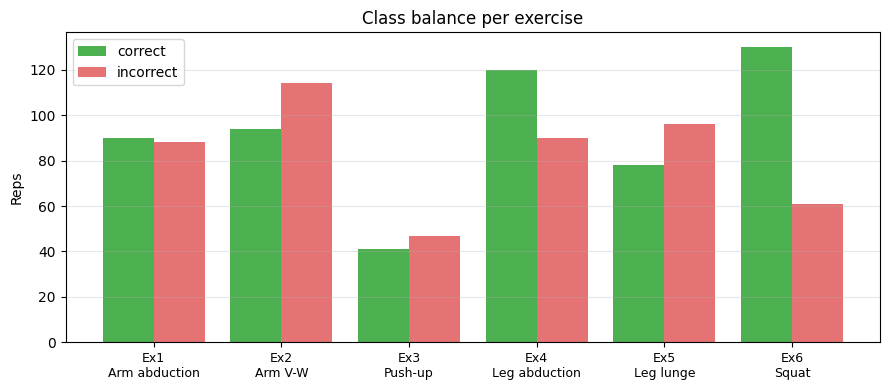

In [ ]:
ex_balance = (seg.groupby('_exercise')['_correct']
                 .agg(['count','sum'])
                 .rename(columns={'count':'total','sum':'correct'}))
ex_balance['incorrect'] = ex_balance['total'] - ex_balance['correct']
ex_balance['prop_correct'] = (ex_balance['correct'] / ex_balance['total']).round(3)
print(ex_balance)

fig, ax = plt.subplots(figsize=(9, 4))
x = ex_balance.index
ax.bar(x - 0.2, ex_balance['correct'],   0.4, label='correct',   color='#4CAF50')
ax.bar(x + 0.2, ex_balance['incorrect'], 0.4, label='incorrect', color='#E57373')
ax.set_xticks(x)
ax.set_xticklabels([f"Ex{i}\n{EXERCISE_NAMES[i]}" for i in x], fontsize=9)
ax.set_ylabel("Reps"); ax.set_title("Class balance per exercise")
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### SUBJECT-LEVEL DISTRIBUTION

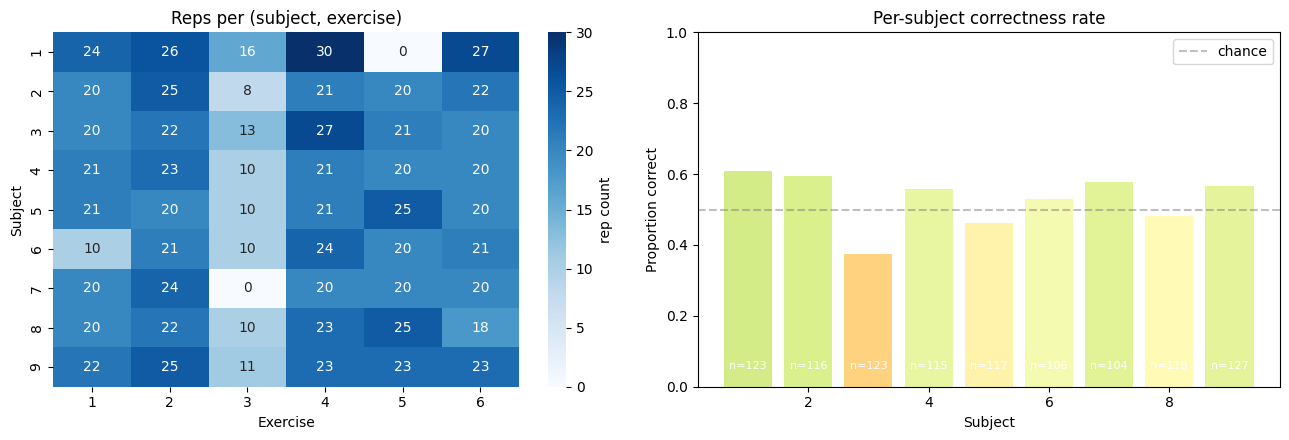

In [ ]:
heat = seg.pivot_table(index='_subject', columns='_exercise',
                          values='_correct', aggfunc='count', fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(heat, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label':'rep count'})
axes[0].set_title("Reps per (subject, exercise)")
axes[0].set_xlabel("Exercise"); axes[0].set_ylabel("Subject")

sub = seg.groupby('_subject')['_correct'].agg(['count','mean'])
ax = axes[1]
ax.bar(sub.index, sub['mean'], color=plt.cm.RdYlGn(sub['mean']))
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='chance')
ax.set_xlabel("Subject"); ax.set_ylabel("Proportion correct")
ax.set_title("Per-subject correctness rate")
ax.set_ylim(0, 1); ax.legend()
for i, v in zip(sub.index, sub['count']):
    ax.text(i, 0.05, f"n={v}", ha='center', fontsize=8, color='white')
plt.tight_layout(); plt.show()

### DIRECTION & LIGHTING

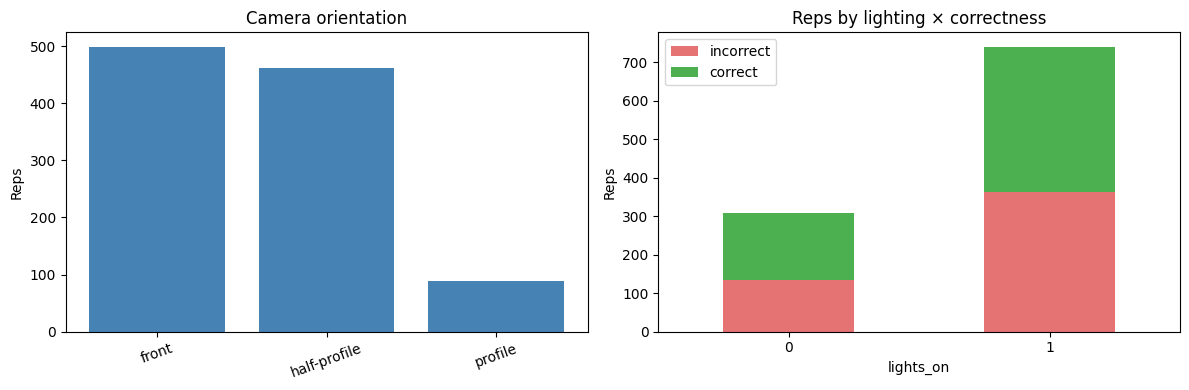

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dir_c = seg[COL["direction"]].value_counts()
axes[0].bar(dir_c.index, dir_c.values, color='steelblue')
axes[0].set_title("Camera orientation"); axes[0].set_ylabel("Reps")
for t in axes[0].get_xticklabels(): t.set_rotation(20)

light = seg.groupby([COL["lighting"], '_correct']).size().unstack(fill_value=0)
light.plot(kind='bar', stacked=True, ax=axes[1], color=['#E57373','#4CAF50'])
axes[1].set_title("Reps by lighting × correctness")
axes[1].set_xlabel("lights_on"); axes[1].set_ylabel("Reps")
axes[1].legend(['incorrect','correct'])
for t in axes[1].get_xticklabels(): t.set_rotation(0)
plt.tight_layout(); plt.show()

### 3.4 JOINT NAMES

In [ ]:
import re
with open(Path(CFG.data_root) / CFG.joint_names_txt) as f:
    JOINT_NAMES = [line.strip() for line in f if line.strip()]
JOINT_NAMES = [
    n.split(": ", 1)[-1] if re.match(r'^\d+:\s', n) else n
    for n in JOINT_NAMES
    ]
NUM_JOINTS = len(JOINT_NAMES)
JOINT_IDX = {n.lower(): i for i, n in enumerate(JOINT_NAMES)}
print(f"{NUM_JOINTS} joints:")
for i, n in enumerate(JOINT_NAMES): print(f"  {i:>2d}: {n}")

26 joints:
   0: Hips
   1: Spine
   2: Spine1
   3: Neck
   4: Head
   5: Head_end
   6: LeftShoulder
   7: LeftArm
   8: LeftForeArm
   9: LeftHand
  10: LeftHand_end
  11: RightShoulder
  12: RightArm
  13: RightForeArm
  14: RightHand
  15: RightHand_end
  16: LeftUpLeg
  17: LeftLeg
  18: LeftFoot
  19: LeftToeBase
  20: LeftToeBase_end
  21: RightUpLeg
  22: RightLeg
  23: RightFoot
  24: RightToeBase
  25: RightToeBase_end


### 3.5 LOADING 3D JOINT SEQUENCES

In [ ]:
def _load_rep_clip(row) -> np.ndarray:
    """Load and slice one rep's 3D joint clip → (T, 26, 3) float32 in dataset coordinate units.

    REHAB24-6 stores joints at .../Ex{N}/{video_id}-30fps.npy as (T, 26, 4).
    The fourth channel is the homogeneous coordinate, expected to be constant 1.0.
    We keep xyz only.
    """
    rec = str(row[COL["recording"]])
    ex  = int(row[COL["exercise"]])
    paths = [
        Path(CFG.data_root) / f"Ex{ex}" / f"{rec}-30fps.npy",
        Path(CFG.data_root) / CFG.joints_subdir / f"Ex{ex}" / f"{rec}-30fps.npy",
        Path(CFG.data_root) / f"Ex{ex}" / f"{rec}.npy",
    ]
    path = next((p for p in paths if p.exists()), None)
    if path is None:
        raise FileNotFoundError(f"No joint file for {rec} Ex{ex}")
    full = np.load(path)
    s, e = int(row[COL["start"]]), int(row[COL["end"]])

    # Add 1 to 'e' because last_frame is inclusive, then clamp to array bounds
    s, e = max(0, s), min(e + 1, full.shape[0])

    if s >= e:
        raise ValueError(f"Empty range [{s},{e}) in {path.name}")
    clip = full[s:e]
    if clip.ndim == 3 and clip.shape[1] == NUM_JOINTS and clip.shape[2] == 4:
        if not np.allclose(clip[..., 3], 1.0, atol=1e-4):
            warnings.warn(f"Unexpected homogeneous coordinate values in {path.name}")
        clip = clip[..., :3]
    if clip.ndim == 2 and clip.shape[1] in (NUM_JOINTS*3, NUM_JOINTS*4):
        clip = clip.reshape(-1, NUM_JOINTS, clip.shape[1] // NUM_JOINTS)
        if clip.shape[2] == 4:
            if not np.allclose(clip[..., 3], 1.0, atol=1e-4):
                warnings.warn(f"Unexpected homogeneous coordinate values in {path.name}")
            clip = clip[..., :3]

    # Add runtime validation
    if clip.shape[1] != NUM_JOINTS:
        raise ValueError(f"Expected {NUM_JOINTS} joints, got {clip.shape[1]}")
    if clip.shape[2] != 3:
        raise ValueError(f"Expected 3 coordinates, got {clip.shape[2]}")

    return clip.astype(np.float32)

s = _load_rep_clip(seg.iloc[0])
print(f"Sample: shape={s.shape}, "
      f"x=[{s[...,0].min():.2f},{s[...,0].max():.2f}] "
      f"y=[{s[...,1].min():.2f},{s[...,1].max():.2f}] "
      f"z=[{s[...,2].min():.2f},{s[...,2].max():.2f}]")


Sample: shape=(198, 26, 3), x=[-0.72,0.18] y=[0.03,1.98] z=[-0.41,0.35]


### 3.6 CACHE ALL REPS

In [ ]:
CACHE_VERSION = "reps_cache_inclusive_last_frame.npz"
CACHE_PATH = Path(CFG.output_dir) / f"reps_cache_{CACHE_VERSION}.npz"

def cache_signature(seg):
    cols = [
        COL["recording"], COL["exercise"], COL["start"], COL["end"],
        COL["correct"], COL["subtype"], "_exercise", "_subject", "_correct"
    ]
    cols = [c for c in cols if c in seg.columns]
    payload = {
        "cache_version": CACHE_VERSION,
        "data_root": str(Path(CFG.data_root).resolve()),
        "joints_subdir": CFG.joints_subdir,
        "drop_subjects": list(CFG.drop_subjects),
        "segmentation_hash": hashlib.md5(seg[cols].to_csv(index=True).encode("utf-8")).hexdigest(),
    }
    return hashlib.md5(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()

signature = cache_signature(seg)
cache_valid = False

if CACHE_PATH.exists():
    print(f"Loading cache: {CACHE_PATH}")
    cache = np.load(CACHE_PATH, allow_pickle=True)
    cached_signature = str(cache["signature"].item()) if "signature" in cache.files else None
    if cached_signature == signature:
        REP_CLIPS = list(cache["clips"])
        REP_META  = pd.DataFrame.from_records(cache["meta"])
        cache_valid = True
    else:
        print("  stale cache ignored; rebuilding")

if not cache_valid:
    REP_CLIPS, recs = [], []
    for i, row in tqdm(seg.iterrows(), total=len(seg), desc="Loading reps"):
        try:
            clip = _load_rep_clip(row)
        except (FileNotFoundError, ValueError) as e:
            print(f"  skip rep {i}: {e}"); continue

        REP_CLIPS.append(clip)
        recs.append({"rep_idx": i,
                     "exercise": int(row["_exercise"]),
                     "subject":  int(row["_subject"]),
                     "correct":  int(row["_correct"]),
                     "subtype":  str(row[COL["subtype"]]),
                     "T":        clip.shape[0]})

    REP_META = pd.DataFrame(recs)
    np.savez_compressed(CACHE_PATH,
        clips=np.array(REP_CLIPS, dtype=object),
        meta=REP_META.to_records(index=False),
        signature=np.array(signature))
    print(f"  cached {len(REP_CLIPS)} reps")

print(f"Loaded {len(REP_CLIPS)} reps")
print(REP_META.head())


Loading reps:   0%|          | 0/1049 [00:00<?, ?it/s]

  cached 1049 reps
Loaded 1049 reps
   rep_idx  exercise  subject  correct    subtype    T
0        0         1        1        1  right arm  198
1        1         1        1        1  right arm  243
2        2         1        1        1  right arm  245
3        3         1        1        1  right arm  220
4        4         1        1        1  right arm  180


### 3.7 REP-DURATION DISTRIBUTION

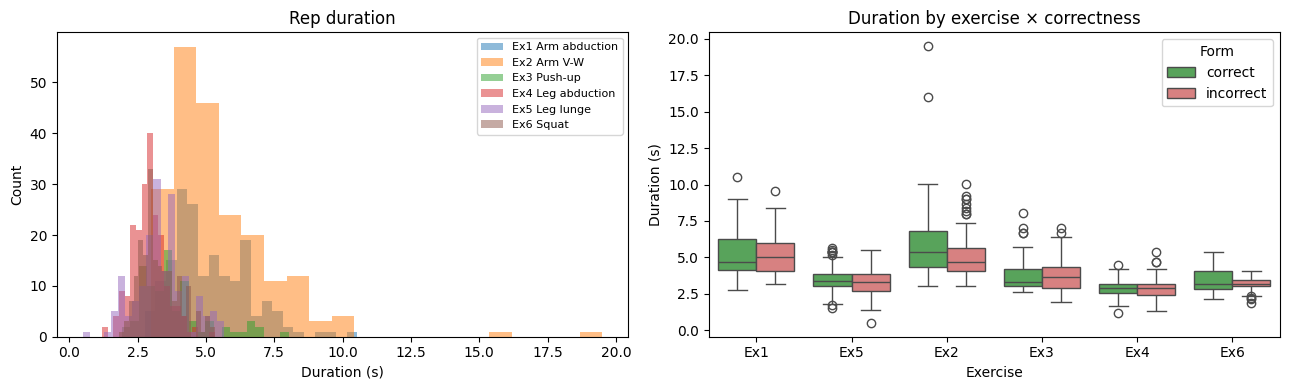


Median duration (frames):
          median  min  max
exercise                  
1          145.0   83  316
2          145.0   90  585
3          108.0   58  241
4           86.0   36  160
5          100.0   15  170
6           95.0   55  160


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ex in sorted(REP_META['exercise'].unique()):
    d = REP_META[REP_META['exercise']==ex]['T'] / 30.0
    axes[0].hist(d, bins=20, alpha=0.5, label=f"Ex{ex} {EXERCISE_NAMES[ex]}")
axes[0].set_xlabel("Duration (s)"); axes[0].set_ylabel("Count")
axes[0].set_title("Rep duration"); axes[0].legend(fontsize=8)

pdf = REP_META.copy()
pdf['duration_s'] = pdf['T'] / 30.0
pdf['Exercise'] = pdf['exercise'].map(lambda e: f"Ex{e}")
pdf['Form'] = pdf['correct'].map({0:'incorrect',1:'correct'})
sns.boxplot(data=pdf, x='Exercise', y='duration_s', hue='Form', ax=axes[1],
            palette={'correct':'#4CAF50','incorrect':'#E57373'})
axes[1].set_title("Duration by exercise × correctness"); axes[1].set_ylabel("Duration (s)")
plt.tight_layout(); plt.show()
print("\nMedian duration (frames):")
print(REP_META.groupby('exercise')['T'].agg(['median','min','max']))

### 3.8 SKELETON GEOMETRY SANITY CHECK

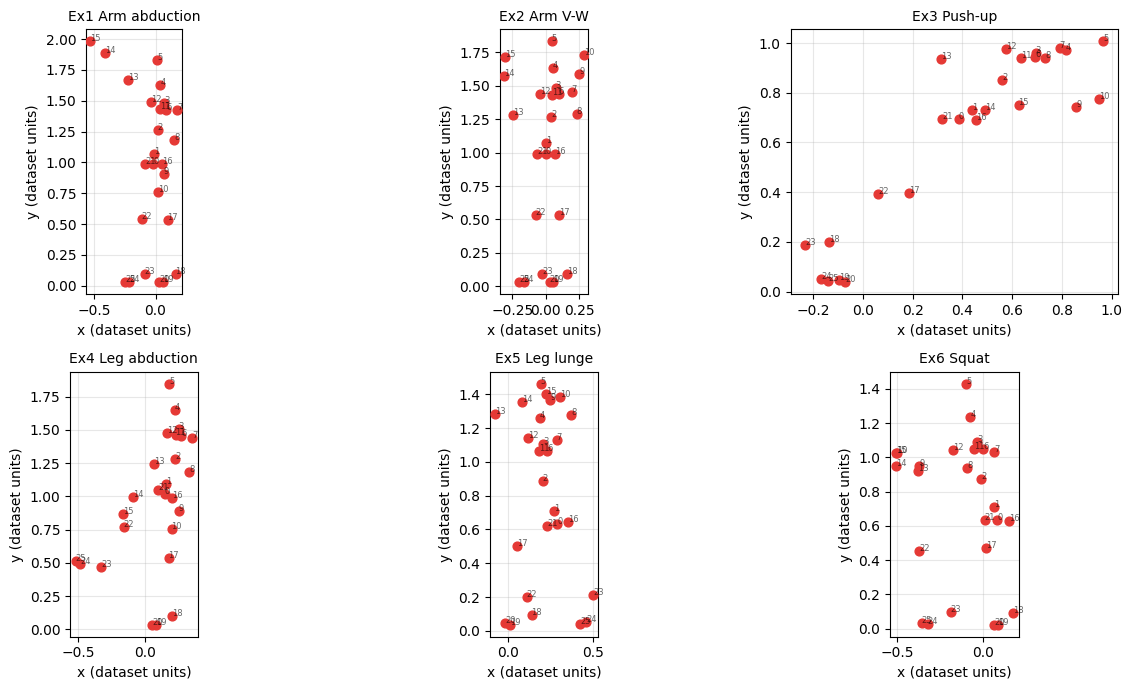

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, ex in zip(axes.flat, sorted(REP_META['exercise'].unique())):
    idx = REP_META[REP_META['exercise']==ex].index[0]
    clip = REP_CLIPS[idx]
    f = clip[clip.shape[0]//2]
    ax.scatter(f[:,0], f[:,1], s=40, c='#E53935', zorder=3)
    for i in range(NUM_JOINTS):
        ax.annotate(str(i), (f[i,0], f[i,1]), fontsize=6, alpha=0.6)
    ax.set_title(f"Ex{ex} {EXERCISE_NAMES[ex]}", fontsize=10)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel("x (dataset units)"); ax.set_ylabel("y (dataset units)")
plt.tight_layout(); plt.show()

## 4. DATASET PREPROCESSING

1. **Skeleton normalisation** — translation + scale (rotation removed; verified empirically that rotation step was producing y-axis fold-through)
2. **Temporal resampling** — fixed length for batched training
3. **Augmentation** — train-time only

### 4.1 ANCHOR JOINTS

In [ ]:
# Data Preprocessing: Anchor Joints Resolution
# Resolves exact indices for key joints required for normalization and feature extraction.
def find_joint(*candidates) -> Optional[int]:
    for c in candidates:
        if c.lower() in JOINT_IDX: return JOINT_IDX[c.lower()]
    return None

PELVIS_IDX    = find_joint("Hips", "Pelvis", "Root")
LSHOULDER_IDX = find_joint("LeftShoulder")
RSHOULDER_IDX = find_joint("RightShoulder")
NECK_IDX      = find_joint("Neck")
HEAD_IDX      = find_joint("Head")
CHEST_IDX     = find_joint("Spine1", "Chest", "Spine2", "Spine")

print(f"PELVIS:    {PELVIS_IDX:>2}  -  {JOINT_NAMES[PELVIS_IDX]}")
print(f"LSHOULDER: {LSHOULDER_IDX:>2}  -  {JOINT_NAMES[LSHOULDER_IDX]}")
print(f"RSHOULDER: {RSHOULDER_IDX:>2}  -  {JOINT_NAMES[RSHOULDER_IDX]}")
print(f"NECK:      {NECK_IDX:>2}  -  {JOINT_NAMES[NECK_IDX]}")
print(f"HEAD:      {HEAD_IDX:>2}  -  {JOINT_NAMES[HEAD_IDX]}")
print(f"CHEST:     {CHEST_IDX:>2}  -  {JOINT_NAMES[CHEST_IDX]}")
assert all(x is not None for x in (PELVIS_IDX, LSHOULDER_IDX, RSHOULDER_IDX,
                                    NECK_IDX, CHEST_IDX)), "Missing anchors"
print("\n✓ All anchor joints resolved")

PELVIS:     0  -  Hips
LSHOULDER:  6  -  LeftShoulder
RSHOULDER: 11  -  RightShoulder
NECK:       3  -  Neck
HEAD:       4  -  Head
CHEST:      2  -  Spine1

✓ All anchor joints resolved


In [ ]:
# Inspecting a single dataset sample
sample_idx = 0

print("=== Metadata for Sample 0 ===")
display(REP_META.iloc[[sample_idx]])

sample_clip = REP_CLIPS[sample_idx]
print("\n=== Skeleton Clip for Sample 0 ===")
print(f"Shape (Frames, Joints, Coordinates): {sample_clip.shape}")
print(f"First frame, Pelvis joint (x, y, z): {sample_clip[0, PELVIS_IDX]}")

=== Metadata for Sample 0 ===


,rep_idx,exercise,subject,correct,subtype,T
0,0,1,1,1,right arm,198



=== Skeleton Clip for Sample 0 ===
Shape (Frames, Joints, Coordinates): (198, 26, 3)
First frame, Pelvis joint (x, y, z): [-0.01618   0.984873  0.075539]


In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Define a set of raw bones (parent-child joint pairs) for early animation testing.
# This is self-contained so it can be used before the main skeleton definitions in Section 8.
_ANIM_BONES_RAW = [
    (PELVIS_IDX, find_joint("Spine")),
    (find_joint("Spine"), find_joint("Spine1")),
    (find_joint("Spine1"), NECK_IDX),
    (NECK_IDX, HEAD_IDX),
    (HEAD_IDX, find_joint("Head_end")),
    (find_joint("Spine1"), LSHOULDER_IDX),
    (LSHOULDER_IDX, find_joint("LeftArm")),
    (find_joint("LeftArm"), find_joint("LeftForeArm")),
    (find_joint("LeftForeArm"), find_joint("LeftHand")),
    (find_joint("LeftHand"), find_joint("LeftHand_end")),
    (find_joint("Spine1"), RSHOULDER_IDX),
    (RSHOULDER_IDX, find_joint("RightArm")),
    (find_joint("RightArm"), find_joint("RightForeArm")),
    (find_joint("RightForeArm"), find_joint("RightHand")),
    (find_joint("RightHand"), find_joint("RightHand_end")),
    (PELVIS_IDX, find_joint("LeftUpLeg")),
    (find_joint("LeftUpLeg"), find_joint("LeftLeg")),
    (find_joint("LeftLeg"), find_joint("LeftFoot")),
    (find_joint("LeftFoot"), find_joint("LeftToeBase")),
    (find_joint("LeftToeBase"), find_joint("LeftToeBase_end")),
    (PELVIS_IDX, find_joint("RightUpLeg")),
    (find_joint("RightUpLeg"), find_joint("RightLeg")),
    (find_joint("RightLeg"), find_joint("RightFoot")),
    (find_joint("RightFoot"), find_joint("RightToeBase")),
    (find_joint("RightToeBase"), find_joint("RightToeBase_end")),
]
# Clean up the raw bone list: sort pairs, ensure consistent ordering, and remove any None values.
ANIM_BONES = sorted({(min(a,b), max(a,b)) for a,b in _ANIM_BONES_RAW if a is not None and b is not None})

def animate_skeleton_clip(clip, bones, fps=30):
    """
    Creates an HTML5 video animation of a 3D skeleton clip.
    Maps the 3D coordinates to a 2D projection (X, Y) for visualization.
    """
    # Set up the figure and axis with a dark theme background
    fig, ax = plt.subplots(figsize=(6, 6), facecolor='#1A1A1A')
    ax.set_facecolor('#2E2E2E')

    # Determine global axis limits based on the min/max coordinates across all frames
    xs_all, ys_all = clip[..., 0], clip[..., 1]
    ax.set_xlim(xs_all.min() - 0.5, xs_all.max() + 0.5)
    ax.set_ylim(ys_all.min() - 0.5, ys_all.max() + 0.5)
    ax.set_aspect('equal') # Preserve physical proportions
    ax.set_xticks([]) # Hide axes ticks for a cleaner look
    ax.set_yticks([])

    # Initialize empty line objects for the bones (yellow) and a scatter plot for the joints (red)
    bone_lines = [ax.plot([], [], color='#FFD700', lw=3, zorder=2)[0] for _ in bones]
    joints = ax.scatter([], [], s=40, c='#E53935', edgecolors='black', lw=0.8, zorder=3)

    def update(t):
        """Animation update function called for each frame 't'."""
        frame = clip[t]
        xs, ys = frame[:, 0], frame[:, 1]

        # Update the coordinates for each bone line
        for line, (p, c) in zip(bone_lines, bones):
            line.set_data([xs[p], xs[c]], [ys[p], ys[c]])

        # Update the coordinates for the joints
        joints.set_offsets(np.column_stack([xs, ys]))

        return [*bone_lines, joints]

    # Generate the animation using FuncAnimation
    anim = FuncAnimation(fig, update, frames=clip.shape[0], interval=1000/fps, blit=True)
    plt.close(fig) # Prevent the static figure from displaying inline

    # Convert the animation to an HTML5 video player
    return HTML(anim.to_html5_video())

# Render and display the animation for the sample clip
display(animate_skeleton_clip(sample_clip, ANIM_BONES, fps=30))


### 4.2 SKELETON NORMALISATION (TRANSLATION + SCALE ONLY)

In [ ]:
# Data Preprocessing: Skeleton Normalisation
# Applies translation (pelvis to origin) and scaling based on torso length.
def normalize_skeleton(clip: np.ndarray) -> np.ndarray:
    if clip.ndim != 3 or clip.shape[1] != NUM_JOINTS or clip.shape[2] != 3:
        raise ValueError(f"Invalid clip shape: {clip.shape}")

    if PELVIS_IDX >= clip.shape[1] or NECK_IDX >= clip.shape[1]:
        raise ValueError("Joint indices out of bounds")

    clip = clip.copy()
    torso = np.linalg.norm(clip[:, NECK_IDX, :] - clip[:, PELVIS_IDX, :], axis=-1)
    torso = torso[np.isfinite(torso) & (torso > 1e-6)]
    if len(torso) == 0:
        raise ValueError("Cannot normalize skeleton with near-zero torso length")

    pelvis = clip[:, PELVIS_IDX:PELVIS_IDX+1, :]
    clip = clip - pelvis
    scale = float(np.median(torso))
    return (clip / scale).astype(np.float32)

norm = normalize_skeleton(REP_CLIPS[0])
print(f"After normalisation:")
print(f"  pelvis at frame 0: {norm[0, PELVIS_IDX, :]}")
print(f"  x range: [{norm[...,0].min():.2f}, {norm[...,0].max():.2f}]")
print(f"  y range: [{norm[...,1].min():.2f}, {norm[...,1].max():.2f}]")
print(f"  z range: [{norm[...,2].min():.2f}, {norm[...,2].max():.2f}]")


After normalisation:
  pelvis at frame 0: [0. 0. 0.]
  x range: [-1.41, 0.39]
  y range: [-1.90, 1.98]
  z range: [-0.95, 0.56]


### 4.3 TEMPORAL RESAMPLING

In [ ]:
# Data Preprocessing: Temporal Resampling
# Resamples variable-length clips to a fixed target length via linear interpolation.
def resample_temporal(clip: np.ndarray, target_T: int) -> np.ndarray:
    T = clip.shape[0]
    if T == target_T: return clip.astype(np.float32)
    src = np.linspace(0, T-1, T); dst = np.linspace(0, T-1, target_T)
    flat = clip.reshape(T, -1)
    out = np.empty((target_T, flat.shape[1]), dtype=np.float32)
    for j in range(flat.shape[1]):
        out[:, j] = np.interp(dst, src, flat[:, j])
    return out.reshape(target_T, clip.shape[1], clip.shape[2])

print(f"Resample test: {REP_CLIPS[0].shape} → "
      f"{resample_temporal(REP_CLIPS[0], CFG.target_length).shape}")

Resample test: (198, 26, 3) → (64, 26, 3)


### 4.4 AUGMENTATION (TRAIN-TIME ONLY)

In [ ]:
# Data Preprocessing: Augmentation
# Applies randomized spatial rotation, jitter, joint dropout, and time warping during training.
def augment_skeleton(clip, rot_deg=15.0, noise_std=0.01,
                     joint_dropout_p=0.1, time_warp_pct=0.10):
    clip = clip.copy()
    T, V, C = clip.shape

    if rot_deg > 0:
        theta = np.deg2rad(np.random.uniform(-rot_deg, rot_deg))
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([[c, 0, -s], [0, 1, 0], [s, 0, c]], dtype=np.float32)

        # Rotate xyz channels.
        clip[..., :3] = clip[..., :3] @ R.T

        # If velocity channels are present, rotate them too.
        # In this notebook CLIPS has 15 channels:
        #   0:3   xyz
        #   3:6   velocity
        #   6:15  scalar angle/inclination channels
        if C >= 6:
            clip[..., 3:6] = clip[..., 3:6] @ R.T

    if noise_std > 0:
        clip = clip + np.random.randn(*clip.shape).astype(np.float32) * noise_std

    if joint_dropout_p > 0:
        mask = np.random.rand(T, V) < joint_dropout_p
        clip[mask] = 0.0

    if time_warp_pct > 0:
        warp = 1.0 + np.random.uniform(-time_warp_pct, time_warp_pct)
        new_T = max(8, int(round(T * warp)))
        clip = resample_temporal(clip, new_T)
        clip = resample_temporal(clip, T)

    return clip.astype(np.float32)

print(f"Augmented: {augment_skeleton(norm).shape}")

Augmented: (198, 26, 3)


## 5. CROSS-SUBJECT SPLITS (LOSO)

In [ ]:
def make_loso_folds(meta: pd.DataFrame):
    folds = []
    for s in sorted(meta['subject'].unique()):
        te = meta.index[meta['subject']==s].tolist()
        tr = meta.index[meta['subject']!=s].tolist()
        folds.append((tr, te))
    return folds

LOSO_FOLDS = make_loso_folds(REP_META)
print(f"{len(LOSO_FOLDS)} LOSO folds:")
for i, (tr, te) in enumerate(LOSO_FOLDS):
    pos = REP_META.loc[te, 'correct'].sum()
    print(f"  Fold {i}: subj={REP_META.loc[te[0],'subject']:>2}  "
          f"train={len(tr):>4}  test={len(te):>3}  pos={pos}/{len(te)}")

9 LOSO folds:
  Fold 0: subj= 1  train= 926  test=123  pos=75/123
  Fold 1: subj= 2  train= 933  test=116  pos=69/116
  Fold 2: subj= 3  train= 926  test=123  pos=46/123
  Fold 3: subj= 4  train= 934  test=115  pos=64/115
  Fold 4: subj= 5  train= 932  test=117  pos=54/117
  Fold 5: subj= 6  train= 943  test=106  pos=56/106
  Fold 6: subj= 7  train= 945  test=104  pos=60/104
  Fold 7: subj= 8  train= 931  test=118  pos=57/118
  Fold 8: subj= 9  train= 922  test=127  pos=72/127


## 6. ENGINEERED KINEMATIC FEATURES

### 6.1 LIMB JOINT INDICES

In [ ]:
LIMB_JOINTS = {
    "lhip":   find_joint("LeftUpLeg"),
    "rhip":   find_joint("RightUpLeg"),
    "lknee":  find_joint("LeftLeg"),
    "rknee":  find_joint("RightLeg"),
    "lankle": find_joint("LeftFoot"),
    "rankle": find_joint("RightFoot"),
    "lshld":  LSHOULDER_IDX,
    "rshld":  RSHOULDER_IDX,
    "luarm":  find_joint("LeftArm"),
    "ruarm":  find_joint("RightArm"),
    "lelbow": find_joint("LeftForeArm"),
    "relbow": find_joint("RightForeArm"),
    "lwrist": find_joint("LeftHand"),
    "rwrist": find_joint("RightHand"),
}
for k, v in LIMB_JOINTS.items():
    print(f"  {k:>7s}: {v}  ({JOINT_NAMES[v] if v is not None else 'NOT FOUND'})")
miss = [k for k, v in LIMB_JOINTS.items() if v is None]
assert not miss, f"Missing limb joints: {miss}"


     lhip: 16  (LeftUpLeg)
     rhip: 21  (RightUpLeg)
    lknee: 17  (LeftLeg)
    rknee: 22  (RightLeg)
   lankle: 18  (LeftFoot)
   rankle: 23  (RightFoot)
    lshld: 6  (LeftShoulder)
    rshld: 11  (RightShoulder)
    luarm: 7  (LeftArm)
    ruarm: 12  (RightArm)
   lelbow: 8  (LeftForeArm)
   relbow: 13  (RightForeArm)
   lwrist: 9  (LeftHand)
   rwrist: 14  (RightHand)


### 6.2 FEATURE EXTRACTION (ANGLES + POSITIONS)

In [ ]:
def angle_at(clip, a, b, c):
    """Angle (rad) at vertex b for points a-b-c, per frame. clip:(T,V,3) -> (T,)"""
    v1 = clip[:, a] - clip[:, b]
    v2 = clip[:, c] - clip[:, b]
    denom = np.linalg.norm(v1, axis=-1) * np.linalg.norm(v2, axis=-1) + 1e-8
    cos = (v1 * v2).sum(axis=-1) / denom
    return np.arccos(np.clip(cos, -1.0, 1.0))

def angle_to_vertical(clip, a, b):
    """Angle of vector (a-b) to world Y-axis. clip:(T,V,3) -> (T,)"""
    v = clip[:, a] - clip[:, b]
    denom = np.linalg.norm(v, axis=-1) + 1e-8
    cos = v[:, 1] / denom
    return np.arccos(np.clip(cos, -1.0, 1.0))

def rms_jerk(positions, duration_s=None):
    if positions.shape[0] < 4: return 0.0
    j = np.diff(positions, n=3, axis=0)
    if duration_s is not None and duration_s > 0:
        dt = duration_s / max(1, positions.shape[0] - 1)
        j = j / max(dt ** 3, 1e-8)
    return float(np.sqrt((j**2).sum(-1).mean()))

def joint_scalar_channel(values, joint_idx, num_frames, num_joints):
    channel = np.zeros((num_frames, num_joints, 1), dtype=np.float32)
    channel[:, joint_idx, 0] = values.astype(np.float32)
    return channel

def xyz_to_angle_channels(clip):
    """clip: (T, V, 3) → (T, V, 15) angle features and velocity appended to xyz"""
    T, V = clip.shape[:2]
    vel = np.diff(clip, axis=0, prepend=clip[:1])
    feats = [clip, vel]
    angle_pairs = [
        (LIMB_JOINTS["lhip"],  LIMB_JOINTS["lknee"],  LIMB_JOINTS["lankle"]),
        (LIMB_JOINTS["rhip"],  LIMB_JOINTS["rknee"],  LIMB_JOINTS["rankle"]),
        (LIMB_JOINTS["luarm"], LIMB_JOINTS["lelbow"], LIMB_JOINTS["lwrist"]),
        (LIMB_JOINTS["ruarm"], LIMB_JOINTS["relbow"], LIMB_JOINTS["rwrist"]),
        (CHEST_IDX,            LIMB_JOINTS["lhip"],   LIMB_JOINTS["lknee"]),
        (CHEST_IDX,            LIMB_JOINTS["rhip"],   LIMB_JOINTS["rknee"]),
    ]
    for a, b, c in angle_pairs:
        feats.append(joint_scalar_channel(angle_at(clip, a, b, c), b, T, V))
    for a, b in [(CHEST_IDX, PELVIS_IDX),
                 (LIMB_JOINTS["luarm"], LSHOULDER_IDX),
                 (LIMB_JOINTS["ruarm"], RSHOULDER_IDX)]:
        feats.append(joint_scalar_channel(angle_to_vertical(clip, a, b), b, T, V))
    return np.concatenate(feats, axis=-1).astype(np.float32)

def extract_features(clip: np.ndarray, duration_s: float) -> Dict[str, float]:
    """Extract joint-angle features + position-based sagittal-plane features.

    The position features capture squat/lunge depth and forward translation,
    which 3-point joint angles miss because upper-leg and lower-leg rotate
    together during a sagittal squat (verified diagnostically).

    NOTE: this function operates on NORMALISED, RESAMPLED clips. All
    distances are in torso-length units (after dividing by mean torso length).
    """
    f = {"duration_s": float(duration_s)}
    L = LIMB_JOINTS
    T = clip.shape[0]

    # === ANGLE FEATURES ===
    angles = {}
    angles["lknee"]      = angle_at(clip, L["lhip"],  L["lknee"],  L["lankle"])
    angles["rknee"]      = angle_at(clip, L["rhip"],  L["rknee"],  L["rankle"])
    angles["lelbow"]     = angle_at(clip, L["luarm"], L["lelbow"], L["lwrist"])
    angles["relbow"]     = angle_at(clip, L["ruarm"], L["relbow"], L["rwrist"])
    angles["lhip_flex"]  = angle_at(clip, CHEST_IDX, L["lhip"], L["lknee"])
    angles["rhip_flex"]  = angle_at(clip, CHEST_IDX, L["rhip"], L["rknee"])
    angles["lshld_abd"]  = angle_to_vertical(clip, L["luarm"], L["lshld"])
    angles["rshld_abd"]  = angle_to_vertical(clip, L["ruarm"], L["rshld"])
    angles["trunk_incl"] = angle_to_vertical(clip, CHEST_IDX, PELVIS_IDX)

    for name, a in angles.items():
        f[f"{name}_mean"] = float(a.mean())
        f[f"{name}_std"]  = float(a.std())
        f[f"{name}_min"]  = float(a.min())
        f[f"{name}_max"]  = float(a.max())
        f[f"{name}_rom"]  = float(a.max() - a.min())
        f[f"{name}_argmax_rel"] = float(a.argmax() / max(1, T-1))

    pairs = [("lknee","rknee"),("lelbow","relbow"),
             ("lhip_flex","rhip_flex"),("lshld_abd","rshld_abd")]
    for ln, rn in pairs:
        d = np.abs(angles[ln] - angles[rn])
        base = ln[1:] if ln.startswith('l') else ln
        f[f"sym_{base}_mean"] = float(d.mean())
        f[f"sym_{base}_max"]  = float(d.max())

    for jk in ["lknee","rknee","lelbow","relbow","lwrist","rwrist"]:
        f[f"jerk_{jk}"] = rms_jerk(clip[:, LIMB_JOINTS[jk]], duration_s)

    # === POSITION-BASED FEATURES ===
    # These capture sagittal-plane motion that 3-point angles miss.
    # All units are torso-length-normalised (since clip is post-normalisation).

    # 1. Hip vertical drop (squat depth, lunge depth)
    f["lhip_y_drop"]   = float(clip[:, L["lhip"], 1].max() - clip[:, L["lhip"], 1].min())
    f["rhip_y_drop"]   = float(clip[:, L["rhip"], 1].max() - clip[:, L["rhip"], 1].min())

    # 2. Knee forward translation (z-drift) — squat knee tracking
    f["lknee_z_drift"] = float(clip[:, L["lknee"], 2].max() - clip[:, L["lknee"], 2].min())
    f["rknee_z_drift"] = float(clip[:, L["rknee"], 2].max() - clip[:, L["rknee"], 2].min())

    # 3. Knee-over-ankle alignment (mean |z difference|; smaller = better tracking)
    f["lknee_over_ankle"] = float(np.mean(np.abs(
        clip[:, L["lknee"], 2] - clip[:, L["lankle"], 2])))
    f["rknee_over_ankle"] = float(np.mean(np.abs(
        clip[:, L["rknee"], 2] - clip[:, L["rankle"], 2])))

    # 4. Hand vertical reach (arm exercises) — peak reach above starting position
    f["lhand_y_reach"] = float(clip[:, L["lwrist"], 1].max() - clip[0, L["lwrist"], 1])
    f["rhand_y_reach"] = float(clip[:, L["rwrist"], 1].max() - clip[0, L["rwrist"], 1])

    # 5. Trunk forward lean in sagittal plane (Z-Y plane), distinct from full 3D angle
    trunk_vec = clip[:, CHEST_IDX, :] - clip[:, PELVIS_IDX, :]   # (T, 3)
    sagittal = np.arctan2(trunk_vec[:, 2], trunk_vec[:, 1] + 1e-8)
    f["trunk_sagittal_mean"] = float(sagittal.mean())
    f["trunk_sagittal_max"]  = float(sagittal.max())
    f["trunk_sagittal_rom"]  = float(sagittal.max() - sagittal.min())

    # 6. Hand-to-hand symmetry (vertical) — arm-exercise feature
    hand_y_diff = clip[:, L["lwrist"], 1] - clip[:, L["rwrist"], 1]
    f["hand_y_sym_mean"] = float(np.abs(hand_y_diff).mean())
    f["hand_y_sym_max"]  = float(np.abs(hand_y_diff).max())

    return f


### 6.3  DIAGNOSTIC VERIFICATION — DOES THE PIPELINE DETECT SQUAT MOTION?

In [ ]:
print("Position-based feature medians per exercise (torso-length-normalised units):")
print()

rows = []
for ex in sorted(REP_META['exercise'].unique()):
    lhip_drop, rhip_drop, lknee_zd, rknee_zd, hand_reach = [], [], [], [], []

    for idx in REP_META[REP_META['exercise'] == ex].index[:30]:
        clip = resample_temporal(normalize_skeleton(REP_CLIPS[idx]), CFG.target_length)
        f = extract_features(clip, REP_META.loc[idx, 'T'] / 30.0)

        lhip_drop.append(f['lhip_y_drop'])
        rhip_drop.append(f['rhip_y_drop'])
        lknee_zd.append(f['lknee_z_drift'])
        rknee_zd.append(f['rknee_z_drift'])
        hand_reach.append(max(f['lhand_y_reach'], f['rhand_y_reach']))

    rows.append({
        "Ex": f"Ex{ex} {EXERCISE_NAMES[ex]}",
        "lhip_y_drop":   f"{np.median(lhip_drop):.3f}",
        "rhip_y_drop":   f"{np.median(rhip_drop):.3f}",
        "lknee_z_drift": f"{np.median(lknee_zd):.3f}",
        "rknee_z_drift": f"{np.median(rknee_zd):.3f}",
        "hand_reach":    f"{np.median(hand_reach):+.3f}",
    })

print(pd.DataFrame(rows).to_string(index=False))
print()
print("Expected pattern:")
print("  - Squats/lunges: knee_z_drift should be relatively large")
print("  - Arm abduction: hand_reach should be large")
print("  - hip_y_drop measures vertical travel of LeftUpLeg/RightUpLeg relative to the pelvis origin.")
print("    Squats and lunges should show a larger value; standing exercises should show a smaller value.")

Position-based feature medians per exercise (torso-length-normalised units):

               Ex lhip_y_drop rhip_y_drop lknee_z_drift rknee_z_drift hand_reach
Ex1 Arm abduction       0.003       0.003         0.010         0.011     +1.947
      Ex2 Arm V-W       0.003       0.003         0.019         0.020     +0.037
      Ex3 Push-up       0.011       0.011         0.153         0.158     +0.344
Ex4 Leg abduction       0.063       0.063         0.048         0.498     +0.222
    Ex5 Leg lunge       0.018       0.018         0.448         0.247     +0.030
        Ex6 Squat       0.011       0.011         0.674         0.507     +0.752

Expected pattern:
  - Squats/lunges: knee_z_drift should be relatively large
  - Arm abduction: hand_reach should be large
  - hip_y_drop measures vertical travel of LeftUpLeg/RightUpLeg relative to the pelvis origin.
    Squats and lunges should show a larger value; standing exercises should show a smaller value.


### 6.4 BUILD THE FULL FEATURE MATRIX

In [ ]:
def build_feature_matrix():
    """Builds a tabular feature matrix from the raw 3D skeleton sequences."""
    rows, clips_proc = [], []
    # Iterate over all repetitions with a progress bar
    for i in tqdm(range(len(REP_CLIPS)), desc="Extracting features"):
        # Normalize and resample the clip to standard dimensions
        clip = normalize_skeleton(REP_CLIPS[i])
        clip = resample_temporal(clip, CFG.target_length)

        # Extract engineered features for the clip
        f = extract_features(clip, REP_META.loc[i, 'T']/30.0)

        clip_with_angles = xyz_to_angle_channels(clip)
        clips_proc.append(clip_with_angles)

        # Append metadata (exercise, subject, label) to the feature dictionary
        f.update({"exercise": int(REP_META.loc[i,"exercise"]),
                  "subject":  int(REP_META.loc[i,"subject"]),
                  "correct":  int(REP_META.loc[i,"correct"])})
        rows.append(f)

    # Convert list of dictionaries to a pandas DataFrame
    df = pd.DataFrame(rows)

    # Isolate the feature columns from the metadata columns
    feat_cols = [c for c in df.columns if c not in ("exercise","subject","correct")]

    # Extract NumPy arrays for machine learning models
    X = df[feat_cols].values.astype(np.float32)
    y = df["correct"].values.astype(np.int64)
    g = df["subject"].values.astype(np.int64)

    return df, X, y, g, np.stack(clips_proc, axis=0), feat_cols

# Execute the function to build the global dataset variables
FEAT_DF, X_FEAT, Y, GROUPS, CLIPS, FEAT_COLS = build_feature_matrix()
EX_ARR = FEAT_DF["exercise"].values
print(f"X={X_FEAT.shape}, Y={Y.shape}, GROUPS={GROUPS.shape}, CLIPS={CLIPS.shape}")
print(f"{len(FEAT_COLS)} features (was 69 before position-based features added)")


Extracting features:   0%|          | 0/1049 [00:00<?, ?it/s]

X=(1049, 82), Y=(1049,), GROUPS=(1049,), CLIPS=(1049, 64, 26, 15)
82 features (was 69 before position-based features added)


### 6.5 FEATURE DISTRIBUTIONS BY CLASS

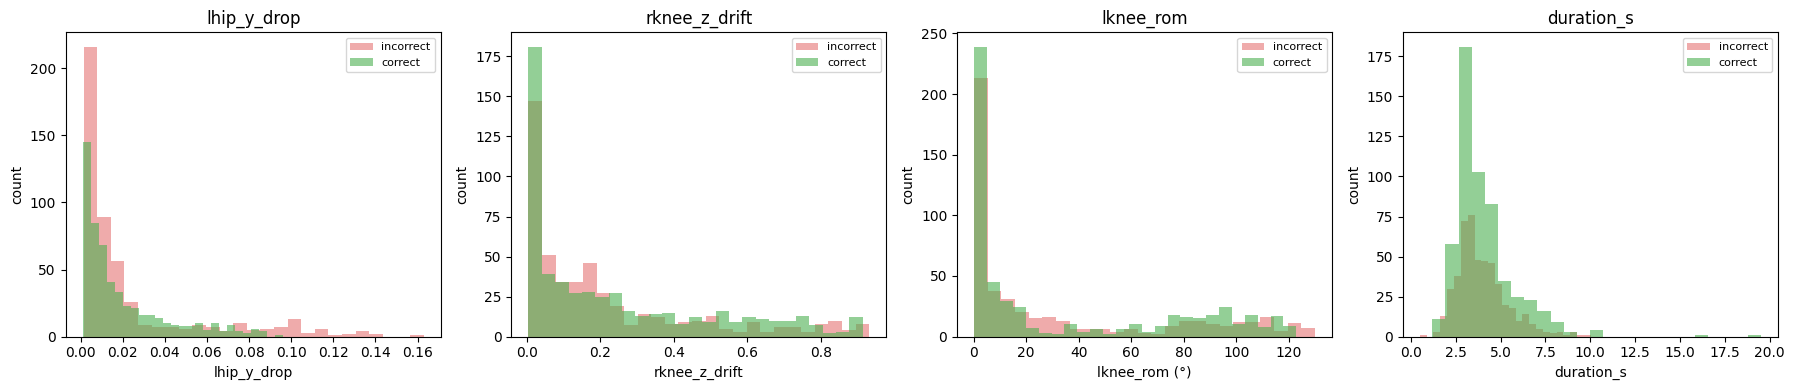

In [ ]:
# Show one position feature (pelvis_y_drop) and one angle feature (lknee_rom)
# alongside duration. Compare class separability across exercises.
features_to_plot = ['lhip_y_drop', 'rknee_z_drift', 'lknee_rom', 'duration_s']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, fname in zip(axes, features_to_plot):
    if fname not in FEAT_COLS:
        ax.set_title(f"{fname} (missing)"); continue
    vals = FEAT_DF[fname].values
    if 'rom' in fname:
        vals = np.rad2deg(vals); xlabel = f"{fname} (°)"
    else:
        xlabel = fname
    for cls, color, lab in [(0,'#E57373','incorrect'), (1,'#4CAF50','correct')]:
        ax.hist(vals[Y==cls], bins=25, alpha=0.6, color=color, label=lab)
    ax.set_xlabel(xlabel); ax.set_ylabel("count")
    ax.set_title(fname); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. CLASSICAL ML BASELINES

In [ ]:
def safe_auroc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def safe_auprc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_prob)


def format_metric(value):
    return "nan" if pd.isna(value) else f"{value:.3f}"


def fold_support(y_true, preds):
    return {
        "n_pos": int((y_true == 1).sum()),
        "n_neg": int((y_true == 0).sum()),
        "n_pred_pos": int((preds == 1).sum()),
    }

In [ ]:
def train_eval_classical(model_factory, X, y, groups, exercises, name, n_tta=5, noise_std=0.01):
    """
    Train and evaluate classical ML models using Leave-One-Subject-Out (LOSO) cross-validation,
    separately for each exercise. Includes Test-Time Augmentation (TTA) for robustness.
    """
    rows, all_t, all_p, all_pr = [], [], [], []
    for ex in sorted(np.unique(exercises)):
        # Isolate data for the current exercise
        mask = exercises == ex
        Xe, ye, ge = X[mask], y[mask], groups[mask]

        # Perform Leave-One-Subject-Out cross validation
        for s in sorted(np.unique(ge)):
            tr, te = ge != s, ge == s
            if te.sum() == 0 or len(np.unique(ye[tr])) < 2: continue

            # Standardize features based on training data
            sc = StandardScaler().fit(Xe[tr])
            clf = model_factory()
            clf.fit(sc.transform(Xe[tr]), ye[tr])

            # Predict probabilities on the test set with Test-Time Augmentation (TTA)
            X_te_scaled = sc.transform(Xe[te])
            tta_probs = [clf.predict_proba(X_te_scaled)[:, 1]]
            for _ in range(n_tta - 1):
                noise = np.random.randn(*X_te_scaled.shape) * noise_std
                tta_probs.append(clf.predict_proba(X_te_scaled + noise)[:, 1])
            prob = np.mean(tta_probs, axis=0)

            # Per-fold threshold calibration on training set (no test leakage)
            train_prob = clf.predict_proba(sc.transform(Xe[tr]))[:, 1]
            thr = _find_best_threshold(ye[tr], train_prob)

            # Binarize predictions using the calibrated threshold
            pred = (prob >= thr).astype(int)
            yt = ye[te]
            support = fold_support(yt, pred)

            rows.append({
                "model": name,
                "exercise": int(ex),
                "subject": int(s),
                "n_test": int(te.sum()),
                "n_pos": support["n_pos"],
                "n_neg": support["n_neg"],
                "n_pred_pos": support["n_pred_pos"],
                "threshold": float(thr),
                "acc": accuracy_score(yt, pred),
                "f1": precision_recall_fscore_support(
                    yt, pred, average='binary', zero_division=0
                )[2],
                "auroc": safe_auroc(yt, prob),
                "auprc": safe_auprc(yt, prob),
                "brier": brier_score_loss(yt, prob),
            })
            all_t.extend(ye[te].tolist()); all_p.extend(pred.tolist()); all_pr.extend(prob.tolist())

    return pd.DataFrame(rows), np.array(all_t), np.array(all_pr), np.array(all_p)

def _find_best_threshold(y_true, y_prob, n_thresholds=51,
                         min_quantile=0.10, max_quantile=0.90):
    """
    Find the F1-optimal probability threshold over training-set predictions.
    Clips the search to a sensible quantile range to avoid extreme thresholds
    (0.0001 or 0.999) that overfit on small training sets and don't transfer well.
    """
    if len(np.unique(y_true)) < 2: return 0.5

    # Clip search range to the central portion of training probabilities
    lo = float(np.quantile(y_prob, min_quantile))
    hi = float(np.quantile(y_prob, max_quantile))
    if hi - lo < 1e-3:  # degenerate case: all probs identical
        return float(np.median(y_prob))

    thrs = np.linspace(lo, hi, n_thresholds)
    best_f1, best_thr = -1.0, float(np.median(y_prob))

    # Evaluate F1 score for each candidate threshold
    for t in thrs:
        pred = (y_prob >= t).astype(int)
        f1 = precision_recall_fscore_support(y_true, pred, average='binary',
                                             zero_division=0)[2]
        if f1 > best_f1:
            best_f1, best_thr = f1, float(t)

    return best_thr

def calibrate_threshold(y_train, p_train, y_val, p_val):
    train_thr = _find_best_threshold(y_train, p_train)

    if len(np.unique(y_val)) < 2:
        return train_thr

    val_thr = _find_best_threshold(y_val, p_val)

    # Blend validation and training thresholds to reduce single-subject instability.
    return float(0.5 * val_thr + 0.5 * train_thr)

# Define factory functions to generate fresh model instances for each fold
rf_factory = lambda: RandomForestClassifier(
    n_estimators=500, min_samples_leaf=2,
    class_weight="balanced", n_jobs=-1, random_state=SEED)

xgb_factory = lambda: xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    eval_metric="logloss", tree_method="hist",
    n_jobs=-1, random_state=SEED, verbosity=0)

# Execute LOSO evaluation for Random Forest and XGBoost
rf_results,  rf_true,  rf_probs,  rf_preds  = train_eval_classical(
    rf_factory,  X_FEAT, Y, GROUPS, EX_ARR, "RF")
xgb_results, xgb_true, xgb_probs, xgb_preds = train_eval_classical(
    xgb_factory, X_FEAT, Y, GROUPS, EX_ARR, "XGB")

# Print aggregated summary statistics
print("\nRandom Forest — mean ± std per exercise:")
print(rf_results.groupby("exercise")[["acc","f1","auroc","auprc"]].agg(['mean','std']).round(3))
print("\nXGBoost — mean ± std per exercise:")
print(xgb_results.groupby("exercise")[["acc","f1","auroc","auprc"]].agg(['mean','std']).round(3))



Random Forest — mean ± std per exercise:
            acc            f1         auroc         auprc       
           mean    std   mean    std   mean    std   mean    std
exercise                                                        
1         0.605  0.107  0.705  0.064  0.621  0.266  0.673  0.214
2         0.607  0.183  0.603  0.257  0.808  0.151  0.792  0.141
3         0.663  0.306  0.681  0.313  0.915  0.162  0.903  0.190
4         0.798  0.111  0.786  0.242  0.926  0.073  0.928  0.119
5         0.422  0.185  0.204  0.316  0.496  0.261  0.569  0.188
6         0.740  0.161  0.828  0.113  0.889  0.116  0.923  0.117

XGBoost — mean ± std per exercise:
            acc            f1         auroc         auprc       
           mean    std   mean    std   mean    std   mean    std
exercise                                                        
1         0.596  0.140  0.688  0.120  0.628  0.302  0.704  0.218
2         0.585  0.187  0.610  0.259  0.796  0.125  0.786  0.122
3         0.

### 7.1  SHAP FEATURE IMPORTANCE PER EXERCISE

In [ ]:
shap_summaries = {}
for ex in sorted(FEAT_DF["exercise"].unique()):
    m = FEAT_DF["exercise"].values == ex
    Xe, ye = X_FEAT[m], Y[m]
    sc = StandardScaler().fit(Xe); Xs = sc.transform(Xe)
    mdl = xgb_factory(); mdl.fit(Xs, ye)
    sv = shap.TreeExplainer(mdl).shap_values(Xs)
    imp = np.abs(sv).mean(0)
    shap_summaries[int(ex)] = sorted(zip(FEAT_COLS, imp), key=lambda x: -x[1])[:10]

for ex, top in shap_summaries.items():
    print(f"\nEx{ex} {EXERCISE_NAMES[ex]} — top-10 features (mean |SHAP|):")
    for n, v in top: print(f"  {n:>22s}: {v:.4f}")


Ex1 Arm abduction — top-10 features (mean |SHAP|):
          sym_elbow_mean: 0.8364
          hand_y_sym_max: 0.7483
           rhand_y_reach: 0.5005
       sym_shld_abd_mean: 0.3799
             relbow_mean: 0.3736
               rknee_min: 0.3602
      trunk_sagittal_rom: 0.3566
           rshld_abd_rom: 0.3008
              rknee_mean: 0.2792
       relbow_argmax_rel: 0.2590

Ex2 Arm V-W — top-10 features (mean |SHAP|):
        rknee_over_ankle: 0.7381
          trunk_incl_max: 0.6193
           lknee_z_drift: 0.5983
           lshld_abd_min: 0.5248
               rknee_std: 0.3641
           rknee_z_drift: 0.3242
               lknee_std: 0.3199
          sym_elbow_mean: 0.2950
    lshld_abd_argmax_rel: 0.2844
           sym_elbow_max: 0.2652

Ex3 Push-up — top-10 features (mean |SHAP|):
              relbow_rom: 0.9021
      trunk_sagittal_max: 0.8814
          trunk_incl_rom: 0.8090
           rshld_abd_min: 0.4081
             lelbow_mean: 0.2846
               lknee_std: 0.256

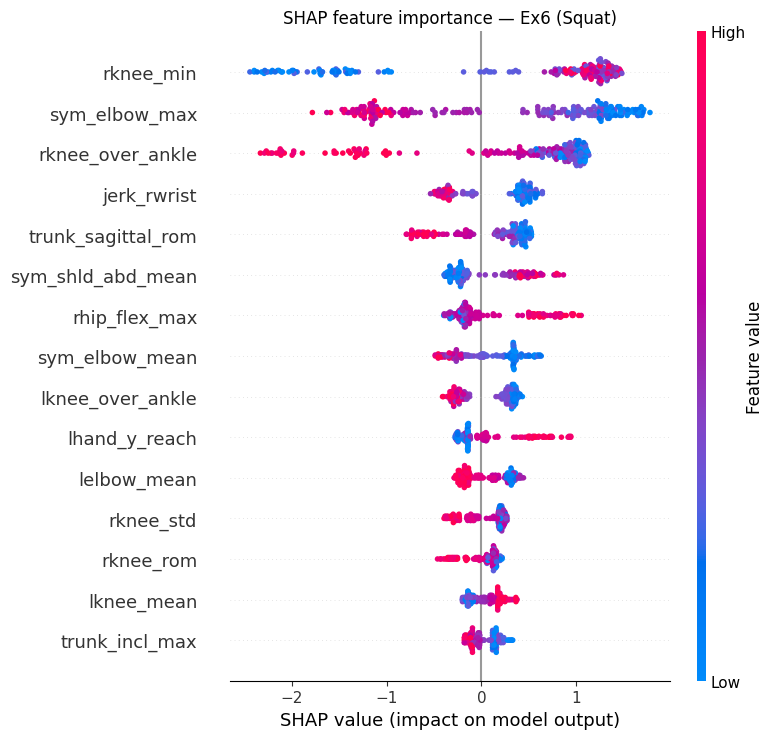

In [ ]:
# SHAP summary plot for squats (Ex6)
EX_FOR_SHAP = 6
m = FEAT_DF["exercise"].values == EX_FOR_SHAP
sc = StandardScaler().fit(X_FEAT[m]); Xs = sc.transform(X_FEAT[m])
mdl = xgb_factory(); mdl.fit(Xs, Y[m])
sv = shap.TreeExplainer(mdl).shap_values(Xs)
shap.summary_plot(sv, Xs, feature_names=FEAT_COLS, max_display=15, show=False)
plt.title(f"SHAP feature importance — Ex{EX_FOR_SHAP} ({EXERCISE_NAMES[EX_FOR_SHAP]})")
plt.tight_layout(); plt.show()

## 8. DEEP LEARNING MODELS

### 8.1 SKELETON BONES & ADJACENCY

In [ ]:
# Define the pairs of connected joints (parent, child) that make up the skeleton.
# These form the edges of the spatial graph used by the ST-GCN.
SKELETON_BONES = [
    (PELVIS_IDX, find_joint("Spine")),
    (find_joint("Spine"), find_joint("Spine1")),
    (find_joint("Spine1"), NECK_IDX),
    (NECK_IDX, HEAD_IDX),
    (HEAD_IDX, find_joint("Head_end")),
    (find_joint("Spine1"), LSHOULDER_IDX),
    (LSHOULDER_IDX, LIMB_JOINTS["luarm"]),
    (LIMB_JOINTS["luarm"], LIMB_JOINTS["lelbow"]),
    (LIMB_JOINTS["lelbow"], LIMB_JOINTS["lwrist"]),
    (LIMB_JOINTS["lwrist"], find_joint("LeftHand_end")),
    (find_joint("Spine1"), RSHOULDER_IDX),
    (RSHOULDER_IDX, LIMB_JOINTS["ruarm"]),
    (LIMB_JOINTS["ruarm"], LIMB_JOINTS["relbow"]),
    (LIMB_JOINTS["relbow"], LIMB_JOINTS["rwrist"]),
    (LIMB_JOINTS["rwrist"], find_joint("RightHand_end")),
    (PELVIS_IDX, LIMB_JOINTS["lhip"]),
    (LIMB_JOINTS["lhip"], LIMB_JOINTS["lknee"]),
    (LIMB_JOINTS["lknee"], LIMB_JOINTS["lankle"]),
    (LIMB_JOINTS["lankle"], find_joint("LeftToeBase")),
    (find_joint("LeftToeBase"), find_joint("LeftToeBase_end")),
    (PELVIS_IDX, LIMB_JOINTS["rhip"]),
    (LIMB_JOINTS["rhip"], LIMB_JOINTS["rknee"]),
    (LIMB_JOINTS["rknee"], LIMB_JOINTS["rankle"]),
    (LIMB_JOINTS["rankle"], find_joint("RightToeBase")),
    (find_joint("RightToeBase"), find_joint("RightToeBase_end")),
]

# Clean up the list: remove missing joints, sort pairs (min, max) to avoid duplicates, and keep unique edges.
BONES = sorted({(min(a,b), max(a,b)) for a,b in SKELETON_BONES if a is not None and b is not None})
print(f"{len(BONES)} bones detected")
for a, b in BONES:
    print(f"  ({a:>2d}, {b:>2d})  {JOINT_NAMES[a]:>20s} → {JOINT_NAMES[b]}")

25 bones detected
  ( 0,  1)                  Hips → Spine
  ( 0, 16)                  Hips → LeftUpLeg
  ( 0, 21)                  Hips → RightUpLeg
  ( 1,  2)                 Spine → Spine1
  ( 2,  3)                Spine1 → Neck
  ( 2,  6)                Spine1 → LeftShoulder
  ( 2, 11)                Spine1 → RightShoulder
  ( 3,  4)                  Neck → Head
  ( 4,  5)                  Head → Head_end
  ( 6,  7)          LeftShoulder → LeftArm
  ( 7,  8)               LeftArm → LeftForeArm
  ( 8,  9)           LeftForeArm → LeftHand
  ( 9, 10)              LeftHand → LeftHand_end
  (11, 12)         RightShoulder → RightArm
  (12, 13)              RightArm → RightForeArm
  (13, 14)          RightForeArm → RightHand
  (14, 15)             RightHand → RightHand_end
  (16, 17)             LeftUpLeg → LeftLeg
  (17, 18)               LeftLeg → LeftFoot
  (18, 19)              LeftFoot → LeftToeBase
  (19, 20)           LeftToeBase → LeftToeBase_end
  (21, 22)            RightUpLeg →

In [ ]:
# Data Preprocessing: Spatial Graph Adjacency Matrix
# Constructs a normalized adjacency matrix representing the skeleton's spatial graph for ST-GCN.
def build_adjacency(num_joints, bones):
    # Initialize an empty adjacency matrix with zeros
    A = np.zeros((num_joints, num_joints), dtype=np.float32)

    # Add bidirectional edges for each connected bone pair
    for p, c in bones:
        A[p, c] = 1.0; A[c, p] = 1.0

    # Add self-loops (identity matrix) so nodes consider their own features
    A = A + np.eye(num_joints, dtype=np.float32)

    # Compute the degree matrix D and its inverse square root Di for normalization
    D = A.sum(1); Di = np.diag(1.0 / np.sqrt(D + 1e-6))

    # Return the symmetrically normalized adjacency matrix Di * A * Di
    return torch.tensor(Di @ A @ Di, dtype=torch.float32)

# Build the normalized adjacency matrix for the dataset's joints and bones
A_NORM = build_adjacency(NUM_JOINTS, BONES)
print(f"A_norm: {A_NORM.shape}, "
      f"row-sum=[{A_NORM.sum(1).min():.3f}, {A_NORM.sum(1).max():.3f}]")

A_norm: torch.Size([26, 26]), row-sum=[0.880, 1.233]


### 8.2 ST-GCN

In [ ]:
class SpatialGraphConv(nn.Module):
    """
    Spatial Graph Convolution layer.
    Applies a standard 1x1 convolution over the node features, followed by
    multiplying with the spatial adjacency matrix to aggregate neighbor information.
    """
    def __init__(self, in_c, out_c, A):
        super().__init__()
        self.register_buffer("A", A)  # Spatial adjacency matrix
        self.conv = nn.Conv2d(in_c, out_c, 1)  # Feature transformation

    def forward(self, x):
        x = self.conv(x)  # Transform features: (N, C, T, V)
        # Aggregate spatial information across neighbors using Einsum for efficiency
        # n: batch, c: channels, t: time, v: source node (summed), w: destination node
        return torch.einsum('nctv,vw->nctw', x, self.A)

class TemporalAttentionPool(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.attn = nn.Conv2d(channels, 1, 1)

    def forward(self, x):
        # x: (N, C, T, V)
        w = torch.softmax(self.attn(x).flatten(2), dim=-1)  # (N, 1, T*V)
        out = (x.flatten(2) * w).sum(-1)                    # (N, C)
        return out

class STGCNBlock(nn.Module):
    """
    Spatio-Temporal Graph Convolutional Block.
    Combines Spatial Graph Convolution (GCN) with Temporal Convolution (TCN).
    Includes batch normalization, ReLU activations, dropout, and a residual connection.
    """
    def __init__(self, in_c, out_c, A, kt=9, stride=1, dropout=0.2):
        super().__init__()
        # Spatial graph convolution
        self.gcn = SpatialGraphConv(in_c, out_c, A)
        self.bn1 = nn.BatchNorm2d(out_c)

        # Temporal convolution
        pad = (kt - 1) // 2
        self.tcn = nn.Conv2d(out_c, out_c, (kt,1), (stride,1), (pad,0))
        self.bn2 = nn.BatchNorm2d(out_c)
        self.drop = nn.Dropout(dropout)

        # Residual connection: adjust channels/stride if necessary
        self.res = nn.Sequential(nn.Conv2d(in_c, out_c, 1, (stride,1)),
                                 nn.BatchNorm2d(out_c)) if (in_c != out_c or stride != 1) else nn.Identity()

    def forward(self, x):
        r = self.res(x)  # Residual branch

        # Spatial graph convolution + BN + ReLU
        x = F.relu(self.bn1(self.gcn(x)))
        x = self.drop(x)

        # Temporal convolution + BN
        x = self.bn2(self.tcn(x))

        # Add residual and apply final ReLU
        return F.relu(x + r)

class STGCN(nn.Module):
    """
    Spatio-Temporal Graph Convolutional Network.
    Processes skeleton sequences of shape (N, C, T, V).
    """
    def __init__(self, num_joints, in_channels, A, num_classes=2):
        super().__init__()
        # Input normalization across joints and channels
        self.input_bn = nn.BatchNorm1d(num_joints * in_channels)

        # Sequence of ST-GCN blocks progressively extracting higher-level features
        self.blocks = nn.ModuleList([
            STGCNBlock(in_channels, 64, A),
            STGCNBlock(64, 64, A),
            STGCNBlock(64, 128, A, stride=2),
            STGCNBlock(128, 128, A),
            STGCNBlock(128, 256, A, stride=2),
            STGCNBlock(256, 256, A),
        ])

        # Global average pooling and final classification layer
        self.pool = TemporalAttentionPool(256)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # x shape: (N, C, T, V)
        N, C, T, V = x.shape

        # Normalize input features
        x = x.permute(0, 3, 1, 2).contiguous().view(N, V*C, T)
        x = self.input_bn(x)
        x = x.view(N, V, C, T).permute(0, 2, 3, 1).contiguous()

        # Pass through ST-GCN blocks
        for blk in self.blocks:
            x = blk(x)

        # Pool and classify
        return self.fc(self.pool(x))

# Create a dummy input to verify network shapes and parameters
_dummy = torch.randn(2, 15, CFG.target_length, NUM_JOINTS)
_m = STGCN(NUM_JOINTS, 15, A_NORM)
print(f"ST-GCN out: {_m(_dummy).shape}, params: {sum(p.numel() for p in _m.parameters()):,}")

ST-GCN out: torch.Size([2, 2]), params: 1,726,415


### 8.3 1D-CNN BASELINE

In [ ]:
class CNN1D(nn.Module):
    def __init__(self, num_joints, in_channels, num_classes=2):
        super().__init__()
        ch = num_joints * in_channels
        self.net = nn.Sequential(
            nn.Conv1d(ch, 64, 7, padding=3), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(64, 128, 5, padding=2, stride=2), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Conv1d(128, 256, 5, padding=2, stride=2), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Conv1d(256, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, num_classes)
    def forward(self, x):
        N, C, T, V = x.shape
        x = x.permute(0, 3, 1, 2).reshape(N, V*C, T)
        return self.fc(self.pool(self.net(x)).view(N, -1))

_m = CNN1D(NUM_JOINTS, 15)
print(f"1D-CNN out: {_m(_dummy).shape}, params: {sum(p.numel() for p in _m.parameters()):,}")

1D-CNN out: torch.Size([2, 2]), params: 578,754


## 9.  TRAINING UTILITIES

Notable design choices:
- **Focal loss** (γ=2) with class-weighted α
- **Warmup-cosine LR** (5 warmup epochs + cosine decay)
- **Early stop on AUROC** (rank-based, robust to tiny val sets)
- **Defensive `train_one_fold`** — returns final-epoch state if validation never improves
- **Per-fold threshold calibration** — on training-set predictions, no test leakage

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.smoothing = smoothing
        if alpha is not None: self.register_buffer("alpha", alpha)
        else: self.alpha = None

    def forward(self, logits, target):
        ce = F.cross_entropy(
            logits,
            target,
            reduction='none',
            weight=self.alpha,
            label_smoothing=self.smoothing,
        )
        pt = F.softmax(logits, -1).gather(1, target.unsqueeze(1)).squeeze(1).clamp_min(1e-8)
        return (((1.0 - pt) ** self.gamma) * ce).mean()

def warmup_cosine_lr(step, total, warm, peak, min_lr):
    if step < warm: return peak * (step + 1) / max(1, warm)
    p = (step - warm) / max(1, total - warm)
    return min_lr + 0.5 * (peak - min_lr) * (1 + math.cos(math.pi * p))

def mixup_batch(clips, labels, alpha=0.3):
    """clips: (B, C, T, V) tensor; labels: (B,) tensor"""
    if alpha <= 0:
        return clips, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(clips.size(0))
    mixed = lam * clips + (1 - lam) * clips[idx]
    # Return soft labels for focal loss
    y_a, y_b = labels, labels[idx]
    return mixed, y_a, y_b, lam

class RepDataset(Dataset):
    """Dataset with optional minority-class oversampling.

    minority_oversample_factor=2 means each rep with low-count exercises
    appears twice in the epoch (with independent augmentation each time).
    """
    def __init__(self, clips, labels, augment=False, exercises=None,
                 minority_oversample_factor=1):
        self.clips, self.labels, self.augment = clips, labels, augment
        # Build index list with oversampling
        if exercises is not None and minority_oversample_factor > 1:
            ex_counts = Counter(exercises)
            median_count = float(np.median(list(ex_counts.values())))
            self.indices = []
            for i, ex in enumerate(exercises):
                # Boost reps from exercises with below-median sample count
                boost = (minority_oversample_factor
                         if ex_counts[ex] < median_count else 1)
                self.indices.extend([i] * boost)
        else:
            self.indices = list(range(len(clips)))

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        real_i = self.indices[i]
        x = self.clips[real_i]
        if self.augment: x = augment_skeleton(x)
        return (torch.from_numpy(x).permute(2,0,1).float(),
                torch.tensor(int(self.labels[real_i]), dtype=torch.long))


In [ ]:
def train_one_fold(model_cls, model_kwargs, clips_tr, y_tr, clips_va, y_va,
                   cfg=CFG, verbose=False, exercises_tr=None,
                   minority_oversample_factor=2):
    """
    Trains a deep learning model for a single cross-validation fold.
    Includes class-weighted focal loss, warmup-cosine learning rate scheduling,
    and early stopping based on validation AUROC.
    """
    set_seed(cfg.seed)

    n_pos = max(1, int(y_tr.sum()))
    n_neg = max(1, int(len(y_tr) - n_pos))
    # Smooth the weights so extreme imbalance doesn't destabilise training
    pos_w = (n_pos + n_neg) / (2.0 * n_pos)
    neg_w = (n_pos + n_neg) / (2.0 * n_neg)
    alpha = torch.tensor([neg_w, pos_w], dtype=torch.float32)
    alpha = (alpha / alpha.sum() * 2.0).to(DEVICE)

    # Initialize Focal Loss with the computed weights
    crit = FocalLoss(cfg.focal_gamma, alpha.to(DEVICE), smoothing=cfg.label_smoothing)

    # Set up data loaders for training and validation sets
    tr_loader = DataLoader(
        RepDataset(clips_tr, y_tr, True,
                   exercises=exercises_tr,
                   minority_oversample_factor=minority_oversample_factor),
        batch_size=cfg.batch_size, shuffle=True, drop_last=True)
    va_loader = DataLoader(RepDataset(clips_va, y_va, False),
                           batch_size=cfg.batch_size)

    # Initialize the model and optimizer
    model = model_cls(**model_kwargs).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.peak_lr,
                            weight_decay=cfg.weight_decay)

    # Learning rate schedule parameters
    total_steps = max(1, cfg.num_epochs * max(1, len(tr_loader)))
    warm = cfg.warmup_epochs * max(1, len(tr_loader))

    best_metric = -float('inf')
    best_state, patience, step = None, 0, 0

    # Main training loop
    for epoch in range(cfg.num_epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            # Apply mixup augmentation
            xb, y_a, y_b, lam = mixup_batch(xb, yb, alpha=0.3)

            # Update learning rate per step using warmup-cosine schedule
            for pg in opt.param_groups:
                pg["lr"] = warmup_cosine_lr(step, total_steps, warm, cfg.peak_lr, cfg.min_lr)

            opt.zero_grad()
            out = model(xb)
            loss = lam * crit(out, y_a) + (1 - lam) * crit(out, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step(); step += 1

        # Validation evaluation step
        model.eval()
        ps, ys = [], []
        with torch.no_grad():
            for xb, yb in va_loader:
                ps.append(F.softmax(model(xb.to(DEVICE)), -1)[:,1].cpu().numpy())
                ys.append(yb.numpy())
        ps, ys = np.concatenate(ps), np.concatenate(ys)

        # Determine metric: AUROC if both classes are present, else Accuracy
        if len(np.unique(ys)) > 1:
            metric = roc_auc_score(ys, ps); metric_name = "auroc"
        else:
            metric = ((ps >= 0.5).astype(int) == ys).mean(); metric_name = "acc"

        # Check for improvement and apply early stopping logic
        if metric > best_metric:
            best_metric = metric
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= cfg.early_stopping_patience:
                if verbose: print(f"  early stop at epoch {epoch+1}")
                break
        if verbose and (epoch+1) % 10 == 0:
            print(f"  epoch {epoch+1}: val_{metric_name}={metric:.3f}")

    # Fallback if no valid state was ever saved (e.g. collapsed training)
    if best_state is None:
        if verbose:
            print(f"Training collapsed; using final-epoch state")
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_metric = float('nan')

    return best_state, best_metric


In [ ]:
def train_for_explainability(model_cls, model_kwargs, clips_tr, y_tr, n_epochs=30, cfg=CFG):
    """Train a model for qualitative Grad-CAM/attribution only.

    This is not used for reported evaluation metrics. It avoids early stopping on a
    tiny validation subject, which can produce near-flat gradients for Grad-CAM.
    """
    set_seed(cfg.seed)

    n_pos = max(1, int(y_tr.sum()))
    n_neg = max(1, int(len(y_tr) - n_pos))

    alpha = torch.tensor([1.0 / n_neg, 1.0 / n_pos], dtype=torch.float32)
    alpha = (alpha / alpha.sum() * 2.0).to(DEVICE)

    crit = FocalLoss(cfg.focal_gamma, alpha, smoothing=cfg.label_smoothing)

    loader = DataLoader(
        RepDataset(clips_tr, y_tr, augment=True),
        batch_size=cfg.batch_size,
        shuffle=True,
        drop_last=True,
    )

    model = model_cls(**model_kwargs).to(DEVICE)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=cfg.peak_lr,
        weight_decay=cfg.weight_decay,
    )

    for epoch in range(n_epochs):
        model.train()
        losses = []

        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

            opt.step()
            losses.append(float(loss.detach().cpu()))

        if (epoch + 1) % 10 == 0:
            print(f"  explainability epoch {epoch + 1:02d}/{n_epochs}: loss={np.mean(losses):.4f}")

    return model


In [ ]:
@torch.no_grad()
def predict_probs_tta(model, clips, y, n_augments=4, bs=32):
    """Test-time augmentation: average predictions over N augmented copies."""
    model.eval()
    all_probs = []
    # Original (un-augmented) prediction
    loader = DataLoader(RepDataset(clips, y, augment=False), batch_size=bs)
    probs = []
    for xb, _ in loader:
        probs.append(F.softmax(model(xb.to(DEVICE)), -1)[:, 1].cpu().numpy())
    all_probs.append(np.concatenate(probs))
    # Augmented copies
    for _ in range(n_augments - 1):
        loader = DataLoader(RepDataset(clips, y, augment=True), batch_size=bs)
        probs = []
        for xb, _ in loader:
            probs.append(F.softmax(model(xb.to(DEVICE)), -1)[:, 1].cpu().numpy())
        all_probs.append(np.concatenate(probs))
    return np.mean(all_probs, axis=0)

In [ ]:
@torch.no_grad()
def predict_probs(model, clips, y, bs=32):
    model.eval()
    loader = DataLoader(RepDataset(clips, y, False), batch_size=bs)
    probs = []
    for xb, _ in loader:
        probs.append(F.softmax(model(xb.to(DEVICE)), -1)[:, 1].cpu().numpy())
    return np.concatenate(probs)


def choose_val_subject(groups, labels, test_subject):
    """Choose one non-test subject for validation.

    Prefer a validation subject with both classes while keeping the training
    split class-diverse. Fall back safely if no perfect candidate exists.
    """
    candidates = [s for s in sorted(np.unique(groups)) if s != test_subject]
    if not candidates:
        raise ValueError("No validation-subject candidate available")

    scored = []
    for val_subject in candidates:
        train_mask = (groups != test_subject) & (groups != val_subject)
        val_mask = groups == val_subject
        train_classes = len(np.unique(labels[train_mask]))
        val_classes = len(np.unique(labels[val_mask]))
        val_counts = np.bincount(labels[val_mask].astype(int), minlength=2)
        score = (
            train_classes == 2,
            val_classes == 2,
            int(val_counts.min()),
            int(val_mask.sum()),
            -int(val_subject),
        )
        scored.append((score, val_subject))

    scored.sort(reverse=True, key=lambda item: item[0])
    return scored[0][1]


def run_loso_dl(model_cls, model_kwargs, name, clips, y, exercises, groups, cfg=CFG):
    """Run per-exercise LOSO with an inner validation subject.

    Test subject is never used for early stopping or threshold selection.
    """
    rows, all_t, all_p, all_pr = [], [], [], []
    all_val_t, all_val_pr = [], []

    for ex in sorted(np.unique(exercises)):
        em = exercises == ex
        ce, ye, ge = clips[em], y[em], groups[em]

        for test_subject in sorted(np.unique(ge)):
            test_mask = ge == test_subject
            if test_mask.sum() == 0:
                continue

            val_subject = choose_val_subject(ge, ye, test_subject)
            val_mask = ge == val_subject
            train_mask = (ge != test_subject) & (ge != val_subject)

            if len(np.unique(ye[train_mask])) < 2:
                continue

            best_state, _ = train_one_fold(
                            model_cls,
                            model_kwargs,
                            ce[train_mask],
                            ye[train_mask],
                            ce[val_mask],
                            ye[val_mask],
                            cfg=cfg,
                            exercises_tr=np.full(int(train_mask.sum()), int(ex)),
                        )

            mdl = model_cls(**model_kwargs).to(DEVICE)
            mdl.load_state_dict(best_state)

            probs = predict_probs(mdl, ce[test_mask], ye[test_mask])
            val_probs = predict_probs(mdl, ce[val_mask], ye[val_mask])
            train_probs = predict_probs(mdl, ce[train_mask], ye[train_mask])

            thr = calibrate_threshold(
                ye[train_mask],
                train_probs,
                ye[val_mask],
                val_probs,
            )

            preds = (probs >= thr).astype(int)
            yt = ye[test_mask]
            support = fold_support(yt, preds)
            auroc = safe_auroc(yt, probs)
            auprc = safe_auprc(yt, probs)

            rows.append({
                "model": name,
                "exercise": int(ex),
                "subject": int(test_subject),
                "val_subject": int(val_subject),
                "n_test": int(test_mask.sum()),
                "n_val": int(val_mask.sum()),
                "n_pos": support["n_pos"],
                "n_neg": support["n_neg"],
                "n_pred_pos": support["n_pred_pos"],
                "threshold": float(thr),
                "acc": accuracy_score(yt, preds),
                "f1": precision_recall_fscore_support(
                    yt, preds, average='binary', zero_division=0
                )[2],
                "auroc": auroc,
                "auprc": auprc,
                "brier": brier_score_loss(yt, probs),
            })

            all_t.extend(yt.tolist())
            all_pr.extend(probs.tolist())
            all_p.extend(preds.tolist())
            all_val_t.extend(ye[val_mask].tolist())
            all_val_pr.extend(val_probs.tolist())

            print(
                f"  {name} Ex{ex} subj{test_subject}: "
                f"val_subj={val_subject} "
                f"n={len(yt)} "
                f"pos={support['n_pos']} "
                f"neg={support['n_neg']} "
                f"pred_pos={support['n_pred_pos']} "
                f"prob=[{probs.min():.3f},{probs.max():.3f}] "
                f"f1={rows[-1]['f1']:.3f} "
                f"auroc={format_metric(auroc)} "
                f"thr={thr:.3f}"
            )

    return pd.DataFrame(rows), np.array(all_t), np.array(all_pr), np.array(all_p), np.array(all_val_t), np.array(all_val_pr)

def run_loso_dl_global(model_cls, model_kwargs, name, clips, y, exercises, groups, cfg=CFG):
    """Train one model across ALL exercises (with oversampling for minority exercises),
    then evaluate per-exercise. Use this in addition to per-exercise run_loso_dl
    to see if cross-exercise transfer learning helps the under-represented classes.
    """
    rows, all_t, all_p, all_pr = [], [], [], []
    all_val_t, all_val_pr = [], []
    pred_records, val_records = [], []

    for test_subject in sorted(np.unique(groups)):
        test_mask = groups == test_subject
        if test_mask.sum() == 0: continue
        val_subject = choose_val_subject(groups, y, test_subject)
        val_mask = groups == val_subject
        train_mask = (groups != test_subject) & (groups != val_subject)
        if len(np.unique(y[train_mask])) < 2: continue

        best_state, _ = train_one_fold(
            model_cls, model_kwargs,
            clips[train_mask], y[train_mask],
            clips[val_mask], y[val_mask],
            cfg=cfg,
            exercises_tr=exercises[train_mask],
            minority_oversample_factor=3,
        )
        mdl = model_cls(**model_kwargs).to(DEVICE)
        mdl.load_state_dict(best_state)

        val_probs = predict_probs(mdl, clips[val_mask], y[val_mask])
        train_probs = predict_probs(mdl, clips[train_mask], y[train_mask])

        thr = calibrate_threshold(
            y[train_mask],
            train_probs,
            y[val_mask],
            val_probs,
        )
        val_indices = np.where(val_mask)[0]
        for sample_idx, true, prob in zip(val_indices, y[val_mask], val_probs):
            val_records.append({
                "exercise": -1,
                "subject": int(test_subject),
                "val_subject": int(val_subject),
                "sample_idx": int(sample_idx),
                "true": int(true),
                "prob": float(prob),
            })
        all_val_t.extend(y[val_mask].tolist())
        all_val_pr.extend(val_probs.tolist())

        for ex in sorted(np.unique(exercises[test_mask])):
            ex_test_mask = test_mask & (exercises == ex)
            if ex_test_mask.sum() == 0: continue
            test_clips = clips[ex_test_mask]
            test_indices = np.where(ex_test_mask)[0]
            yt = y[ex_test_mask]
            probs = predict_probs(mdl, test_clips, yt)
            preds = (probs >= thr).astype(int)
            support = fold_support(yt, preds)
            auroc = safe_auroc(yt, probs)
            auprc = safe_auprc(yt, probs)

            rows.append({
                "model": name + "-global",
                "exercise": int(ex),
                "subject": int(test_subject),
                "val_subject": int(val_subject),
                "n_test": int(ex_test_mask.sum()),
                "n_val": int(val_mask.sum()),
                "n_pos": support["n_pos"],
                "n_neg": support["n_neg"],
                "n_pred_pos": support["n_pred_pos"],
                "threshold": float(thr),
                "acc": accuracy_score(yt, preds),
                "f1": precision_recall_fscore_support(
                    yt, preds, average='binary', zero_division=0
                )[2],
                "auroc": auroc,
                "auprc": auprc,
                "brier": brier_score_loss(yt, probs),
            })
            all_t.extend(yt.tolist()); all_pr.extend(probs.tolist()); all_p.extend(preds.tolist())

            for sample_idx, true, prob, pred in zip(test_indices, yt, probs, preds):
                pred_records.append({
                    "exercise": int(ex),
                    "subject": int(test_subject),
                    "val_subject": int(val_subject),
                    "sample_idx": int(sample_idx),
                    "true": int(true),
                    "prob": float(prob),
                    "pred": int(pred),
                })

            print(
                f"  {name}-global Ex{ex} subj{test_subject}: "
                f"n={len(yt)} "
                f"pos={support['n_pos']} "
                f"neg={support['n_neg']} "
                f"pred_pos={support['n_pred_pos']} "
                f"prob=[{probs.min():.3f},{probs.max():.3f}] "
                f"f1={rows[-1]['f1']:.3f} "
                f"auroc={format_metric(auroc)} "
                f"thr={thr:.3f}"
            )

    return (
        pd.DataFrame(rows),
        np.array(all_t),
        np.array(all_pr),
        np.array(all_p),
        np.array(all_val_t),
        np.array(all_val_pr),
        pd.DataFrame(pred_records),
        pd.DataFrame(val_records),
    )


## 10. LOSO EXPERIMENTS



In [ ]:
QUICK_TEST = False

if QUICK_TEST:
    qcfg = Config(num_epochs=15, early_stopping_patience=5)
    qcfg.data_root = CFG.data_root; qcfg.output_dir = CFG.output_dir
    msk = (EX_ARR == 6)
    cnn_results, cnn_true, cnn_probs, cnn_preds, cnn_val_true, cnn_val_probs = run_loso_dl(
        CNN1D, dict(num_joints=NUM_JOINTS, in_channels=15),
        "CNN1D", CLIPS[msk], Y[msk], EX_ARR[msk], GROUPS[msk], qcfg)
    stgcn_results, stgcn_true, stgcn_probs, stgcn_preds, stgcn_val_true, stgcn_val_probs = run_loso_dl(
        STGCN, dict(num_joints=NUM_JOINTS, in_channels=15, A=A_NORM),
        "STGCN", CLIPS[msk], Y[msk], EX_ARR[msk], GROUPS[msk], qcfg)
else:
    cnn_results, cnn_true, cnn_probs, cnn_preds, cnn_val_true, cnn_val_probs = run_loso_dl(
        CNN1D, dict(num_joints=NUM_JOINTS, in_channels=15),
        "CNN1D", CLIPS, Y, EX_ARR, GROUPS)
    stgcn_results, stgcn_true, stgcn_probs, stgcn_preds, stgcn_val_true, stgcn_val_probs = run_loso_dl(
        STGCN, dict(num_joints=NUM_JOINTS, in_channels=15, A=A_NORM),
        "STGCN", CLIPS, Y, EX_ARR, GROUPS)

  CNN1D Ex1 subj1: val_subj=9 n=24 pos=14 neg=10 pred_pos=15 prob=[0.360,0.489] f1=0.690 auroc=0.829 thr=0.404
  CNN1D Ex1 subj2: val_subj=9 n=20 pos=10 neg=10 pred_pos=9 prob=[0.109,0.749] f1=0.947 auroc=1.000 thr=0.457
  CNN1D Ex1 subj3: val_subj=9 n=20 pos=10 neg=10 pred_pos=10 prob=[0.446,0.495] f1=0.900 auroc=0.930 thr=0.470
  CNN1D Ex1 subj4: val_subj=9 n=21 pos=10 neg=11 pred_pos=21 prob=[0.174,0.600] f1=0.645 auroc=0.918 thr=0.096
  CNN1D Ex1 subj5: val_subj=9 n=21 pos=10 neg=11 pred_pos=11 prob=[0.515,0.519] f1=0.952 auroc=1.000 thr=0.517
  CNN1D Ex1 subj6: val_subj=9 n=10 pos=5 neg=5 pred_pos=5 prob=[0.015,0.155] f1=1.000 auroc=1.000 thr=0.028
  CNN1D Ex1 subj7: val_subj=9 n=20 pos=10 neg=10 pred_pos=16 prob=[0.468,0.509] f1=0.769 auroc=0.900 thr=0.479
  CNN1D Ex1 subj8: val_subj=9 n=20 pos=10 neg=10 pred_pos=1 prob=[0.195,0.305] f1=0.182 auroc=0.830 thr=0.288
  CNN1D Ex1 subj9: val_subj=1 n=22 pos=11 neg=11 pred_pos=10 prob=[0.227,0.820] f1=0.952 auroc=0.909 thr=0.570
  CNN1

In [ ]:
# Train one global model across all exercises with oversampling — see if cross-exercise
# transfer learning helps the under-represented Ex3 push-ups and Ex5 lunges
print("\n=== Global cross-exercise CNN1D ===")
cnn_global_results, cnn_global_true, cnn_global_probs, cnn_global_preds, cnn_global_val_true, cnn_global_val_probs, cnn_global_pred_df, cnn_global_val_pred_df = run_loso_dl_global(
    CNN1D, dict(num_joints=NUM_JOINTS, in_channels=15),
    "CNN1D", CLIPS, Y, EX_ARR, GROUPS)

print("\n=== Global cross-exercise STGCN ===")
stgcn_global_results, stgcn_global_true, stgcn_global_probs, stgcn_global_preds, stgcn_global_val_true, stgcn_global_val_probs, stgcn_global_pred_df, stgcn_global_val_pred_df = run_loso_dl_global(
    STGCN, dict(num_joints=NUM_JOINTS, in_channels=15, A=A_NORM),
    "STGCN", CLIPS, Y, EX_ARR, GROUPS)


# Compare per-exercise vs global by aligning base model names
comparison_frames = [
    cnn_results.assign(variant='per-ex', base_model='CNN1D'),
    cnn_global_results.assign(variant='global', base_model='CNN1D'),
    stgcn_results.assign(variant='per-ex', base_model='STGCN'),
    stgcn_global_results.assign(variant='global', base_model='STGCN')
]

comparison = pd.concat(comparison_frames)

print("\nPer-exercise vs global training (mean AUPRC):")
print(comparison.groupby(['base_model','variant','exercise'])['auprc'].mean().round(3).unstack('variant'))



=== Global cross-exercise CNN1D ===
  CNN1D-global Ex1 subj1: n=24 pos=14 neg=10 pred_pos=19 prob=[0.238,0.831] f1=0.848 auroc=0.857 thr=0.395
  CNN1D-global Ex2 subj1: n=26 pos=14 neg=12 pred_pos=10 prob=[0.128,0.602] f1=0.667 auroc=0.839 thr=0.395
  CNN1D-global Ex3 subj1: n=16 pos=11 neg=5 pred_pos=16 prob=[0.405,0.821] f1=0.815 auroc=0.964 thr=0.395
  CNN1D-global Ex4 subj1: n=30 pos=15 neg=15 pred_pos=20 prob=[0.143,0.725] f1=0.857 auroc=0.871 thr=0.395
  CNN1D-global Ex6 subj1: n=27 pos=21 neg=6 pred_pos=27 prob=[0.446,0.893] f1=0.875 auroc=0.929 thr=0.395
  CNN1D-global Ex1 subj2: n=20 pos=10 neg=10 pred_pos=10 prob=[0.129,0.713] f1=1.000 auroc=1.000 thr=0.393
  CNN1D-global Ex2 subj2: n=25 pos=12 neg=13 pred_pos=8 prob=[0.086,0.542] f1=0.700 auroc=0.942 thr=0.393
  CNN1D-global Ex3 subj2: n=8 pos=5 neg=3 pred_pos=2 prob=[0.056,0.450] f1=0.571 auroc=1.000 thr=0.393
  CNN1D-global Ex4 subj2: n=21 pos=11 neg=10 pred_pos=21 prob=[0.419,0.660] f1=0.688 auroc=0.673 thr=0.393
  CNN1D

In [ ]:
# Ensemble: average CNN1D-global and ST-GCN-global predictions
print("\n=== Global cross-exercise Ensemble ===")

test_merge_cols = ["exercise", "subject", "val_subject", "sample_idx", "true"]
val_merge_cols = ["subject", "val_subject", "sample_idx", "true"]

test_df = cnn_global_pred_df.merge(
    stgcn_global_pred_df,
    on=test_merge_cols,
    suffixes=("_cnn", "_stgcn"),
    validate="one_to_one",
)

val_df = cnn_global_val_pred_df.merge(
    stgcn_global_val_pred_df,
    on=val_merge_cols,
    suffixes=("_cnn", "_stgcn"),
    validate="one_to_one",
)

assert len(test_df) == len(cnn_global_pred_df) == len(stgcn_global_pred_df), (
    "Ensemble mismatch: test predictions differ"
)
assert len(val_df) == len(cnn_global_val_pred_df) == len(stgcn_global_val_pred_df), (
    "Ensemble mismatch: validation predictions differ"
)

test_df["prob"] = (test_df["prob_cnn"] + test_df["prob_stgcn"]) / 2.0
val_df["prob"] = (val_df["prob_cnn"] + val_df["prob_stgcn"]) / 2.0
test_df["pred"] = 0

ens_rows = []

for (ex, subj, val_subj), fold_df in test_df.groupby(
    ["exercise", "subject", "val_subject"], sort=True
):
    val_fold = val_df[
        (val_df["subject"] == subj) &
        (val_df["val_subject"] == val_subj)
    ]

    if len(np.unique(val_fold["true"])) == 2:
        fold_thr = _find_best_threshold(
            val_fold["true"].to_numpy(),
            val_fold["prob"].to_numpy(),
        )
    else:
        fold_thr = 0.5

    fold_t = fold_df["true"].to_numpy()
    fold_p_ens = fold_df["prob"].to_numpy()
    fold_preds = (fold_p_ens >= fold_thr).astype(int)

    test_df.loc[fold_df.index, "pred"] = fold_preds

    support = fold_support(fold_t, fold_preds)
    auroc = safe_auroc(fold_t, fold_p_ens)
    auprc = safe_auprc(fold_t, fold_p_ens)

    ens_rows.append({
        "model": "Ensemble-global",
        "exercise": int(ex),
        "subject": int(subj),
        "val_subject": int(val_subj),
        "n_test": int(len(fold_df)),
        "n_val": int(len(val_fold)),
        "n_pos": support["n_pos"],
        "n_neg": support["n_neg"],
        "n_pred_pos": support["n_pred_pos"],
        "threshold": float(fold_thr),
        "acc": accuracy_score(fold_t, fold_preds),
        "f1": precision_recall_fscore_support(
            fold_t,
            fold_preds,
            average="binary",
            zero_division=0,
        )[2],
        "auroc": auroc,
        "auprc": auprc,
        "brier": brier_score_loss(fold_t, fold_p_ens),
    })

    print(
        f"  Ensemble-global Ex{ex} subj{subj}: "
        f"n={len(fold_t)} "
        f"pos={support['n_pos']} "
        f"neg={support['n_neg']} "
        f"pred_pos={support['n_pred_pos']} "
        f"f1={ens_rows[-1]['f1']:.3f} "
        f"auroc={format_metric(auroc)} "
        f"thr={fold_thr:.3f}"
    )

ens_global_results = pd.DataFrame(ens_rows)
ens_global_pred_df = test_df
ens_global_val_pred_df = val_df

ens_global_true = test_df["true"].to_numpy()
ens_global_probs = test_df["prob"].to_numpy()
ens_global_preds = test_df["pred"].to_numpy(dtype=int)

ens_global_val_true = val_df["true"].to_numpy()
ens_global_val_probs = val_df["prob"].to_numpy()

print("Ensemble-global per-exercise metrics (mean AUPRC):")
print(ens_global_results.groupby("exercise")["auprc"].mean().round(3))


=== Global cross-exercise Ensemble ===
  Ensemble-global Ex1 subj1: n=24 pos=14 neg=10 pred_pos=19 f1=0.848 auroc=0.900 thr=0.459
  Ensemble-global Ex1 subj2: n=20 pos=10 neg=10 pred_pos=14 f1=0.833 auroc=1.000 thr=0.328
  Ensemble-global Ex1 subj3: n=20 pos=10 neg=10 pred_pos=10 f1=1.000 auroc=1.000 thr=0.407
  Ensemble-global Ex1 subj4: n=21 pos=10 neg=11 pred_pos=21 f1=0.645 auroc=0.727 thr=0.361
  Ensemble-global Ex1 subj5: n=21 pos=10 neg=11 pred_pos=11 f1=0.952 auroc=1.000 thr=0.457
  Ensemble-global Ex1 subj6: n=10 pos=5 neg=5 pred_pos=10 f1=0.667 auroc=1.000 thr=0.338
  Ensemble-global Ex1 subj7: n=20 pos=10 neg=10 pred_pos=12 f1=0.909 auroc=0.950 thr=0.392
  Ensemble-global Ex1 subj8: n=20 pos=10 neg=10 pred_pos=1 f1=0.182 auroc=1.000 thr=0.456
  Ensemble-global Ex1 subj9: n=22 pos=11 neg=11 pred_pos=10 f1=0.952 auroc=0.909 thr=0.340
  Ensemble-global Ex2 subj1: n=26 pos=14 neg=12 pred_pos=10 f1=0.833 auroc=1.000 thr=0.459
  Ensemble-global Ex2 subj2: n=25 pos=12 neg=13 pred_

## 11. AGGREGATED EVALUATION

### 11.1 OVERALL METRICS TABLE

In [ ]:
result_frames = [rf_results, xgb_results, cnn_results, stgcn_results]
if 'cnn_global_results' in dir():
    result_frames.extend([cnn_global_results, stgcn_global_results])
if 'ens_global_results' in dir():
    result_frames.append(ens_global_results)
ALL_RESULTS = pd.concat(result_frames, ignore_index=True)

overall = (ALL_RESULTS.groupby("model")[["acc","f1","auroc","auprc","brier"]]
                      .agg(['mean','std','count']).round(3))
print("Overall metrics (NaN-safe):"); print(overall)
overall.to_csv(Path(CFG.output_dir) / "overall_metrics.csv")
print(f"\n{ALL_RESULTS['auroc'].isna().sum()} folds had undefined AUROC (single-class test) — excluded from means.")
diagnostic_cols = [
    "model", "exercise", "subject", "val_subject",
    "n_test", "n_pos", "n_neg", "n_pred_pos",
    "threshold", "f1", "auroc", "auprc"
]
diagnostic_cols = [c for c in diagnostic_cols if c in ALL_RESULTS.columns]

problem_folds = ALL_RESULTS[
    ALL_RESULTS["auroc"].isna() | (ALL_RESULTS["f1"] == 0)
].copy()

print("\nFolds with undefined AUROC or F1=0:")
display(
    problem_folds[diagnostic_cols]
    .sort_values(["model", "exercise", "subject"])
    .reset_index(drop=True)
)


Overall metrics (NaN-safe):
                   acc                  f1               auroc               \
                  mean    std count   mean    std count   mean    std count   
model                                                                         
CNN1D            0.703  0.230    52  0.715  0.271    52  0.849  0.174    50   
CNN1D-global     0.662  0.251    52  0.662  0.302    52  0.815  0.251    50   
Ensemble-global  0.724  0.211    52  0.717  0.286    52  0.909  0.137    50   
RF               0.643  0.211    52  0.642  0.301    52  0.782  0.234    50   
STGCN            0.660  0.172    52  0.649  0.256    52  0.689  0.271    50   
STGCN-global     0.702  0.204    52  0.686  0.277    52  0.883  0.143    50   
XGB              0.630  0.202    52  0.656  0.262    52  0.789  0.223    50   

                 auprc               brier               
                  mean    std count   mean    std count  
model                                                    
CNN1D  

,model,exercise,subject,val_subject,n_test,n_pos,n_neg,n_pred_pos,threshold,f1,auroc,auprc
0,CNN1D,3,3,1.0,13,5,8,0,0.543744,0.0,0.200000,0.299394
1,CNN1D,3,5,1.0,10,0,10,10,0.521670,0.0,NaN,NaN
2,CNN1D,3,9,1.0,11,5,6,0,0.528886,0.0,1.000000,1.000000
3,CNN1D,5,3,5.0,21,0,21,21,0.515993,0.0,NaN,NaN
4,CNN1D-global,1,8,9.0,20,10,10,0,0.418792,0.0,1.000000,1.000000
5,CNN1D-global,3,5,8.0,10,0,10,10,0.553384,0.0,NaN,NaN
6,CNN1D-global,3,9,8.0,11,5,6,0,0.254750,0.0,1.000000,1.000000
7,CNN1D-global,5,3,8.0,21,0,21,18,0.400667,0.0,NaN,NaN
8,CNN1D-global,5,8,9.0,25,13,12,0,0.418792,0.0,1.000000,1.000000
9,Ensemble-global,3,5,8.0,10,0,10,10,0.457227,0.0,NaN,NaN


### 11.2 HEATMAPS: F1 + AUPRC BY MODEL × EXERCISE

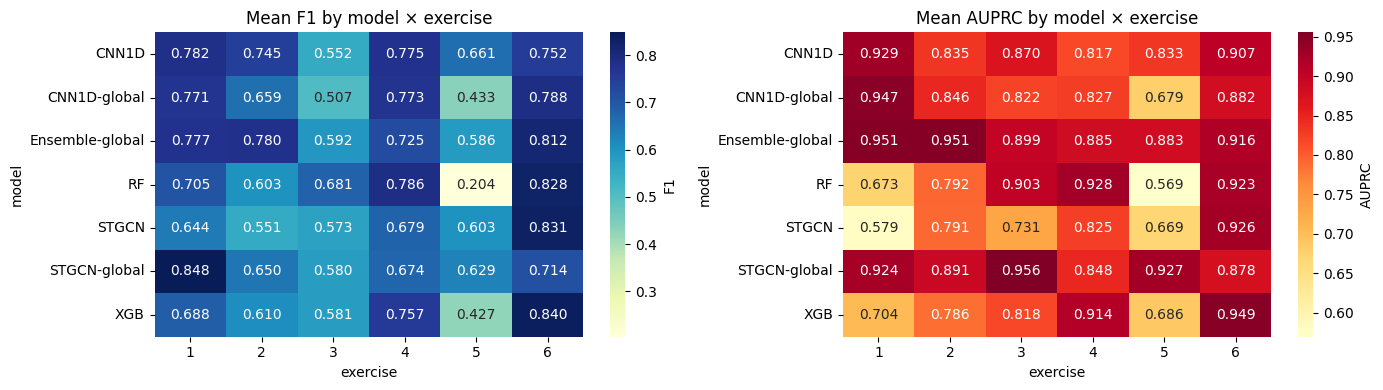

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, cmap, title in [(axes[0], 'f1', 'YlGnBu', 'F1'),
                                (axes[1], 'auprc', 'YlOrRd', 'AUPRC')]:
    piv = ALL_RESULTS.pivot_table(index='model', columns='exercise',
                                  values=metric, aggfunc='mean')
    sns.heatmap(piv, annot=True, fmt='.3f', cmap=cmap, ax=ax,
                cbar_kws={'label': metric.upper()})
    ax.set_title(f"Mean {title} by model × exercise")
plt.tight_layout(); plt.show()

### 11.3 CONFUSION MATRICES

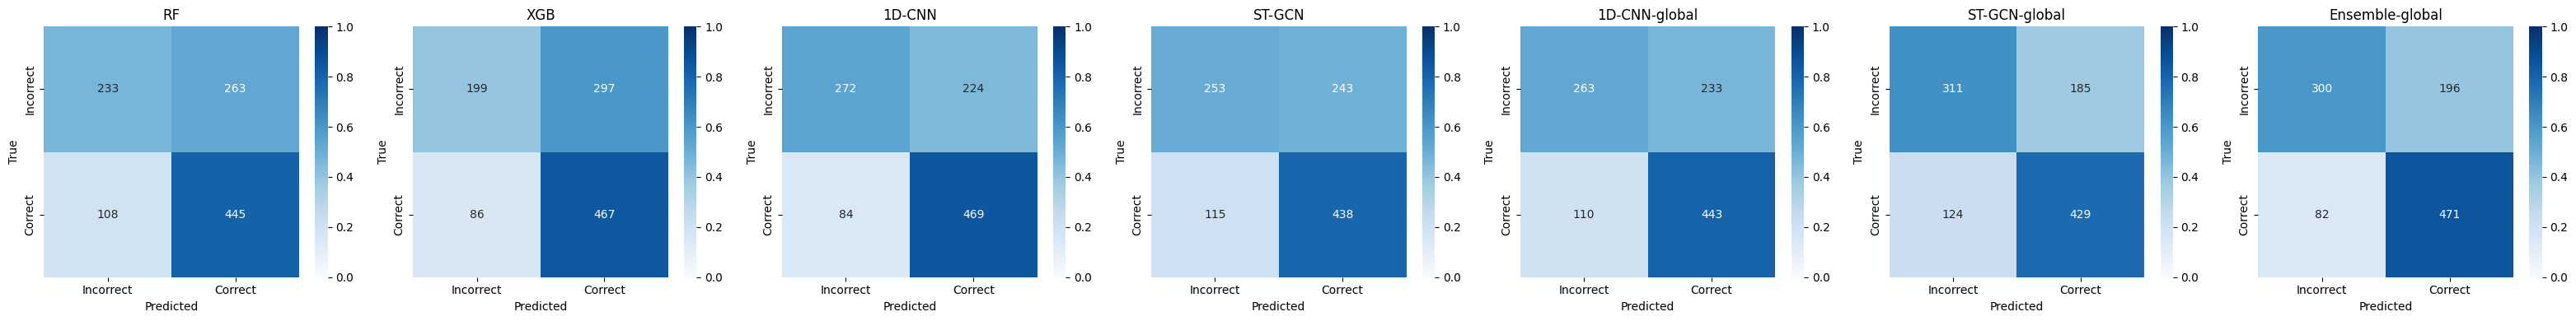

In [ ]:
def plot_cm(t, p, title, ax):
    cm = confusion_matrix(t, p, labels=[0,1])
    norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Incorrect','Correct'],
                yticklabels=['Incorrect','Correct'], vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')

MODEL_PROBS = {
    "RF":     (rf_true,    rf_probs,    rf_preds),
    "XGB":    (xgb_true,   xgb_probs,   xgb_preds),
    "1D-CNN": (cnn_true,   cnn_probs,   cnn_preds),
    "ST-GCN": (stgcn_true, stgcn_probs, stgcn_preds)
}
if 'cnn_global_results' in dir():
    MODEL_PROBS["1D-CNN-global"] = (cnn_global_true, cnn_global_probs, cnn_global_preds)
    MODEL_PROBS["ST-GCN-global"] = (stgcn_global_true, stgcn_global_probs, stgcn_global_preds)
if 'ens_global_results' in dir():
    MODEL_PROBS["Ensemble-global"] = (ens_global_true, ens_global_probs, ens_global_preds)

n = len(MODEL_PROBS)
fig, axes = plt.subplots(1, n, figsize=(4.5*n, 4))
if n == 1: axes = [axes]
for ax, (name, (t, _, p)) in zip(axes, MODEL_PROBS.items()):
    plot_cm(t, p, name, ax)
plt.tight_layout(); plt.show()


### 11.4 ROC + PRECISION-RECALL CURVES (POOLED ACROSS FOLDS)

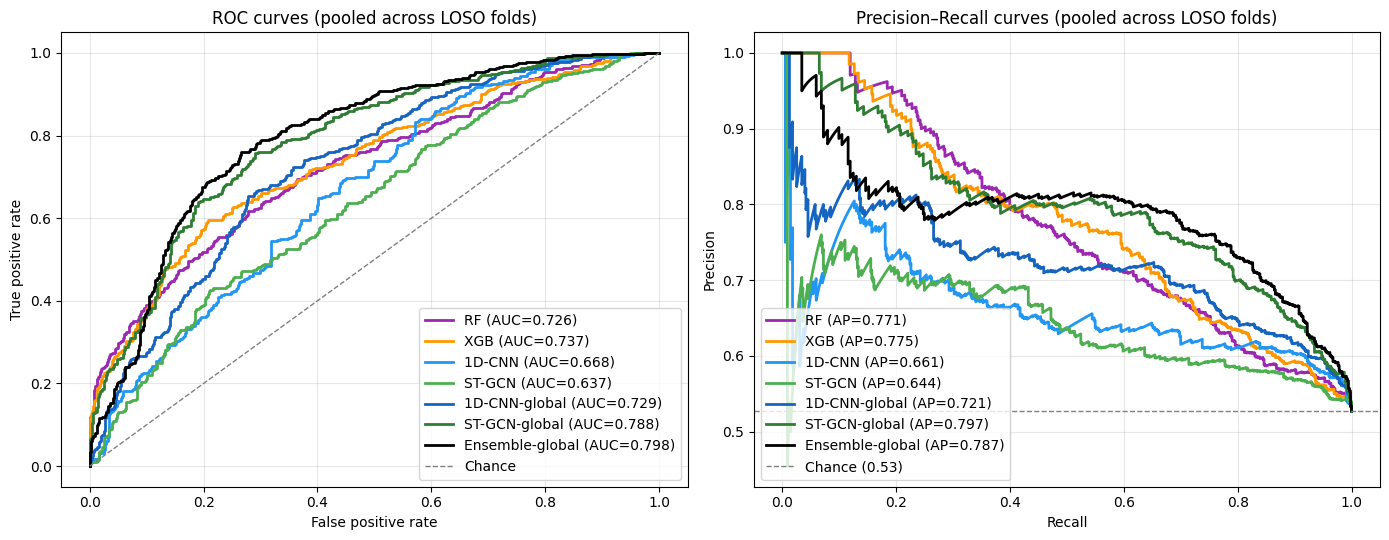

In [ ]:
COLORS = {"RF":"#9C27B0", "XGB":"#FF9800",
          "1D-CNN":"#2196F3", "ST-GCN":"#4CAF50",
          "1D-CNN-global":"#1565C0", "ST-GCN-global":"#2E7D32"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for name, (t, p, _) in MODEL_PROBS.items():
    fpr, tpr, _ = roc_curve(t, p)
    auroc = roc_auc_score(t, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auroc:.3f})",
                 color=COLORS.get(name, 'black'), lw=2)
axes[0].plot([0,1],[0,1], '--', color='gray', lw=1, label='Chance')
axes[0].set(xlabel='False positive rate', ylabel='True positive rate',
            title='ROC curves (pooled across LOSO folds)')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

for name, (t, p, _) in MODEL_PROBS.items():
    prec, rec, _ = precision_recall_curve(t, p)
    auprc = average_precision_score(t, p)
    axes[1].plot(rec, prec, label=f"{name} (AP={auprc:.3f})",
                 color=COLORS.get(name, 'black'), lw=2)
pos_rate = (rf_true == 1).mean()
axes[1].axhline(pos_rate, ls='--', color='gray', lw=1, label=f'Chance ({pos_rate:.2f})')
axes[1].set(xlabel='Recall', ylabel='Precision',
            title='Precision–Recall curves (pooled across LOSO folds)')
axes[1].legend(loc='lower left'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11.5 PER-CLASS PRECISION/RECALL/F1 CLASSIFICATION REPORT

In [ ]:
print("Per-class precision / recall / F1 (pooled across LOSO folds):\n")
for name, (t, _, pred) in MODEL_PROBS.items():
    print(f"\n=== {name} ===")
    print(classification_report(t, pred,
                                target_names=['Incorrect','Correct'],
                                digits=3, zero_division=0))

Per-class precision / recall / F1 (pooled across LOSO folds):


=== RF ===
              precision    recall  f1-score   support

   Incorrect      0.683     0.470     0.557       496
     Correct      0.629     0.805     0.706       553

    accuracy                          0.646      1049
   macro avg      0.656     0.637     0.631      1049
weighted avg      0.654     0.646     0.635      1049


=== XGB ===
              precision    recall  f1-score   support

   Incorrect      0.698     0.401     0.510       496
     Correct      0.611     0.844     0.709       553

    accuracy                          0.635      1049
   macro avg      0.655     0.623     0.609      1049
weighted avg      0.652     0.635     0.615      1049


=== 1D-CNN ===
              precision    recall  f1-score   support

   Incorrect      0.764     0.548     0.638       496
     Correct      0.677     0.848     0.753       553

    accuracy                          0.706      1049
   macro avg      0.720 

### 11.6 PER-FOLD AUROC DISTRIBUTION (BEST DL MODEL)

Best DL model by mean AUPRC: Ensemble-global


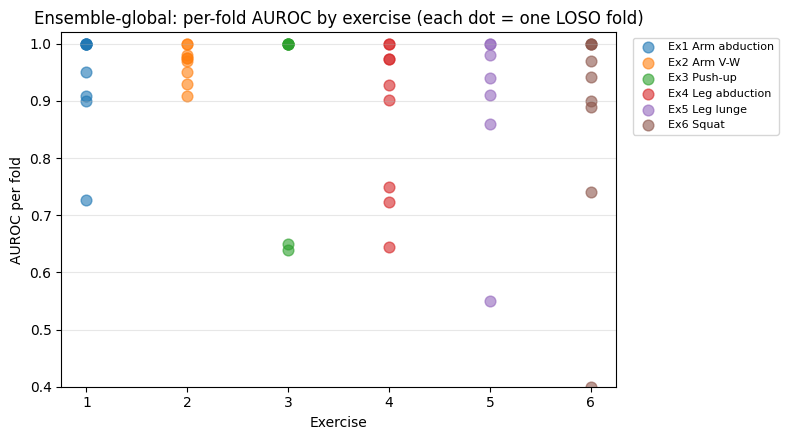

In [ ]:
dl_candidates = [('1D-CNN', cnn_results), ('ST-GCN', stgcn_results)]
if 'cnn_global_results' in dir():
    dl_candidates.extend([
        ('1D-CNN-global', cnn_global_results),
        ('ST-GCN-global', stgcn_global_results)
    ])
if 'ens_global_results' in dir():
    dl_candidates.append(('Ensemble-global', ens_global_results))

best_name, best_results = max(
    dl_candidates,
    key=lambda kv: kv[1]['auprc'].mean()
)
print(f"Best DL model by mean AUPRC: {best_name}")

fig, ax = plt.subplots(figsize=(8, 4.5))
for ex in sorted(best_results['exercise'].unique()):
    sub = best_results[best_results['exercise']==ex]['auroc'].dropna()
    ax.scatter([ex]*len(sub), sub, alpha=0.6, s=60,
               label=f"Ex{ex} {EXERCISE_NAMES[ex]}")
ax.set(xlabel='Exercise', ylabel='AUROC per fold',
       title=f'{best_name}: per-fold AUROC by exercise (each dot = one LOSO fold)')
ax.set_ylim(0.4, 1.02); ax.grid(axis='y', alpha=0.3)
ax.set_xticks(sorted(best_results['exercise'].unique()))
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

### 11.7 CALIBRATION

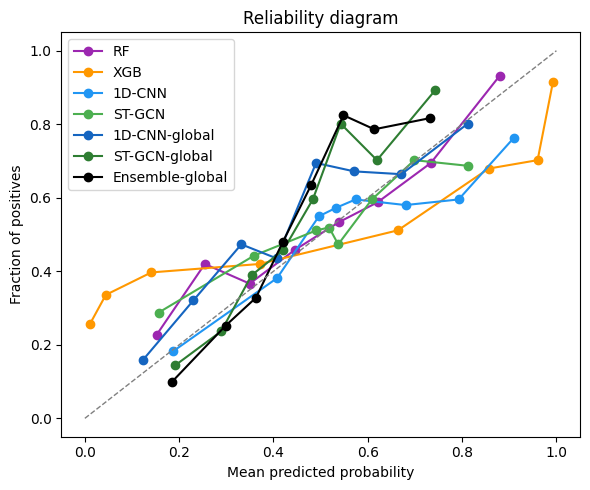

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, (t, p, _) in MODEL_PROBS.items():
    fp, mp = calibration_curve(t, p, n_bins=8, strategy='quantile')
    ax.plot(mp, fp, marker='o', label=name, color=COLORS.get(name, 'black'))
ax.plot([0,1],[0,1],'--',c='gray',lw=1)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.set_title('Reliability diagram')
ax.legend(); plt.tight_layout()
plt.show()

### 11.8 PAIRED BOOTSTRAP (BEST DL VS EACH BASELINE)

In [ ]:
# Pairs each (exercise, subject) fold across two models and bootstraps the
# distribution of fold-level AUPRC (or AUROC) differences. This is more rigorous
# than pooling predictions because it respects the LOSO structure.

def fold_level_bootstrap(all_results, best_model, other_model,
                         metric="auprc", n_boot=2000, seed=SEED):
    """Bootstrap CI for the per-fold mean (best_model[metric] - other_model[metric]).

    Pairs folds by (exercise, subject). Drops folds where either model has NaN
    on that fold (single-class test set).
    """
    a = all_results[all_results["model"] == best_model][["exercise","subject",metric]]
    b = all_results[all_results["model"] == other_model][["exercise","subject",metric]]
    paired = a.merge(b, on=["exercise","subject"],
                     suffixes=["_a","_b"])
    paired = paired.dropna(subset=[f"{metric}_a", f"{metric}_b"])
    diffs = (paired[f"{metric}_a"] - paired[f"{metric}_b"]).values
    n = len(diffs)
    if n == 0:
        return float('nan'), (float('nan'), float('nan')), float('nan'), 0

    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        boot_means[i] = diffs[idx].mean()

    mean_diff = float(diffs.mean())
    ci = (float(np.percentile(boot_means, 2.5)),
          float(np.percentile(boot_means, 97.5)))
    # Two-sided p-value: probability bootstrap mean crossed zero
    p_val = 2 * float(min((boot_means <= 0).mean(), (boot_means >= 0).mean()))
    return mean_diff, ci, p_val, n

# Pick best DL model by mean AUPRC over its folds
def model_name_from_results(df, fallback):
    vals = df["model"].dropna().unique()
    return str(vals[0]) if len(vals) > 0 else fallback

dl_candidates = [
    (model_name_from_results(cnn_results,   "CNN1D"), cnn_results),
    (model_name_from_results(stgcn_results, "STGCN"), stgcn_results)
]
if "cnn_global_results" in dir():
    dl_candidates.append(
        (model_name_from_results(cnn_global_results, "CNN1D-global"), cnn_global_results))
    dl_candidates.append(
        (model_name_from_results(stgcn_global_results, "STGCN-global"), stgcn_global_results))
if "ens_global_results" in dir():
    dl_candidates.append(
        (model_name_from_results(ens_global_results, "Ensemble-global"), ens_global_results)
    )

best_name, best_results = max(dl_candidates,
                              key=lambda kv: kv[1]["auprc"].mean())

print("Available model names:", sorted(ALL_RESULTS["model"].unique()))
print(f"Best DL model by mean AUPRC: {best_name}\n")
print(f"Fold-level paired bootstrap: {best_name} vs each other model (AUPRC)")

for name in sorted(ALL_RESULTS["model"].unique()):
    if name == best_name:
        continue
    m, ci, p, n_pair = fold_level_bootstrap(
        ALL_RESULTS, best_model=best_name, other_model=name, metric="auprc")
    print(f"  {best_name:>14s} vs {name:>14s}: "
          f"ΔAUPRC={m:+.4f}  CI95=({ci[0]:+.4f},{ci[1]:+.4f})  "
          f"p≈{p:.4f}  n_paired_folds={n_pair}")

# Also do AUROC for completeness
print(f"\nFold-level paired bootstrap: {best_name} vs each other model (AUROC)")
for name in sorted(ALL_RESULTS["model"].unique()):
    if name == best_name:
        continue
    m, ci, p, n_pair = fold_level_bootstrap(
        ALL_RESULTS, best_model=best_name, other_model=name, metric="auroc")
    print(f"  {best_name:>14s} vs {name:>14s}: "
          f"ΔAUROC={m:+.4f}  CI95=({ci[0]:+.4f},{ci[1]:+.4f})  "
          f"p≈{p:.4f}  n_paired_folds={n_pair}")

Available model names: ['CNN1D', 'CNN1D-global', 'Ensemble-global', 'RF', 'STGCN', 'STGCN-global', 'XGB']
Best DL model by mean AUPRC: Ensemble-global

Fold-level paired bootstrap: Ensemble-global vs each other model (AUPRC)
  Ensemble-global vs          CNN1D: ΔAUPRC=+0.0501  CI95=(+0.0076,+0.0968)  p≈0.0160  n_paired_folds=50
  Ensemble-global vs   CNN1D-global: ΔAUPRC=+0.0756  CI95=(+0.0404,+0.1161)  p≈0.0000  n_paired_folds=50
  Ensemble-global vs             RF: ΔAUPRC=+0.1130  CI95=(+0.0589,+0.1702)  p≈0.0000  n_paired_folds=50
  Ensemble-global vs          STGCN: ΔAUPRC=+0.1583  CI95=(+0.0914,+0.2292)  p≈0.0000  n_paired_folds=50
  Ensemble-global vs   STGCN-global: ΔAUPRC=+0.0154  CI95=(-0.0106,+0.0403)  p≈0.2400  n_paired_folds=50
  Ensemble-global vs            XGB: ΔAUPRC=+0.1021  CI95=(+0.0498,+0.1584)  p≈0.0000  n_paired_folds=50

Fold-level paired bootstrap: Ensemble-global vs each other model (AUROC)
  Ensemble-global vs          CNN1D: ΔAUROC=+0.0596  CI95=(+0.0060,+0.1

## 12. EXPLAINABILITY

### 12.1 GRAD-CAM + PER-JOINT SALIENCY UTILITIES

In [ ]:
class STGCNGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = self.gradients = None
        self._fwd = target_layer.register_forward_hook(
            lambda m,i,o: setattr(self, 'activations', o.detach()))
        if hasattr(target_layer, 'register_full_backward_hook'):
            self._bwd = target_layer.register_full_backward_hook(
                lambda m,i,o: setattr(self, 'gradients', o[0].detach()))
        else:
            self._bwd = target_layer.register_backward_hook(
                lambda m,i,o: setattr(self, 'gradients', o[0].detach()))
    def __call__(self, x, class_idx=None):
        self.model.eval()
        x = x.clone().requires_grad_(True)
        logits = self.model(x)
        if class_idx is None: class_idx = int(logits.argmax(1).item())
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean((2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(1))
        return cam.squeeze(0).cpu().numpy(), class_idx, logits.detach().cpu().numpy()

def joint_saliency(model, x, class_idx=None):
    model.eval()
    x = x.clone().requires_grad_(True)
    logits = model(x)
    if class_idx is None: class_idx = int(logits.argmax(1).item())
    model.zero_grad()
    logits[0, class_idx].backward()
    return x.grad.abs().mean((0, 1, 2)).cpu().numpy(), class_idx

### 12.2 TRAIN EXPLAINER MODEL ON EX6 (SQUATS)

In [ ]:
EX_FOR_EXPLAIN = 6
ex_mask = EX_ARR == EX_FOR_EXPLAIN
clips_ex, y_ex, g_ex = CLIPS[ex_mask], Y[ex_mask], GROUPS[ex_mask]
global_idx_of_local = np.where(ex_mask)[0]

for candidate_subject in sorted(np.unique(g_ex)):
    HOLDOUT_SUBJECT = candidate_subject
    VAL_SUBJECT = choose_val_subject(g_ex, y_ex, HOLDOUT_SUBJECT)

    te_local = np.where(g_ex == HOLDOUT_SUBJECT)[0]
    va_local = np.where(g_ex == VAL_SUBJECT)[0]
    tr_local = np.where((g_ex != HOLDOUT_SUBJECT) & (g_ex != VAL_SUBJECT))[0]

    # Fast check: if no incorrect ground truth reps, skip to next subject
    if (y_ex[te_local] == 0).sum() == 0:
        continue

    print(
        f"Explanation holdout subject: {HOLDOUT_SUBJECT}  "
        f"(train={len(tr_local)}, val={len(va_local)}, test={len(te_local)})"
    )
    print(f"Explanation validation subject: {VAL_SUBJECT}")

    xmodel = train_for_explainability(
        STGCN,
        dict(num_joints=NUM_JOINTS, in_channels=15, A=A_NORM),
        clips_ex[tr_local],
        y_ex[tr_local],
        n_epochs=30,
        cfg=CFG,
    )
    cam_ext = STGCNGradCAM(xmodel, xmodel.blocks[-1])

    ex_probs = predict_probs(xmodel, clips_ex[te_local], y_ex[te_local])
    ex_preds = (ex_probs >= 0.5).astype(int)

    true_inc = np.where((y_ex[te_local] == 0) & (ex_preds == 0))[0]
    if len(true_inc) == 0:
        true_inc = np.where(y_ex[te_local] == 0)[0]

    if len(true_inc) > 0:
        break
else:
    raise RuntimeError("No subjects have incorrect reps for this exercise")

local_in_te = int(true_inc[0])
local_idx_in_ex = int(te_local[local_in_te])
global_idx = int(global_idx_of_local[local_idx_in_ex])

print(f"\nSelected sample: ex-local idx={local_idx_in_ex}, global idx={global_idx}")


Explanation holdout subject: 1  (train=143, val=21, test=27)
Explanation validation subject: 6
  explainability epoch 10/30: loss=0.0872
  explainability epoch 20/30: loss=0.0475
  explainability epoch 30/30: loss=0.0369

Selected sample: ex-local idx=16, global idx=874


In [ ]:
x_ex = torch.from_numpy(clips_ex[local_idx_in_ex]).permute(2,0,1).unsqueeze(0).float().to(DEVICE)
cam, cls, logits = cam_ext(x_ex, class_idx=0)
sal, _ = joint_saliency(xmodel, x_ex, class_idx=0)
print(f"Predicted class: {cls} ({'incorrect' if cls==0 else 'correct'})")
print(f"Logits: {logits.squeeze()}")

Predicted class: 0 (incorrect)
Logits: [ 0.4217099 -0.1028738]


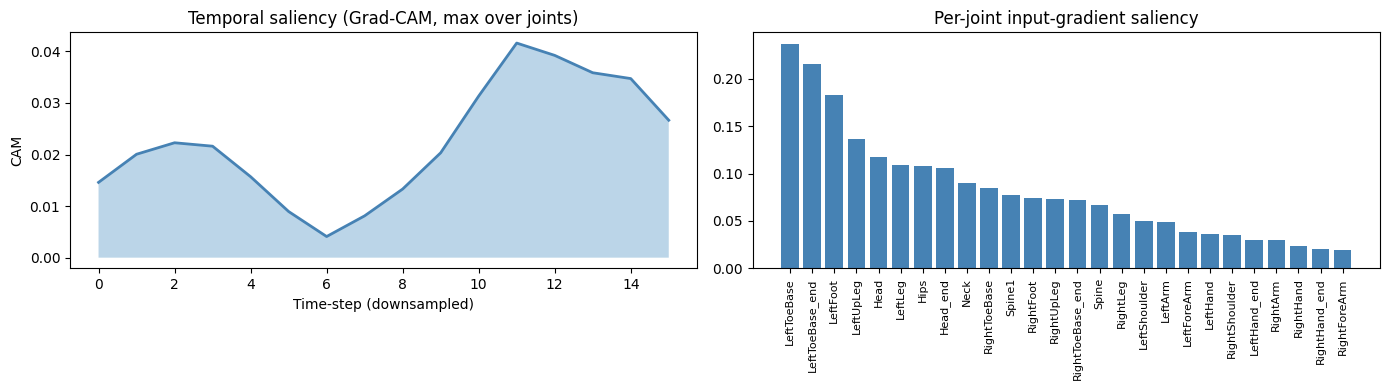


Top-5 joints driving 'incorrect' prediction:
           LeftToeBase: 0.2369
       LeftToeBase_end: 0.2152
              LeftFoot: 0.1830
             LeftUpLeg: 0.1359
                  Head: 0.1170


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cam.max(1), lw=2, c='steelblue')
axes[0].fill_between(np.arange(len(cam)), 0, cam.max(1), alpha=0.3)
axes[0].set_title("Temporal saliency (Grad-CAM, max over joints)")
axes[0].set_xlabel("Time-step (downsampled)"); axes[0].set_ylabel("CAM")

order = np.argsort(-sal)
axes[1].bar(range(len(sal)), sal[order], color='steelblue')
axes[1].set_xticks(range(len(sal)))
axes[1].set_xticklabels([JOINT_NAMES[i] for i in order], rotation=90, fontsize=8)
axes[1].set_title("Per-joint input-gradient saliency")
plt.tight_layout(); plt.show()

print("\nTop-5 joints driving 'incorrect' prediction:")
for j in order[:5]:
    print(f"  {JOINT_NAMES[j]:>20s}: {sal[j]:.4f}")

### 12.3 ML/DL AGREEMENT ON THE SAME REP

In [ ]:
ex_X = X_FEAT[ex_mask]

# Train XGBoost explainer only on non-holdout-subject data.
xgb_train_local = np.concatenate([tr_local, va_local])

sc = StandardScaler().fit(ex_X[xgb_train_local])
ex_X_scaled = sc.transform(ex_X)

xmdl = xgb_factory()

y_train_xgb = y_ex[xgb_train_local]
n_pos = max(1, int(y_train_xgb.sum()))
n_neg = max(1, int(len(y_train_xgb) - y_train_xgb.sum()))
xmdl.set_params(scale_pos_weight=n_neg / n_pos)

xmdl.fit(ex_X_scaled[xgb_train_local], y_train_xgb)

sv = shap.TreeExplainer(xmdl).shap_values(
    ex_X_scaled[local_idx_in_ex:local_idx_in_ex + 1]
)

ranked = sorted(zip(FEAT_COLS, sv[0]), key=lambda kv: -abs(kv[1]))

print(f"XGBoost SHAP for rep {global_idx} — top features:")
for n, v in ranked[:8]:
    print(f"  {n:>22s}: shap={v:+.4f}")

print(f"\nST-GCN top joints for the SAME rep:")
for j in order[:5]:
    print(f"  {JOINT_NAMES[j]:>22s}: saliency={sal[j]:+.4f}")

XGBoost SHAP for rep 874 — top features:
        rknee_over_ankle: shap=+1.0637
           sym_elbow_max: shap=-0.9122
               rknee_min: shap=+0.7672
          sym_elbow_mean: shap=+0.3538
               rknee_std: shap=-0.3183
        lknee_over_ankle: shap=+0.2965
      trunk_sagittal_rom: shap=-0.2442
           lhand_y_reach: shap=-0.2438

ST-GCN top joints for the SAME rep:
             LeftToeBase: saliency=+0.2369
         LeftToeBase_end: saliency=+0.2152
                LeftFoot: saliency=+0.1830
               LeftUpLeg: saliency=+0.1359
                    Head: saliency=+0.1170


## 13. VISUAL FEEDBACK OUTPUT

### 13.1 CUE RULES

In [ ]:
# Per-exercise rules.
# (feature_substring, direction, cue_text, anchor_joint)
#   direction is applied to the feature z-score versus correct reps.
#   +1 = feature too high, -1 = feature too low, 0 = either direction.

CUE_RULES_PER_EXERCISE = {
    1: [  # Arm abduction
        ("hand_y_sym",      1, "RAISE BOTH ARMS TOGETHER",    LSHOULDER_IDX),
        ("lhand_y_reach",  -1, "LIFT YOUR LEFT ARM HIGHER",   LSHOULDER_IDX),
        ("rhand_y_reach",  -1, "LIFT YOUR RIGHT ARM HIGHER",  RSHOULDER_IDX),
        ("trunk_incl",      1, "KEEP TORSO UPRIGHT",          NECK_IDX),
        ("sym_elbow",       1, "KEEP ELBOWS SYMMETRICAL",     LIMB_JOINTS["lelbow"]),
        ("lshld_abd",       1, "DON'T SHRUG LEFT SHOULDER",   LSHOULDER_IDX),
        ("rshld_abd",       1, "DON'T SHRUG RIGHT SHOULDER",  RSHOULDER_IDX),
    ],

    2: [  # Arm V-W
        ("sym_elbow",       1, "KEEP ELBOWS SYMMETRICAL",     LIMB_JOINTS["lelbow"]),
        ("trunk_incl",      1, "KEEP TORSO UPRIGHT",          NECK_IDX),
        ("relbow",         -1, "FULL ELBOW EXTENSION",        LIMB_JOINTS["relbow"]),
        ("lelbow",         -1, "FULL ELBOW EXTENSION",        LIMB_JOINTS["lelbow"]),
        ("lhand_y_reach",  -1, "REACH HIGHER WITH LEFT ARM",  LSHOULDER_IDX),
        ("rhand_y_reach",  -1, "REACH HIGHER WITH RIGHT ARM", RSHOULDER_IDX),
    ],

    3: [  # Push-up
        ("relbow",          1, "GO LOWER, ELBOWS DEEPER",       LIMB_JOINTS["relbow"]),
        ("lelbow",          1, "GO LOWER, ELBOWS DEEPER",       LIMB_JOINTS["lelbow"]),
        ("trunk_sagittal",  1, "KEEP CORE TIGHT — NO HIP DROP", PELVIS_IDX),
        ("sym_elbow",       1, "ELBOWS EVEN — DON'T LIST",      LIMB_JOINTS["lelbow"]),
        ("trunk_incl",      1, "KEEP BODY STRAIGHT",            CHEST_IDX),
        ("jerk_lelbow",     1, "CONTROL THE DESCENT",           LIMB_JOINTS["lelbow"]),
        ("jerk_relbow",     1, "CONTROL THE DESCENT",           LIMB_JOINTS["relbow"]),
    ],

    4: [  # Leg abduction
        ("sym_knee",        1, "MATCH BOTH LEGS",              LIMB_JOINTS["lknee"]),
        ("trunk_incl",      1, "STAY UPRIGHT",                 NECK_IDX),
        ("lhip",            0, "CONTROL HIP POSITION",          LIMB_JOINTS["lhip"]),
        ("rhip",            0, "CONTROL HIP POSITION",          LIMB_JOINTS["rhip"]),
        ("lknee_z_drift",   1, "KEEP LEFT KNEE STRAIGHT",       LIMB_JOINTS["lknee"]),
        ("rknee_z_drift",   1, "KEEP RIGHT KNEE STRAIGHT",      LIMB_JOINTS["rknee"]),
    ],

    5: [  # Leg lunge
        ("lhip_y_drop",    -1, "DEEPER LUNGE — DROP HIPS",      LIMB_JOINTS["lhip"]),
        ("rhip_y_drop",    -1, "DEEPER LUNGE — DROP HIPS",      LIMB_JOINTS["rhip"]),
        ("lknee",           0, "CONTROL FRONT-KNEE TRACKING",   LIMB_JOINTS["lknee"]),
        ("rknee",           0, "CONTROL FRONT-KNEE TRACKING",   LIMB_JOINTS["rknee"]),
        ("trunk_sagittal",  1, "KEEP TORSO UPRIGHT",            NECK_IDX),
        ("sym_knee",        1, "EVEN BOTH SIDES",               LIMB_JOINTS["lknee"]),
        ("lhip_flex",       1, "DON'T BEND HIPS TOO MUCH",      LIMB_JOINTS["lhip"]),
        ("rhip_flex",       1, "DON'T BEND HIPS TOO MUCH",      LIMB_JOINTS["rhip"]),
    ],

    6: [  # Squat
        ("lknee_min",       1, "GO DEEPER",                          LIMB_JOINTS["lknee"]),
        ("rknee_min",       1, "GO DEEPER",                          LIMB_JOINTS["rknee"]),
        ("lknee_z_drift",   1, "DON'T LET LEFT KNEE TRACK FORWARD",  LIMB_JOINTS["lknee"]),
        ("rknee_z_drift",   1, "DON'T LET RIGHT KNEE TRACK FORWARD", LIMB_JOINTS["rknee"]),
        ("lknee_over_ankle",1, "KEEP LEFT KNEE OVER ANKLE",          LIMB_JOINTS["lknee"]),
        ("rknee_over_ankle",1, "KEEP RIGHT KNEE OVER ANKLE",         LIMB_JOINTS["rknee"]),
        ("trunk_sagittal",  1, "KEEP YOUR BACK UPRIGHT",             NECK_IDX),
        ("sym_knee",        1, "DRIVE BOTH KNEES EVENLY",            LIMB_JOINTS["lknee"]),
        ("jerk_lknee",       1, "CONTROL THE DESCENT",               LIMB_JOINTS["lknee"]),
        ("jerk_rknee",       1, "CONTROL THE DESCENT",               LIMB_JOINTS["rknee"]),
        ("lhip_y_drop",    -1, "DROP HIPS LOWER",                    LIMB_JOINTS["lhip"]),
        ("rhip_y_drop",    -1, "DROP HIPS LOWER",                    LIMB_JOINTS["rhip"]),
    ],
}

DEFAULT_CUE = "GOOD FORM — KEEP IT UP"


def _relevant_feature_indices(exercise, feat_cols):
    """Only rank deviations that are meaningful for that exercise's cue rules."""
    rules = CUE_RULES_PER_EXERCISE.get(int(exercise), [])
    substrs = [substr for substr, *_ in rules]

    if not substrs:
        return list(range(len(feat_cols)))

    idx = [
        i for i, name in enumerate(feat_cols)
        if any(substr in name for substr in substrs)
    ]

    return idx if idx else list(range(len(feat_cols)))


def deviation_report(rep_global_idx, exercise, X, y, ex_arr, feat_cols, top_k=6):
    """Deviation report restricted to exercise-relevant cue features."""
    pop = (y == 1) & (ex_arr == exercise)

    mu = X[pop].mean(0)
    sigma = X[pop].std(0) + 1e-6
    z = (X[rep_global_idx] - mu) / sigma

    relevant_idx = _relevant_feature_indices(exercise, feat_cols)
    ranked_idx = sorted(relevant_idx, key=lambda i: -abs(z[i]))[:top_k]

    return {
        "exercise": int(exercise),
        "true_label": int(y[rep_global_idx]),
        "deviations": [
            {
                "feature": feat_cols[i],
                "z": float(z[i]),
                "value": float(X[rep_global_idx, i]),
                "norm_mean": float(mu[i]),
            }
            for i in ranked_idx
        ],
    }


def deviation_to_cue(report, z_threshold=1.5):
    rules = CUE_RULES_PER_EXERCISE.get(report["exercise"], [])

    for d in report["deviations"]:
        if abs(d["z"]) < z_threshold:
            continue

        for substr, direction, cue, anchor in rules:
            if substr not in d["feature"]:
                continue
            if direction != 0 and np.sign(d["z"]) != direction:
                continue

            return cue, anchor, d

    # Fallback if no specific rule matched but rep is incorrect
    if report["true_label"] == 0:
         return "CHECK FORM (DEVIATION DETECTED)", PELVIS_IDX, report["deviations"][0] if report["deviations"] else None

    return DEFAULT_CUE, PELVIS_IDX, None


### 13.2 SKELETON DRAWING UTILITY

In [ ]:
def draw_skeleton_frame(ax, frame, bones, cue=None, anchor=None, title="",
                        x_lim=None, y_lim=None, cue_color='#1976D2'):
    xs, ys = frame[:, 0], frame[:, 1]
    for p, c in bones:
        ax.plot([xs[p], xs[c]], [ys[p], ys[c]], color='#FFD700', lw=4, zorder=2)
    ax.scatter(xs, ys, s=70, c='#E53935', edgecolors='black', lw=0.8, zorder=3)
    if cue is not None and anchor is not None:
        ax_xy = (xs[anchor], ys[anchor])
        text_xy = (ax_xy[0] + (-1.4 if ax_xy[0] > 0 else 1.4), ax_xy[1] + 0.4)
        ax.annotate(cue, xy=ax_xy, xytext=text_xy,
                    fontsize=11, fontweight='bold', color='white',
                    ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.4", fc=cue_color,
                              ec='white', lw=1.5),
                    arrowprops=dict(arrowstyle='->', color='white', lw=2))
    ax.set_facecolor('#2E2E2E')
    if x_lim: ax.set_xlim(x_lim)
    if y_lim: ax.set_ylim(y_lim)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor('#1976D2'); sp.set_linewidth(2)
    if title: ax.set_title(title, color='white', fontsize=11, pad=6)

### 13.3 STILL PANEL — ONE INCORRECT REP PER EXERCISE

In [ ]:
import re

# Define find_failure_frame here so §13.3 can use it (was previously only in §13.4).
def find_failure_frame(clip, top_dev_feature):
    """Pick the frame that best illustrates the deviation."""
    if top_dev_feature is None:
        return clip.shape[0] // 2

    name = top_dev_feature.lower()
    L = LIMB_JOINTS

    # Position-feature heuristics
    if re.search(r'lhip_y_drop', name):
        return int(clip[:, L["lhip"], 1].argmin())
    if re.search(r'rhip_y_drop', name):
        return int(clip[:, L["rhip"], 1].argmin())

    if re.search(r'lknee.*(z.*drift|over.*ankle)', name):
        return int(clip[:, L["lknee"], 2].argmax())
    if re.search(r'rknee.*(z.*drift|over.*ankle)', name):
        return int(clip[:, L["rknee"], 2].argmax())

    if re.search(r'lhand_y_reach', name):
        return int(clip[:, L["lwrist"], 1].argmax())
    if re.search(r'rhand_y_reach', name):
        return int(clip[:, L["rwrist"], 1].argmax())
    if re.search(r'hand_y_sym', name):
        hand_diff = np.abs(clip[:, L["lwrist"], 1] - clip[:, L["rwrist"], 1])
        return int(hand_diff.argmax())

    if re.search(r'trunk_sagittal', name):
        trunk_vec = clip[:, CHEST_IDX, :] - clip[:, PELVIS_IDX, :]
        return int(np.abs(np.arctan2(trunk_vec[:, 2], trunk_vec[:, 1] + 1e-8)).argmax())

    if re.search(r'sym_knee', name):
        left = angle_at(clip, L["lhip"], L["lknee"], L["lankle"])
        right = angle_at(clip, L["rhip"], L["rknee"], L["rankle"])
        return int(np.abs(left - right).argmax())

    if re.search(r'sym_elbow', name):
        left = angle_at(clip, L["luarm"], L["lelbow"], L["lwrist"])
        right = angle_at(clip, L["ruarm"], L["relbow"], L["rwrist"])
        return int(np.abs(left - right).argmax())

    # Angle-feature heuristics
    angle_fns = {
        "lknee":      lambda c: angle_at(c, L["lhip"],  L["lknee"],  L["lankle"]),
        "rknee":      lambda c: angle_at(c, L["rhip"],  L["rknee"],  L["rankle"]),
        "lelbow":     lambda c: angle_at(c, L["luarm"], L["lelbow"], L["lwrist"]),
        "relbow":     lambda c: angle_at(c, L["ruarm"], L["relbow"], L["rwrist"]),
        "lshld_abd":  lambda c: angle_to_vertical(c, L["luarm"], L["lshld"]),
        "rshld_abd":  lambda c: angle_to_vertical(c, L["ruarm"], L["rshld"]),
        "trunk_incl": lambda c: angle_to_vertical(c, CHEST_IDX, PELVIS_IDX),
    }

    for key, fn in angle_fns.items():
        if re.search(key, name):
            angles = fn(clip)
            return int(angles.argmax() if re.search(r'max|rom', name) else angles.argmin())

    return clip.shape[0] // 2


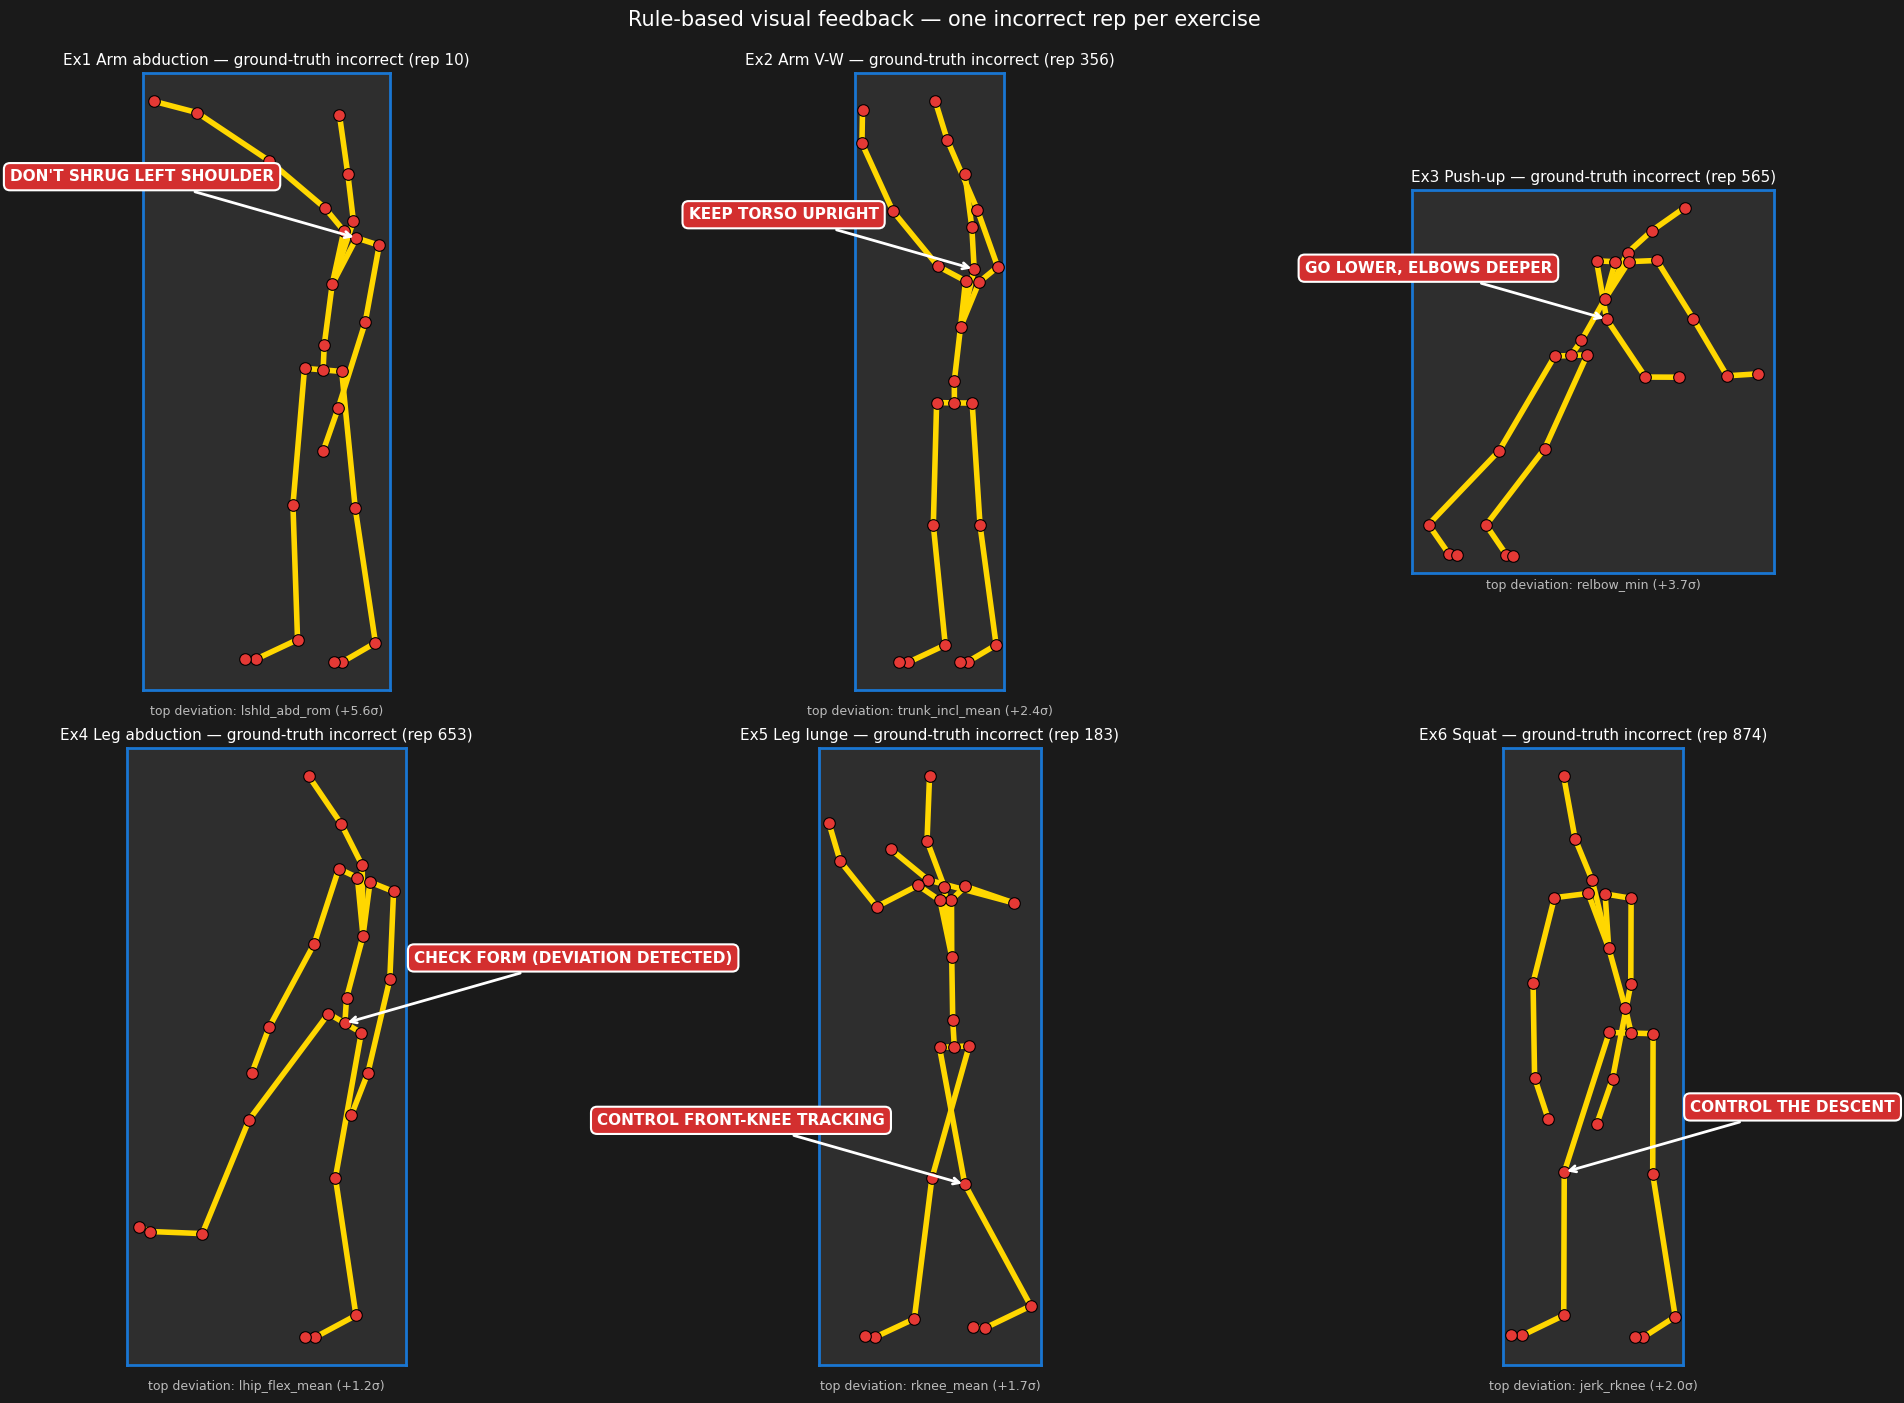

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 14), facecolor='#1A1A1A')

for ax, ex in zip(axes.flat, sorted(REP_META['exercise'].unique())):
    bad = REP_META[(REP_META['exercise']==ex) & (REP_META['correct']==0)].index
    if len(bad) == 0:
        ax.axis('off'); continue
    rep_idx = int(bad[0])
    report = deviation_report(rep_idx, ex, X_FEAT, Y, EX_ARR, FEAT_COLS)
    cue, anchor, top_dev = deviation_to_cue(report, z_threshold=1.5)
    cue_color = '#1976D2' if cue == DEFAULT_CUE else '#D32F2F'
    footer = (f"top deviation: {top_dev['feature']} ({top_dev['z']:+.1f}σ)"
              if top_dev else "no significant deviation above 1.5σ")
    clip = CLIPS[rep_idx]
    failure_t = find_failure_frame(clip, top_dev['feature'] if top_dev else None)
    frame = clip[failure_t]
    draw_skeleton_frame(ax, frame, BONES, cue=cue, anchor=anchor,
        title=f"Ex{ex} {EXERCISE_NAMES[ex]} — ground-truth incorrect (rep {rep_idx})",
        cue_color=cue_color)
    ax.text(0.5, -0.04, footer, transform=ax.transAxes, ha='center',
            color='#BBBBBB', fontsize=9)

plt.suptitle("Rule-based visual feedback — one incorrect rep per exercise",
             color='white', fontsize=15, y=0.995)
plt.tight_layout()
plt.show()

### 13.4 SIDE-BY-SIDE CORRECT VS INCORRECT

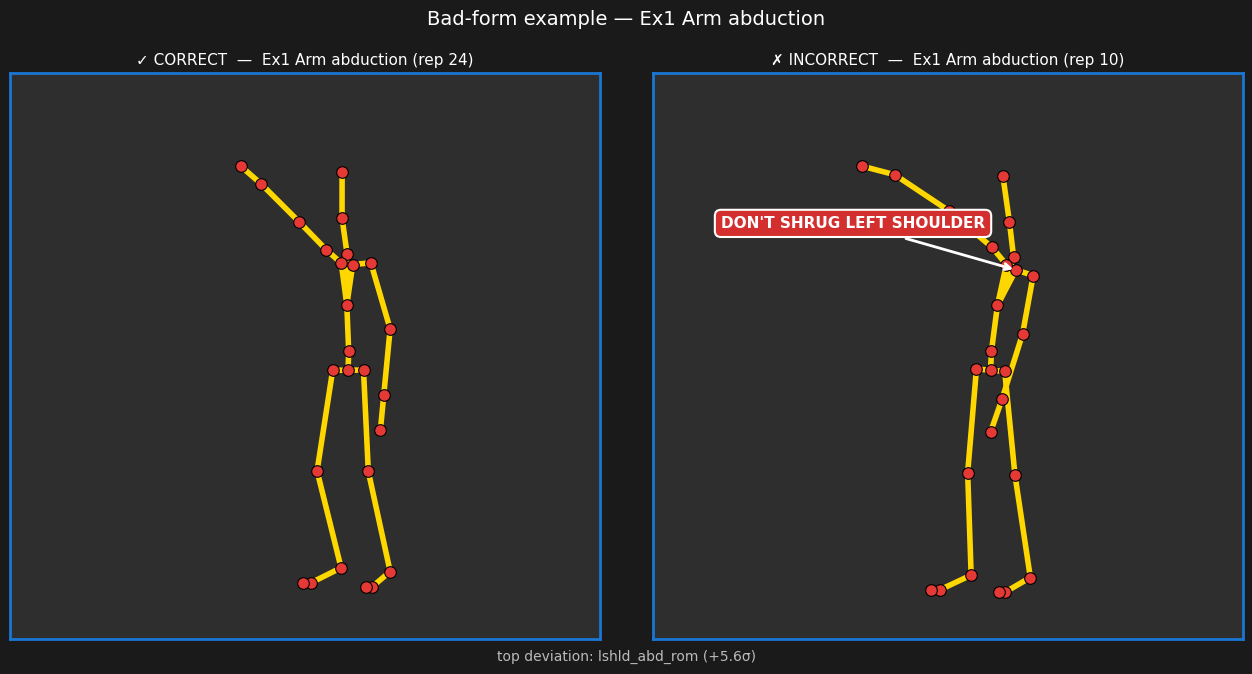

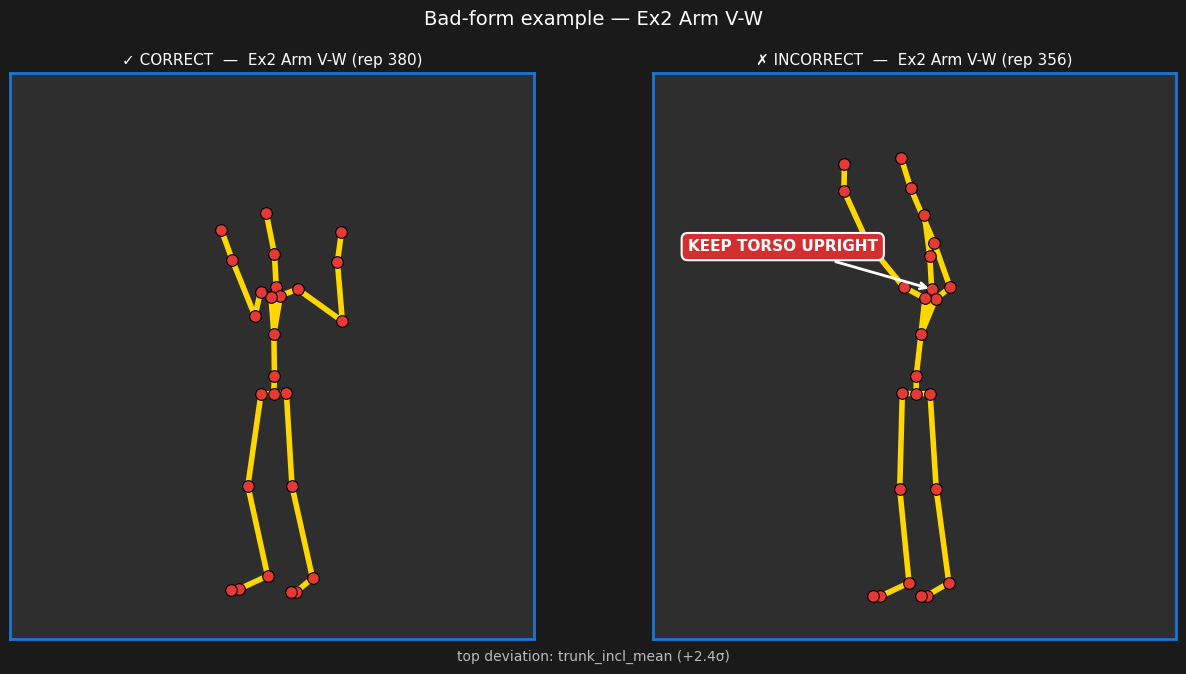

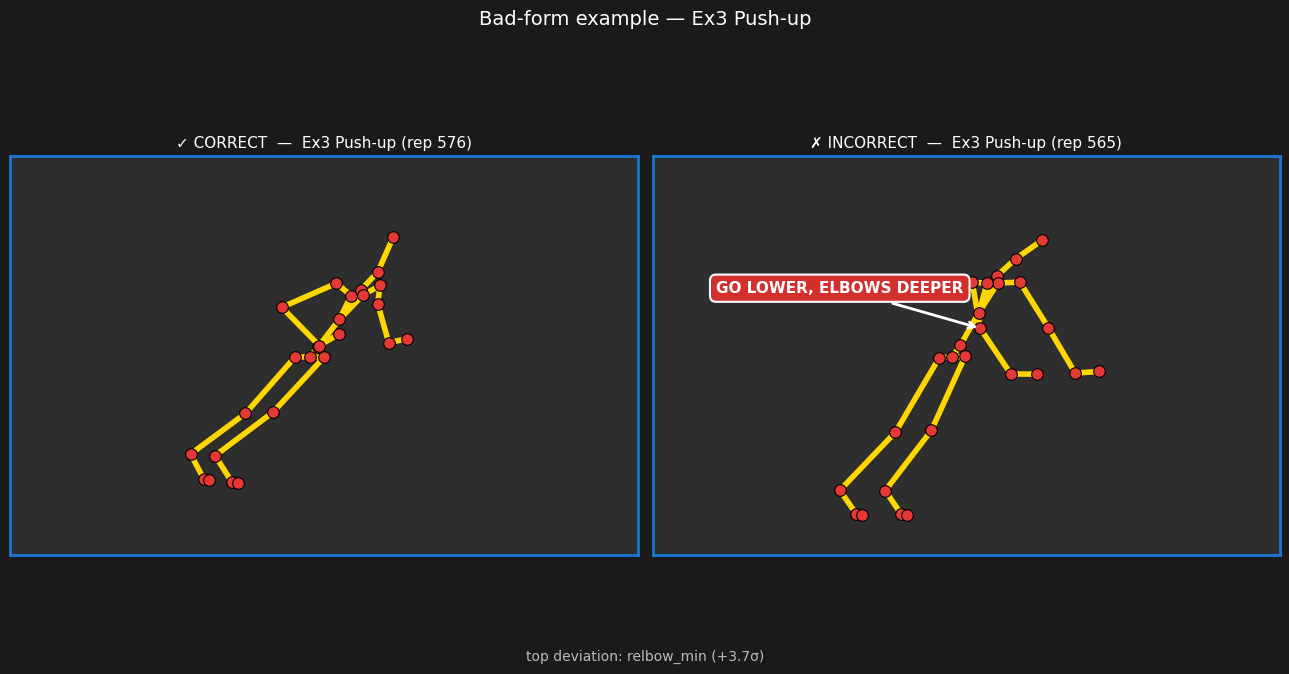

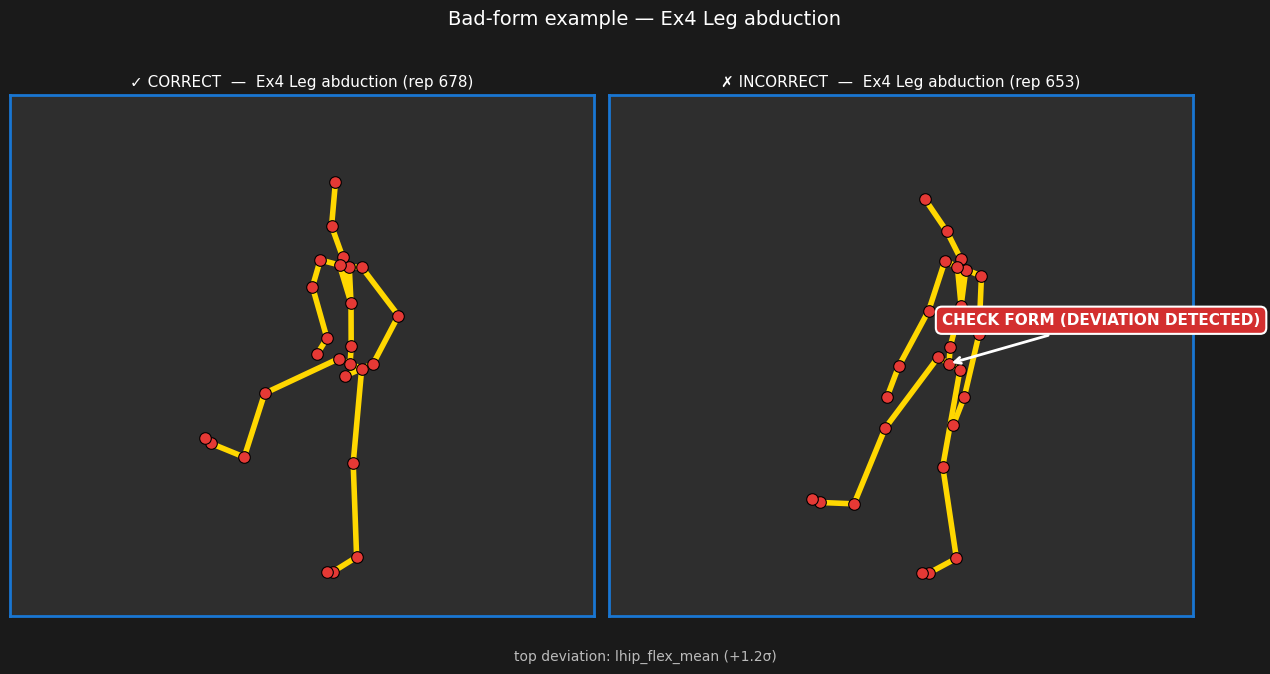

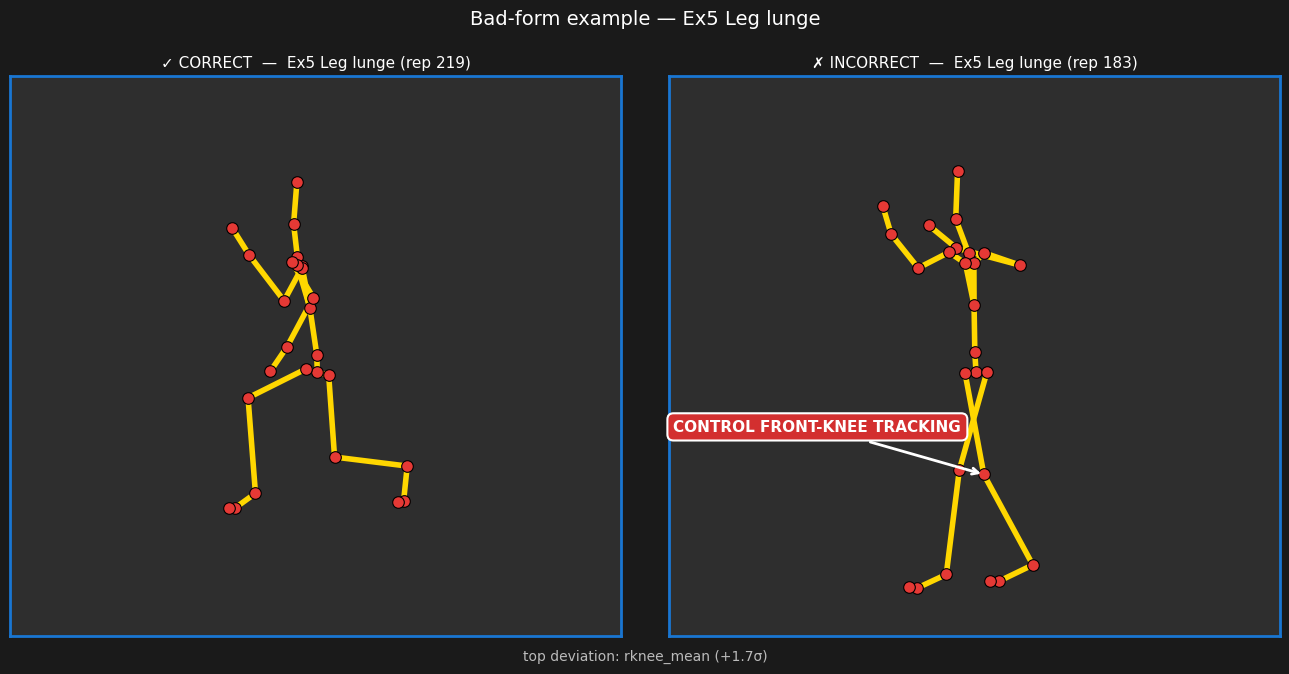

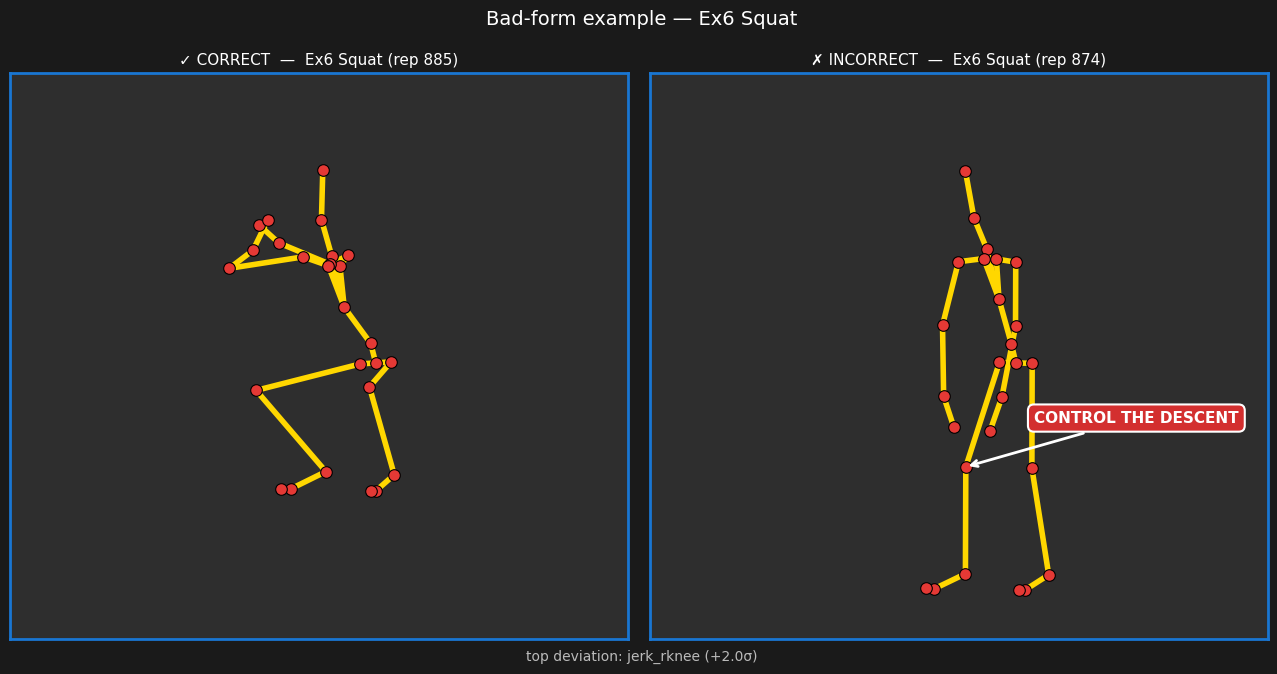

In [ ]:
def pick_bad_and_good_reps(exercise: int):
    bad_pool  = REP_META[(REP_META['exercise']==exercise) & (REP_META['correct']==0)].index
    good_pool = REP_META[(REP_META['exercise']==exercise) & (REP_META['correct']==1)].index
    if len(bad_pool) == 0 or len(good_pool) == 0: return None, None
    bad_idx = int(bad_pool[0])
    bad_subj = int(REP_META.loc[bad_idx, 'subject'])
    good_other = [int(i) for i in good_pool if int(REP_META.loc[i,'subject']) != bad_subj]
    good_idx = int(good_other[0]) if good_other else int(good_pool[0])
    return bad_idx, good_idx

def render_good_vs_bad_still(exercise: int):
    bad_idx, good_idx = pick_bad_and_good_reps(exercise)
    if bad_idx is None: return None
    report = deviation_report(bad_idx, exercise, X_FEAT, Y, EX_ARR, FEAT_COLS)
    cue, anchor, top_dev = deviation_to_cue(report, z_threshold=1.5)
    cue_color = '#1976D2' if cue == DEFAULT_CUE else '#D32F2F'

    bad_clip, good_clip = CLIPS[bad_idx], CLIPS[good_idx]
    failure_t = find_failure_frame(bad_clip, top_dev['feature'] if top_dev else None)
    good_t = good_clip.shape[0] // 2

    all_xy = np.concatenate([bad_clip[failure_t,:,:2], good_clip[good_t,:,:2]])
    x_lim = (all_xy[:,0].min() - 1.8, all_xy[:,0].max() + 1.8)
    y_lim = (all_xy[:,1].min() - 0.4, all_xy[:,1].max() + 0.8)

    fig, axes = plt.subplots(1, 2, figsize=(13, 7), facecolor='#1A1A1A')
    draw_skeleton_frame(axes[0], good_clip[good_t], BONES,
        title=f"✓ CORRECT  —  Ex{exercise} {EXERCISE_NAMES[exercise]} (rep {good_idx})",
        x_lim=x_lim, y_lim=y_lim)
    draw_skeleton_frame(axes[1], bad_clip[failure_t], BONES, cue=cue, anchor=anchor,
        title=f"✗ INCORRECT  —  Ex{exercise} {EXERCISE_NAMES[exercise]} (rep {bad_idx})",
        x_lim=x_lim, y_lim=y_lim, cue_color=cue_color)
    footer = (f"top deviation: {top_dev['feature']} ({top_dev['z']:+.1f}σ)"
              if top_dev else "no significant deviation above 1.5σ")
    fig.text(0.5, 0.04, footer, ha='center', color='#BBBBBB', fontsize=10)
    plt.suptitle(f"Bad-form example — Ex{exercise} {EXERCISE_NAMES[exercise]}",
                 color='white', fontsize=14, y=0.97)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

for ex in sorted(REP_META['exercise'].unique()):
    render_good_vs_bad_still(ex)

### 13.5 ANIMATED MP4 — BAD REP WITH TIMING-LOCKED CUE

In [ ]:
import shutil
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import Video, HTML, display

_USE_FFMPEG = shutil.which("ffmpeg") is not None

def render_bad_form_video(exercise: int, save_dir: Path, fps=10, cue_window=16):
    bad_idx, _ = pick_bad_and_good_reps(exercise)
    if bad_idx is None:
        return None

    report = deviation_report(bad_idx, exercise, X_FEAT, Y, EX_ARR, FEAT_COLS)
    # Lower the threshold slightly to guarantee we see the cue for demonstration
    cue, anchor, top_dev = deviation_to_cue(report, z_threshold=0.5)
    show_warning = (cue != DEFAULT_CUE)
    cue_color = '#1976D2' if cue == DEFAULT_CUE else '#D32F2F'

    clip = CLIPS[bad_idx]
    T = clip.shape[0]
    failure_t = find_failure_frame(clip, top_dev['feature'] if top_dev else None)

    fig, ax = plt.subplots(figsize=(6, 7), facecolor='#1A1A1A')
    ax.set_facecolor('#2E2E2E')

    xs_all, ys_all = clip[..., 0], clip[..., 1]
    ax.set_xlim(xs_all.min() - 1.8, xs_all.max() + 1.8)
    ax.set_ylim(ys_all.min() - 0.4, ys_all.max() + 0.9)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

    for sp in ax.spines.values():
        sp.set_edgecolor('#1976D2')
        sp.set_linewidth(2)

    ax.set_title(
        f"Ex{exercise} {EXERCISE_NAMES[exercise]} — incorrect rep {bad_idx}",
        color='white',
        fontsize=11,
        pad=8,
    )

    bone_lines = [ax.plot([], [], color='#FFD700', lw=4, zorder=2)[0] for _ in BONES]
    joints = ax.scatter([], [], s=70, c='#E53935', edgecolors='black', lw=0.8, zorder=3)

    cue_artist = ax.annotate(
        cue,
        xy=(1000, 1000), # Start safely off-screen
        xytext=(1000, 1000),
        fontsize=11,
        fontweight='bold',
        color='white',
        ha='center',
        va='center',
        bbox=dict(boxstyle="round,pad=0.4", fc=cue_color, ec='white', lw=1.5),
        arrowprops=dict(arrowstyle='->', color='white', lw=2),
    )

    frame_text = ax.text(
        0.02,
        0.97,
        "",
        transform=ax.transAxes,
        color='white',
        fontsize=10,
        va='top',
        bbox=dict(fc='#1976D2', alpha=0.75, pad=3),
    )

    def update(t):
        frame = clip[t]
        xs, ys = frame[:, 0], frame[:, 1]

        for line, (p, c) in zip(bone_lines, BONES):
            line.set_data([xs[p], xs[c]], [ys[p], ys[c]])

        joints.set_offsets(np.column_stack([xs, ys]))

        start_cue = max(0, failure_t - cue_window // 2)
        end_cue = min(T, failure_t + cue_window // 2)
        in_window = show_warning and (start_cue <= t < end_cue)

        if show_warning and in_window:
            ax_xy = (xs[anchor], ys[anchor])
            cue_artist.xy = ax_xy
            cue_artist.set_position(
                (ax_xy[0] + (-1.4 if ax_xy[0] > 0 else 1.4), ax_xy[1] + 0.4)
            )
        else:
            # Move it off-screen rather than setting alpha or visibility
            # which can cause rendering desyncs during blitting
            cue_artist.xy = (1000, 1000)
            cue_artist.set_position((1000, 1000))

        marker = "  ⚠" if (show_warning and in_window) else ""
        frame_text.set_text(f"frame {t + 1:>2}/{T}{marker}")

        return [*bone_lines, joints, cue_artist, frame_text]

    anim = FuncAnimation(fig, update, frames=T, interval=1000 // fps, blit=True)

    if _USE_FFMPEG:
        out = save_dir / f"badform_Ex{exercise}_rep{bad_idx}.mp4"
        anim.save(out, writer=FFMpegWriter(fps=fps), dpi=140)
    else:
        out = save_dir / f"badform_Ex{exercise}_rep{bad_idx}.gif"
        anim.save(out, writer=PillowWriter(fps=fps), dpi=100)
    plt.close(fig)
    return out

video_paths = []
for ex in sorted(REP_META['exercise'].unique()):
    p = render_bad_form_video(ex, Path(CFG.output_dir))
    if p:
        video_paths.append(p)
        print(f"  saved {p.name}")

print(f"\n{len(video_paths)} MP4 videos written to {CFG.output_dir}")
for vp in video_paths:
    print(f"Inline preview: {vp.name}")
    # Enable autoplay and looping using html_attributes
    if str(vp).endswith(".mp4"):
        display(Video(str(vp), embed=True, html_attributes="controls autoplay loop"))
    else:
        display(HTML(f'<img src="{vp}" style="max-width:480px">'))

  saved badform_Ex1_rep10.mp4
  saved badform_Ex2_rep356.mp4
  saved badform_Ex3_rep565.mp4
  saved badform_Ex4_rep653.mp4
  saved badform_Ex5_rep183.mp4
  saved badform_Ex6_rep874.mp4

6 MP4 videos written to /content/drive/MyDrive/REHAB24-6_outputs
Inline preview: badform_Ex1_rep10.mp4


Inline preview: badform_Ex2_rep356.mp4


Inline preview: badform_Ex3_rep565.mp4


Inline preview: badform_Ex4_rep653.mp4


Inline preview: badform_Ex5_rep183.mp4


Inline preview: badform_Ex6_rep874.mp4


##14. LLM-GENERATED PATIENT FEEDBACK

In [ ]:
def build_llm_prompt(report):
    lines = [f"A patient performed a {EXERCISE_NAMES.get(report['exercise'], 'exercise')}.",
             "Compared to correctly-performed reps, the largest deviations are:"]
    for d in report["deviations"]:
        d_dir = "above" if d["z"] > 0 else "below"
        lines.append(f"  - {d['feature']}: {d['value']:.3f} "
                     f"(normal {d['norm_mean']:.3f}, {abs(d['z']):.1f}σ {d_dir})")
    lines.append("\nProvide ONE short, plain-language corrective tip the patient could act on next rep. "
                 "Do not diagnose or give medical advice. Two sentences maximum.")
    return "\n".join(lines)

report = deviation_report(global_idx, EX_FOR_EXPLAIN, X_FEAT, Y, EX_ARR, FEAT_COLS)
prompt = build_llm_prompt(report)
print(prompt)

A patient performed a Squat.
Compared to correctly-performed reps, the largest deviations are:
  - jerk_rknee: 85.166 (normal 37.915, 2.0σ above)
  - trunk_sagittal_max: 0.749 (normal 0.502, 1.4σ above)
  - trunk_sagittal_rom: 0.796 (normal 0.541, 1.4σ above)
  - trunk_sagittal_mean: 0.388 (normal 0.250, 1.2σ above)
  - rknee_min: 1.104 (normal 1.337, 0.9σ below)
  - sym_knee_max: 0.196 (normal 0.137, 0.9σ above)

Provide ONE short, plain-language corrective tip the patient could act on next rep. Do not diagnose or give medical advice. Two sentences maximum.


In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 8.2 MB/s eta 0:00:00


In [ ]:
import os
from groq import Groq

try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get("GROQ_API_KEY")
except (ImportError, Exception):
    GROQ_API_KEY = os.getenv("GROQ_API_KEY", "")

if not GROQ_API_KEY:
    print("⚠️ GROQ_API_KEY not found - skipping LLM feedback.")
else:
    client = Groq(api_key=GROQ_API_KEY)
    resp = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": "You are a physiotherapy assistant."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3,
        max_tokens=120,
    )
    print(resp.choices[0].message.content)


To improve your squat, try to keep your back straighter and avoid leaning forward, as this will help reduce the strain on your knees and improve your overall form. Focus on maintaining a more upright posture throughout the movement to help correct the deviations in your trunk and knee positioning.


##15. SUMMARY — EXPORT ARTEFACTS

In [ ]:
ALL_RESULTS.to_csv(Path(CFG.output_dir) / "all_results.csv", index=False)
summary = (ALL_RESULTS.groupby(['model','exercise'])
                       [['acc','f1','auroc','auprc','brier']]
                       .agg(['mean','std','count']).round(3))
summary.to_csv(Path(CFG.output_dir) / "summary_by_model_exercise.csv")
print(summary)
print(f"\nArtefacts written to: {CFG.output_dir}")
for f in sorted(os.listdir(CFG.output_dir)):
    sz = os.path.getsize(os.path.join(CFG.output_dir, f))
    print(f"  {f}  ({sz:,} bytes)")

                            acc                  f1               auroc  \
                           mean    std count   mean    std count   mean   
model           exercise                                                  
CNN1D           1         0.790  0.202     9  0.782  0.258     9  0.924   
                2         0.753  0.187     9  0.745  0.225     9  0.863   
                3         0.669  0.326     8  0.552  0.467     8  0.849   
                4         0.719  0.153     9  0.775  0.124     9  0.787   
                5         0.592  0.288     8  0.661  0.288     8  0.820   
                6         0.679  0.214     9  0.752  0.179     9  0.844   
CNN1D-global    1         0.781  0.227     9  0.771  0.318     9  0.942   
                2         0.674  0.182     9  0.659  0.207     9  0.879   
                3         0.555  0.355     8  0.507  0.407     8  0.766   
                4         0.743  0.161     9  0.773  0.174     9  0.799   
                5        

In [ ]:
print("=== Final Model Performance Summary ===")
display(overall.sort_values(by=('auprc', 'mean'), ascending=False))

=== Final Model Performance Summary ===


acc                  f1               auroc               \
                  mean    std count   mean    std count   mean    std count   
model                                                                         
Ensemble-global  0.724  0.211    52  0.717  0.286    52  0.909  0.137    50   
STGCN-global     0.702  0.204    52  0.686  0.277    52  0.883  0.143    50   
CNN1D            0.703  0.230    52  0.715  0.271    52  0.849  0.174    50   
CNN1D-global     0.662  0.251    52  0.662  0.302    52  0.815  0.251    50   
XGB              0.630  0.202    52  0.656  0.262    52  0.789  0.223    50   
RF               0.643  0.211    52  0.642  0.301    52  0.782  0.234    50   
STGCN            0.660  0.172    52  0.649  0.256    52  0.689  0.271    50   

                 auprc               brier               
                  mean    std count   mean    std count  
model                                                    
Ensemble-global  0.916  0.125    50  0.201  0.064    52  
STGCN-global     0.901  0.129    50  0.202  0.068    52  
CNN1D            0.866  0.172    50  0.233  0.096    52  
CNN1D-global     0.841  0.205    50  0.219  0.085    52  
XGB              0.814  0.195    50  0.251  0.152    52  
RF               0.803  0.205    50  0.211  0.088    52  
STGCN            0.758  0.204    50  0.241  0.074    52